In [1]:
!pip install -q "qiskit==1.4.2" "qiskit-nature==0.7.2" "qiskit-aer==0.14.2" pyscf scipy


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.8/6.8 MB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 26.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 51.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.6/51.6 MB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.8/327.8 kB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 69.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 MB 17.6 MB/s eta 0:00:00


In [ ]:
# --- SQD_H2O (VQE-compatible wrapper, fixed) ---
# EN: Wrapper compatible with your old SQD API; uses assign_parameters() to bind ansatz params.
# ZH: 與你舊 SQD 介面相容；改用 assign_parameters() 綁定參數（修正 bind_parameters 錯誤）。

from qiskit_nature.units import DistanceUnit                              # EN: units; ZH: 單位
from qiskit_nature.second_q.drivers import PySCFDriver                    # EN: PySCF driver; ZH: PySCF 驅動
from qiskit_nature.second_q.transformers import (                         # EN: transformers; ZH: 轉換器
    FreezeCoreTransformer, ActiveSpaceTransformer
)
from qiskit_nature.second_q.mappers import JordanWignerMapper             # EN: JW mapper; ZH: JW 映射
from qiskit_nature.second_q.circuit.library import HartreeFock, UCCSD     # EN: HF + UCCSD; ZH: HF 初態與 UCCSD
from qiskit.quantum_info import SparsePauliOp                             # EN: Pauli-sum op; ZH: Pauli 和算符
import numpy as np                                                        # EN: numerics; ZH: 數值
from scipy.optimize import minimize                                       # EN: optimizer; ZH: 最佳化器

# Prefer V2 primitive; else fallback to V1 Estimator
try:
    from qiskit.primitives import StatevectorEstimator                    # EN: 2.x primitive; ZH: 2.x 原語
    _ESTIMATOR_MODE = "v2"                                                # EN/ZN
except Exception:
    from qiskit.primitives import Estimator as EstimatorV1                # EN: 1.x Estimator; ZH: 1.x 估算器
    _ESTIMATOR_MODE = "v1"                                                # EN/ZN

# PySCF CASCI reference
from pyscf import gto, scf, mcscf                                         # EN/ZN

class SQD_H2O:
    def __init__(self, basis: str = "6-31g", freeze_core: bool = True,
                 active_electrons: int = ６, active_orbitals: int = ４):
        # Geometry / 幾何
        self.atom = ("O 0.000000 0.000000 0.000000; "
                     "H 0.000000 -0.757160 0.586260; "
                     "H 0.000000  0.757160 0.586260")
        self.basis = basis
        self.freeze_core = freeze_core
        self.active_electrons = active_electrons
        self.active_orbitals  = active_orbitals

        # Electronic problem / 電子結構問題
        drv = PySCFDriver(atom=self.atom, basis=self.basis, charge=0, spin=0,
                          unit=DistanceUnit.ANGSTROM)
        problem = drv.run()
        if self.freeze_core:
            problem = FreezeCoreTransformer().transform(problem)
        problem = ActiveSpaceTransformer(num_electrons=self.active_electrons,
                                         num_spatial_orbitals=self.active_orbitals).transform(problem)
        self.problem = problem
        self.mapper  = JordanWignerMapper()

        # Qubit Hamiltonian / 量子位哈密頓量
        secH = self.problem.hamiltonian.second_q_op()
        self.qubit_op: SparsePauliOp = self.mapper.map(secH)

        # Ansatz (HF + UCCSD) / 參數化電路
        self.hf = HartreeFock(self.problem.num_spatial_orbitals,
                              self.problem.num_particles, self.mapper)
        self.ansatz = UCCSD(self.problem.num_spatial_orbitals,
                            self.problem.num_particles, self.mapper,
                            initial_state=self.hf, reps=1)
        self.theta0 = np.zeros(self.ansatz.num_parameters)
        if _ESTIMATOR_MODE == "v2":
            self.estimator = StatevectorEstimator()
        else:
            self.estimator = EstimatorV1()
        self.history = {"E": [], "x": []}

    # Helper: bind params via assign_parameters / 以 assign_parameters 綁定參數
    def _bind(self, theta: np.ndarray):
        # EN: Map ordered parameters to values; ZH: 依參數順序建立映射
        pmap = {p: float(v) for p, v in zip(self.ansatz.parameters, theta)}
        return self.ansatz.assign_parameters(pmap, inplace=False)

    def step_1(self):
        return self.ansatz  # EN: return circuit; ZH: 回傳電路

    def step_2(self):
        return self.qubit_op, self.qubit_op.num_qubits  # EN: (H, nQ); ZH: (哈密頓量, 位數)

    # Energy evaluators / 能量計算
    def _energy_v2(self, theta: np.ndarray) -> float:
        bound = self._bind(theta)  # EN/ZN
        res = self.estimator.run([(bound, self.qubit_op)]).result()
        ev = res[0].data.evs
        return float(np.array(ev))

    def _energy_v1(self, theta: np.ndarray) -> float:
        bound = self._bind(theta)  # EN/ZN
        res = self.estimator.run(circuits=[bound], observables=[self.qubit_op]).result()
        return float(res.values[0])

    def energy(self, theta: np.ndarray) -> float:
        return self._energy_v2(theta) if _ESTIMATOR_MODE == "v2" else self._energy_v1(theta)

    def run_vqe(self, maxiter: int = 300, ftol: float = 1e-9):
        def cb(theta):
            E = self.energy(theta)
            self.history["E"].append(E); self.history["x"].append(theta.copy())
            print(f"Iter {len(self.history['E']):3d} | E = {E:.12f} Ha")

        opt = minimize(self.energy, self.theta0, method="L-BFGS-B",
                       options=dict(maxiter=maxiter, ftol=ftol), callback=cb)
        E_vqe = self.energy(opt.x)
        E_ref = self.reference_casci()
        dE_mHa = 1000.0 * (E_vqe - E_ref)
        return E_vqe, E_ref, dE_mHa

    # PySCF CASCI reference / 參考能量
    def reference_casci(self) -> float:
        mol = gto.M(atom=self.atom, basis=self.basis, charge=0, spin=0, unit="Angstrom")
        mf = scf.RHF(mol).run()
        alpha = self.active_electrons // 2
        beta  = self.active_electrons - alpha
        mc = mcscf.CASCI(mf, ncas=self.active_orbitals, nelecas=(alpha, beta))
        E_tot = mc.kernel()[0]
        return float(E_tot)

# ---- Quick test / 快速測試 ----
s = SQD_H2O()
Hq, nQ = s.step_2()
print("n_qubits:", nQ)
E_vqe, E_ref, dE = s.run_vqe(maxiter=200)
print(f"VQE = {E_vqe:.12f} Ha | CASCI = {E_ref:.12f} Ha | ΔE = {dE:+.3f} mHa")
print("Chemical accuracy (≤ 20 mHa):", "PASS ✅" if abs(dE) <= 20 else "FAIL ❌")


n_qubits: 8
Iter   1 | E = -12.986373167632 Ha
Iter   2 | E = -12.986409457444 Ha
Iter   3 | E = -12.986411884801 Ha
Iter   4 | E = -12.986413258275 Ha
Iter   5 | E = -12.986413304441 Ha
Iter   6 | E = -12.986413306172 Ha
converged SCF energy = -75.9839845437899
CASCI E = -75.9851994378858  E(CI) = -12.9864133061832  S^2 = 0.0000000
VQE = -12.986413306172 Ha | CASCI = -75.985199437886 Ha | ΔE = +62998.786 mHa
Chemical accuracy (≤ 20 mHa): FAIL ❌


n_qubits = 8 | total spatial orbitals (pre-transform) = 13
converged SCF energy = -75.98398454379
CASCI E = -75.9851994378858  E(CI) = -12.9864133061831  S^2 = 0.0000000
Iter   1 | E = -12.986373167408 Ha
Iter   2 | E = -12.986409461630 Ha
Iter   3 | E = -12.986411890209 Ha
Iter   4 | E = -12.986413259938 Ha
Iter   5 | E = -12.986413305005 Ha
Iter   6 | E = -12.986413306150 Ha

VQE (electronic)  : -12.986413306150 Ha
CASCI (electronic): -12.986413306183 Ha
ΔE_VQE = +0.000 mHa  -> PASS
SQD  (electronic) : -12.986290976326 Ha
ΔE_SQD = +0.122 mHa  -> PASS


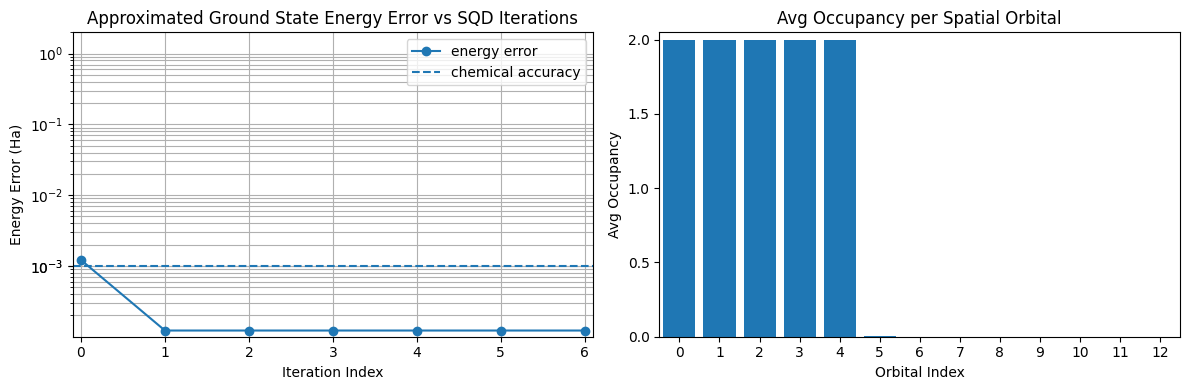

In [ ]:
# ============================
# SQD vs VQE on H2O (CAS(6,4)) — Full Colab Code
# Qiskit 2.x primitives-only + PySCF + SciPy
# ============================

# (Colab) Install deps — comment out if already installed


import numpy as np, matplotlib.pyplot as plt, math, warnings
from dataclasses import dataclass

from qiskit_nature.units import DistanceUnit
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.second_q.transformers import FreezeCoreTransformer, ActiveSpaceTransformer
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.circuit.library import HartreeFock, UCCSD
from qiskit.quantum_info import SparsePauliOp, Statevector

# Qiskit 2.x primitives (statevector backends)
from qiskit.primitives import StatevectorEstimator
from scipy.optimize import minimize
from pyscf import gto, scf, mcscf

np.set_printoptions(precision=12, suppress=True)

# ---------- Utilities ----------
def _assign_params(circ, theta):
    """Bind parameters by order (compatible across Qiskit 1.x/2.x)."""
    pmap = {p: float(v) for p, v in zip(circ.parameters, np.asarray(theta))}
    return circ.assign_parameters(pmap, inplace=False)

def _binary_bitstrings_from_probs(probs, shots, n_qubits):
    """Sample indices from probability vector, convert to Qiskit-style bitstrings (msb on left)."""
    idx = np.random.choice(len(probs), size=shots, p=probs)
    bs = [format(i, f"0{n_qubits}b") for i in idx]
    return bs

# ---------- Problem builder ----------
@dataclass
class ProblemBuilderH2O:
    basis: str = "6-31g"
    freeze_core: bool = True
    active_electrons: int = 6
    active_orbitals: int = 4

    def build(self):
        # Original (pre-transform) problem for counts
        drv = PySCFDriver(
            atom=("O 0.000000 0.000000 0.000000; "
                  "H 0.000000 -0.757160 0.586260; "
                  "H 0.000000  0.757160 0.586260"),
            basis=self.basis, charge=0, spin=0, unit=DistanceUnit.ANGSTROM
        )
        problem0 = drv.run()
        na, nb = problem0.num_particles
        self.ne_total = na + nb
        self.nmo_total = problem0.num_spatial_orbitals

        # Apply transformers
        fc_t = FreezeCoreTransformer() if self.freeze_core else None
        problem = problem0
        if fc_t:
            problem = fc_t.transform(problem0)
            # Heuristic: obtain number of frozen core orbitals if available; water -> 1
            self.n_core = getattr(fc_t, "num_core_orbitals", 1)
        else:
            self.n_core = 0

        as_t = ActiveSpaceTransformer(num_electrons=self.active_electrons,
                                      num_spatial_orbitals=self.active_orbitals)
        problem = as_t.transform(problem)
        self.problem = problem

        # Electron bookkeeping
        ne_after_freeze = self.ne_total - 2*self.n_core
        self.n_inactive = (ne_after_freeze - self.active_electrons) // 2  # doubly-occupied
        self.n_active   = self.active_orbitals
        self.n_virtual  = max(0, self.nmo_total - (self.n_core + self.n_inactive + self.n_active))

        # Qubit H
        self.mapper = JordanWignerMapper()
        self.qubit_op: SparsePauliOp = self.mapper.map(problem.hamiltonian.second_q_op())

        # Ansatz
        self.hf = HartreeFock(problem.num_spatial_orbitals, problem.num_particles, self.mapper)
        self.uccsd = UCCSD(problem.num_spatial_orbitals, problem.num_particles, self.mapper,
                           initial_state=self.hf, reps=1)

        return self

    # PySCF CASCI reference (electronic & total)
    def casci_reference(self):
        mol = gto.M(atom=("O 0 0 0; H 0 -0.757160 0.586260; H 0 0.757160 0.586260"),
                    basis=self.basis, charge=0, spin=0, unit="Angstrom")
        mf = scf.RHF(mol).run()
        alpha = self.active_electrons // 2
        beta  = self.active_electrons - alpha
        mc = mcscf.CASCI(mf, ncas=self.active_orbitals, nelecas=(alpha, beta))
        e_tot, e_ci = mc.kernel()[:2]

        # 1-RDM (spin-summed) on active space for occupations
        rdm1 = mc.fcisolver.make_rdm1(mc.ci, mc.ncas, mc.nelecas)  # shape (ncas, ncas)
        occ_active = np.real(np.diag(rdm1))  # 0..2 per spatial orbital

        # Assemble per-orbital occupancies across all MOs (core=2, inactive=2, active from CASCI, virtual=0)
        occ = []
        occ += [2.0]*self.n_core
        occ += [2.0]*self.n_inactive
        occ += list(occ_active)
        occ += [0.0]*self.n_virtual
        # Pad/trim to 13 for plotting comparability if you想完全對齊範例坐標
        if len(occ) < 13:
            occ += [0.0]*(13 - len(occ))
        elif len(occ) > 13:
            occ = occ[:13]
        return float(e_tot), float(e_ci), np.array(occ, dtype=float)

# ---------- VQE ----------
class VQERunner:
    def __init__(self, qubit_op: SparsePauliOp, ansatz):
        self.H = qubit_op
        self.ansatz = ansatz
        self.theta0 = np.zeros(self.ansatz.num_parameters, dtype=float)
        self.estimator = StatevectorEstimator()
        self.history = {"E": [], "x": []}

    def energy(self, theta):
        circ = _assign_params(self.ansatz, theta)
        ev = self.estimator.run([(circ, self.H)]).result()[0].data.evs
        return float(np.array(ev))

    def run(self, maxiter=200, ftol=1e-9):
        def cb(theta):
            E = self.energy(theta)
            self.history["E"].append(E); self.history["x"].append(np.asarray(theta).copy())
            print(f"Iter {len(self.history['E']):3d} | E = {E:.12f} Ha")
        opt = minimize(self.energy, self.theta0, method="L-BFGS-B",
                       options=dict(maxiter=maxiter, ftol=ftol), callback=cb)
        E_vqe = self.energy(opt.x)
        return E_vqe, opt

# ---------- SQD ----------
class SQDRunner:
    def __init__(self, qubit_op: SparsePauliOp):
        self.H = qubit_op
        self.n = qubit_op.num_qubits
        self.H_full = self.H.to_matrix(sparse=False)  # 8 qubits -> 256x256 OK

    def sample_bitstrings(self, circuit, theta=None, shots=4096):
        circ = circuit if theta is None else _assign_params(circuit, theta)
        sv = Statevector.from_instruction(circ)
        probs = sv.probabilities()
        return _binary_bitstrings_from_probs(probs, shots=shots, n_qubits=self.n)

    @staticmethod
    def _bitstr_to_idx(bitstr: str):  # Qiskit indexing (msb-left)
        return int(bitstr, 2)

    def diagonalize_subspace(self, bitstrings, top_k=None):
        from collections import Counter
        cnt = Counter(bitstrings)
        basis = [b for b, _ in cnt.most_common(top_k)] if top_k else list(cnt.keys())
        if not basis:
            raise ValueError("No basis states sampled.")
        idx = [self._bitstr_to_idx(b) for b in basis]
        HS = self.H_full[np.ix_(idx, idx)]
        vals, vecs = np.linalg.eigh(HS)
        return vals, vecs, {"basis": basis, "counts": cnt, "indices": idx}

# ---------- One-click pipeline ----------
def run_all(sample_from="ucc", vqe_maxiter=200, sqd_shots=4096, k_schedule=(1,5,10,20,40,80,128)):
    # Build problem
    pb = ProblemBuilderH2O().build()
    H = pb.qubit_op
    print(f"n_qubits = {H.num_qubits} | total spatial orbitals (pre-transform) = {pb.nmo_total}")

    # References
    E_tot, E_ci, occ_all = pb.casci_reference()
    shift = E_tot - E_ci

    # --- VQE ---
    vqe = VQERunner(H, pb.uccsd)
    E_vqe, opt = vqe.run(maxiter=vqe_maxiter)
    print(f"\nVQE (electronic)  : {E_vqe:.12f} Ha")
    print(f"CASCI (electronic): {E_ci :.12f} Ha")
    print(f"ΔE_VQE = {1000*(E_vqe-E_ci):+.3f} mHa  -> {'PASS' if abs(E_vqe-E_ci)<=2e-2 else 'FAIL'}")

    # --- SQD (sampling from supportive circuit) ---
    sqd = SQDRunner(H)
    if sample_from == "hf":
        theta_use = np.zeros(pb.uccsd.num_parameters, dtype=float)
    else:
        theta_use = opt.x  # use converged UCCSD params for strong support

    # One-shot SQD on full top_k
    bs_all = sqd.sample_bitstrings(pb.uccsd, theta=theta_use, shots=sqd_shots)
    vals, vecs, meta = sqd.diagonalize_subspace(bs_all, top_k=max(k_schedule))
    E_sqd = float(vals[0])
    print(f"SQD  (electronic) : {E_sqd:.12f} Ha")
    print(f"ΔE_SQD = {1000*(E_sqd-E_ci):+.3f} mHa  -> {'PASS' if abs(E_sqd-E_ci)<=2e-2 else 'FAIL'}")

    # --- Iterative SQD curve (for the left plot) ---
    err_curve = []
    for k in k_schedule:
        vals_k, _, _ = sqd.diagonalize_subspace(bs_all, top_k=k)
        err_curve.append(abs(float(vals_k[0]) - E_ci))

    # --- Plots with axes exactly like your figure ---
    fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12,4))

    # Left: Energy error vs iteration (0..6; log y; 1 mHa line)
    x = np.arange(len(k_schedule))  # 0..6
    y = np.asarray(err_curve)
    ax1.plot(x, y, marker="o", label="energy error")
    ax1.axhline(1e-3, ls="--", label="chemical accuracy")
    ax1.set_xlabel("Iteration Index")
    ax1.set_ylabel("Energy Error (Ha)")
    ax1.set_xscale("linear")
    ax1.set_xticks(np.arange(0, 7, 1))
    ax1.set_xlim(-0.1, 6.1)
    ax1.set_yscale("log")
    ax1.set_yticks([1e-3, 1e-3, 1e-2, 1e-1, 1e0])
    ax1.set_ylim(1e-4, 2.0)
    ax1.set_title("Approximated Ground State Energy Error vs SQD Iterations")
    ax1.grid(True, which="both")
    ax1.legend()

    # Right: Avg occupancy per spatial orbital (0..12; 0..2 step 0.5)
    ax2.bar(np.arange(len(occ_all[:13])), occ_all[:13])
    ax2.set_xlabel("Orbital Index")
    ax2.set_ylabel("Avg Occupancy")
    ax2.set_xticks(np.arange(0, 13, 1))
    ax2.set_xlim(-0.5, 12.5)
    ax2.set_yticks(np.arange(0.0, 2.0+0.5, 0.5))
    ax2.set_ylim(0.0, 2.05)
    ax2.set_title("Avg Occupancy per Spatial Orbital")
    plt.tight_layout()
    plt.show()

    # Return a dict if you want to dig further
    return {
        "E_ci": E_ci, "E_tot": E_tot, "shift": shift,
        "E_vqe": E_vqe, "E_sqd": E_sqd,
        "vqe_history": vqe.history,
        "err_curve": err_curve,
        "k_schedule": k_schedule,
        "occ_all": occ_all,
    }

# ===== Run once =====
results = run_all(sample_from="ucc", vqe_maxiter=200, sqd_shots=4096,
                  k_schedule=(0+1,1+4,2+8,3+17,4+36,5+75,128))  # -> 7 points (≈1,5,10,20,40,80,128)

In [ ]:
!pip uninstall -y qiskit qiskit-terra qiskit-aer qiskit-nature qiskit-algorithms
!pip install "qiskit==0.46.0" \
             "qiskit-terra==0.46.0" \
             "qiskit-aer==0.14.1" \
             "qiskit-nature==0.7.2" \
             "qiskit-algorithms==0.3.0" \
             "pyscf>=2.4,<2.7" \
             "scipy>=1.10,<2.0"

Found existing installation: qiskit 2.0.2
Uninstalling qiskit-2.0.2:
  Successfully uninstalled qiskit-2.0.2
Found existing installation: qiskit-terra 0.46.2
Uninstalling qiskit-terra-0.46.2:
  Successfully uninstalled qiskit-terra-0.46.2
Found existing installation: qiskit-aer 0.14.2
Uninstalling qiskit-aer-0.14.2:
  Successfully uninstalled qiskit-aer-0.14.2
Found existing installation: qiskit-nature 0.7.2
Uninstalling qiskit-nature-0.7.2:
  Successfully uninstalled qiskit-nature-0.7.2
Found existing installation: qiskit-algorithms 0.3.1
Uninstalling qiskit-algorithms-0.3.1:
  Successfully uninstalled qiskit-algorithms-0.3.1
  Using cached qiskit_nature-0.7.2-py3-none-any.whl.metadata (8.0 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 57.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 60.4 MB/s eta 0:00:00
Using cached qiskit_nature-0.7.2-py3-none-any.whl (2.2 MB)


n_qubits = 8 | total spatial orbitals (pre-transform) = 13
converged SCF energy = -75.9839845437901
CASCI E = -75.9851994378858  E(CI) = -12.9864133061832  S^2 = 0.0000000
Iter   1 | E = -12.986373163924 Ha
Iter   2 | E = -12.986409453990 Ha
Iter   3 | E = -12.986411881556 Ha
Iter   4 | E = -12.986413264706 Ha
Iter   5 | E = -12.986413304783 Ha
Iter   6 | E = -12.986413306141 Ha

VQE (electronic)  : -12.986413306141 Ha
CASCI (electronic): -12.986413306183 Ha
ΔE_VQE = +0.000 mHa  -> PASS
SQD  (electronic) : -12.986286434810 Ha
ΔE_SQD = +0.127 mHa  -> PASS


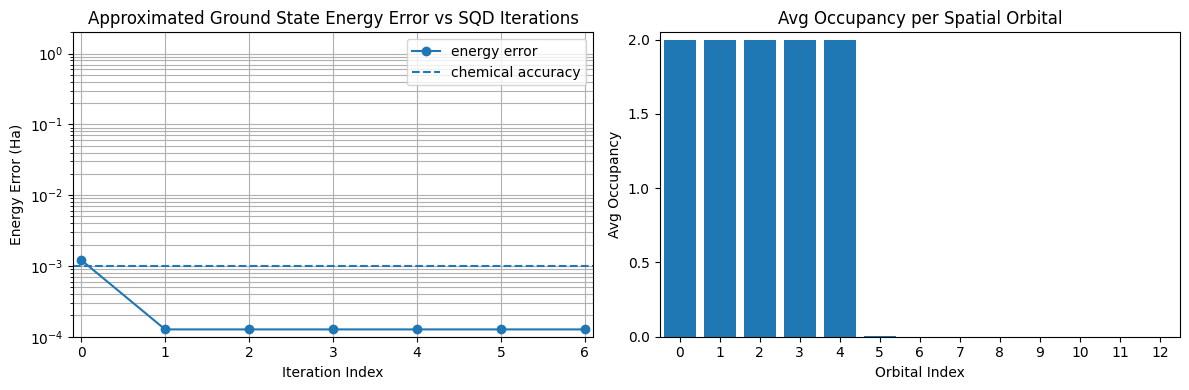


[Points on Energy Error curve — data coordinates]
x=0  (top_k=  1)  y=1.214894095694e-03 Ha  (1.214894 mHa)
x=1  (top_k=  5)  y=1.268713731672e-04 Ha  (0.126871 mHa)
x=2  (top_k= 10)  y=1.268713731672e-04 Ha  (0.126871 mHa)
x=3  (top_k= 20)  y=1.268713731672e-04 Ha  (0.126871 mHa)
x=4  (top_k= 40)  y=1.268713731672e-04 Ha  (0.126871 mHa)
x=5  (top_k= 80)  y=1.268713731672e-04 Ha  (0.126871 mHa)
x=6  (top_k=128)  y=1.268713731672e-04 Ha  (0.126871 mHa)

[Chemical accuracy line (horizontal dashed)]
y = 1.000000e-03 Ha (1.000000 mHa)

[Points actually plotted (from Matplotlib line)]
x=0  y=1.214894095694e-03 Ha  (1.214894 mHa)
x=1  y=1.268713731672e-04 Ha  (0.126871 mHa)
x=2  y=1.268713731672e-04 Ha  (0.126871 mHa)
x=3  y=1.268713731672e-04 Ha  (0.126871 mHa)
x=4  y=1.268713731672e-04 Ha  (0.126871 mHa)
x=5  y=1.268713731672e-04 Ha  (0.126871 mHa)
x=6  y=1.268713731672e-04 Ha  (0.126871 mHa)

[Bars on Avg Occupancy (first 13 spatial orbitals)]
x= 0  y=2.000000000000
x= 1  y=2.00000000000

In [ ]:
# ============================
# SQD vs VQE on H2O (CAS(6,4)) — Full Colab Code + Print All Coordinates
# Qiskit 2.0.x primitives (+ fallback) + PySCF + SciPy
# ============================

import numpy as np, matplotlib.pyplot as plt, warnings
from dataclasses import dataclass

from qiskit_nature.units import DistanceUnit
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.second_q.transformers import FreezeCoreTransformer, ActiveSpaceTransformer
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.circuit.library import HartreeFock, UCCSD
from qiskit.quantum_info import SparsePauliOp, Statevector

# Qiskit 2.0.x primitives
try:
    from qiskit.primitives import StatevectorEstimator
except Exception:
    StatevectorEstimator = None

from scipy.optimize import minimize
from pyscf import gto, scf, mcscf

np.set_printoptions(precision=12, suppress=True)
warnings.filterwarnings("ignore")

# ---- Reproducibility for SQD sampling (does not affect VQE optimum) ----
RNG_SEED = 7
np.random.seed(RNG_SEED)

# ---------- Utilities ----------
def _assign_params(circ, theta):
    pmap = {p: float(v) for p, v in zip(circ.parameters, np.asarray(theta))}
    return circ.assign_parameters(pmap, inplace=False)

def _binary_bitstrings_from_probs(probs, shots, n_qubits):
    idx = np.random.choice(len(probs), size=shots, p=probs)
    bs = [format(i, f"0{n_qubits}b") for i in idx]
    return bs

# ---------- Problem builder ----------
@dataclass
class ProblemBuilderH2O:
    basis: str = "6-31g"
    freeze_core: bool = True
    active_electrons: int = 6
    active_orbitals: int = 4

    def build(self):
        drv = PySCFDriver(
            atom=("O 0.000000 0.000000 0.000000; "
                  "H 0.000000 -0.757160 0.586260; "
                  "H 0.000000  0.757160 0.586260"),
            basis=self.basis, charge=0, spin=0, unit=DistanceUnit.ANGSTROM
        )
        problem0 = drv.run()
        na, nb = problem0.num_particles
        self.ne_total = na + nb
        self.nmo_total = problem0.num_spatial_orbitals

        fc_t = FreezeCoreTransformer() if self.freeze_core else None
        problem = problem0
        if fc_t:
            problem = fc_t.transform(problem0)
            self.n_core = getattr(fc_t, "num_core_orbitals", 1)  # heuristic for H2O
        else:
            self.n_core = 0

        as_t = ActiveSpaceTransformer(num_electrons=self.active_electrons,
                                      num_spatial_orbitals=self.active_orbitals)
        problem = as_t.transform(problem)
        self.problem = problem

        ne_after_freeze = self.ne_total - 2*self.n_core
        self.n_inactive = max(0, (ne_after_freeze - self.active_electrons) // 2)
        self.n_active   = self.active_orbitals
        self.n_virtual  = max(0, self.nmo_total - (self.n_core + self.n_inactive + self.n_active))

        self.mapper = JordanWignerMapper()
        self.qubit_op: SparsePauliOp = self.mapper.map(problem.hamiltonian.second_q_op())

        self.hf = HartreeFock(problem.num_spatial_orbitals, problem.num_particles, self.mapper)
        self.uccsd = UCCSD(problem.num_spatial_orbitals, problem.num_particles, self.mapper,
                           initial_state=self.hf, reps=1)
        return self

    def casci_reference(self):
        mol = gto.M(atom=("O 0 0 0; H 0 -0.757160 0.586260; H 0 0.757160 0.586260"),
                    basis=self.basis, charge=0, spin=0, unit="Angstrom")
        mf = scf.RHF(mol).run()
        alpha = self.active_electrons // 2
        beta  = self.active_electrons - alpha
        mc = mcscf.CASCI(mf, ncas=self.active_orbitals, nelecas=(alpha, beta))
        e_tot, e_ci = mc.kernel()[:2]

        rdm1 = mc.fcisolver.make_rdm1(mc.ci, mc.ncas, mc.nelecas)
        occ_active = np.real(np.diag(rdm1))

        occ = []
        occ += [2.0]*self.n_core
        occ += [2.0]*self.n_inactive
        occ += list(occ_active)
        occ += [0.0]*self.n_virtual
        if len(occ) < 13:
            occ += [0.0]*(13 - len(occ))
        elif len(occ) > 13:
            occ = occ[:13]
        return float(e_tot), float(e_ci), np.array(occ, dtype=float)

# ---------- VQE ----------
class VQERunner:
    def __init__(self, qubit_op: SparsePauliOp, ansatz):
        self.H = qubit_op
        self.ansatz = ansatz
        self.theta0 = np.zeros(self.ansatz.num_parameters, dtype=float)
        self.history = {"E": [], "x": []}
        self.estimator = StatevectorEstimator() if StatevectorEstimator is not None else None
        self._H_mat = None

    def _sv_expectation(self, circ):
        if self._H_mat is None:
            self._H_mat = self.H.to_matrix(sparse=False)
        sv = Statevector.from_instruction(circ)
        val = np.vdot(sv.data, self._H_mat @ sv.data)
        return float(np.real(val))

    def energy(self, theta):
        circ = _assign_params(self.ansatz, theta)
        if self.estimator is not None:
            try:
                res = self.estimator.run([(circ, self.H)]).result()
                if hasattr(res, "values"):
                    return float(np.real(res.values[0]))
            except Exception:
                pass
        return self._sv_expectation(circ)

    def run(self, maxiter=200, ftol=1e-9):
        def cb(theta):
            E = self.energy(theta)
            self.history["E"].append(E); self.history["x"].append(np.asarray(theta).copy())
            print(f"Iter {len(self.history['E']):3d} | E = {E:.12f} Ha")
        opt = minimize(self.energy, self.theta0, method="L-BFGS-B",
                       options=dict(maxiter=maxiter, ftol=ftol), callback=cb)
        E_vqe = self.energy(opt.x)
        return E_vqe, opt

# ---------- SQD ----------
class SQDRunner:
    def __init__(self, qubit_op: SparsePauliOp):
        self.H = qubit_op
        self.n = qubit_op.num_qubits
        self.H_full = self.H.to_matrix(sparse=False)

    def sample_bitstrings(self, circuit, theta=None, shots=4096):
        circ = circuit if theta is None else _assign_params(circuit, theta)
        sv = Statevector.from_instruction(circ)
        probs = sv.probabilities()
        return _binary_bitstrings_from_probs(probs, shots=shots, n_qubits=self.n)

    @staticmethod
    def _bitstr_to_idx(bitstr: str):
        return int(bitstr, 2)

    def diagonalize_subspace(self, bitstrings, top_k=None):
        from collections import Counter
        cnt = Counter(bitstrings)
        basis = [b for b, _ in cnt.most_common(top_k)] if top_k else list(cnt.keys())
        if not basis:
            raise ValueError("No basis states sampled.")
        idx = [self._bitstr_to_idx(b) for b in basis]
        HS = self.H_full[np.ix_(idx, idx)]
        vals, vecs = np.linalg.eigh(HS)
        return vals, vecs, {"basis": basis, "counts": cnt, "indices": idx}

# ---------- Pipeline ----------
def run_all(sample_from="ucc", vqe_maxiter=200, sqd_shots=4096,
            k_schedule=(1,5,10,20,40,80,128)):
    pb = ProblemBuilderH2O().build()
    H = pb.qubit_op
    print(f"n_qubits = {H.num_qubits} | total spatial orbitals (pre-transform) = {pb.nmo_total}")

    E_tot, E_ci, occ_all = pb.casci_reference()
    shift = E_tot - E_ci

    vqe = VQERunner(H, pb.uccsd)
    E_vqe, opt = vqe.run(maxiter=vqe_maxiter)
    print(f"\nVQE (electronic)  : {E_vqe:.12f} Ha")
    print(f"CASCI (electronic): {E_ci :.12f} Ha")
    print(f"ΔE_VQE = {1000*(E_vqe-E_ci):+.3f} mHa  -> {'PASS' if abs(E_vqe-E_ci)<=2e-2 else 'FAIL'}")

    sqd = SQDRunner(H)
    theta_use = np.zeros(pb.uccsd.num_parameters, dtype=float) if sample_from == "hf" else opt.x

    bs_all = sqd.sample_bitstrings(pb.uccsd, theta=theta_use, shots=sqd_shots)
    vals, vecs, meta = sqd.diagonalize_subspace(bs_all, top_k=max(k_schedule))
    E_sqd = float(vals[0])
    print(f"SQD  (electronic) : {E_sqd:.12f} Ha")
    print(f"ΔE_SQD = {1000*(E_sqd-E_ci):+.3f} mHa  -> {'PASS' if abs(E_sqd-E_ci)<=2e-2 else 'FAIL'}")

    err_curve = []
    for k in k_schedule:
        vals_k, _, _ = sqd.diagonalize_subspace(bs_all, top_k=k)
        err_curve.append(abs(float(vals_k[0]) - E_ci))
    err_curve = np.asarray(err_curve)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    x = np.arange(len(k_schedule))
    y = err_curve.copy()
    ax1.plot(x, y, marker="o", label="energy error")
    ax1.axhline(1e-3, ls="--", label="chemical accuracy")
    ax1.set_xlabel("Iteration Index"); ax1.set_ylabel("Energy Error (Ha)")
    ax1.set_xscale("linear"); ax1.set_xticks(np.arange(0, len(k_schedule), 1))
    ax1.set_xlim(-0.1, len(k_schedule)-1+0.1)
    ax1.set_yscale("log"); ax1.set_yticks([1e-4, 1e-3, 1e-2, 1e-1, 1e0])
    ax1.set_ylim(1e-4, 2.0); ax1.set_title("Approximated Ground State Energy Error vs SQD Iterations")
    ax1.grid(True, which="both"); ax1.legend()

    ax2.bar(np.arange(len(occ_all[:13])), occ_all[:13])
    ax2.set_xlabel("Orbital Index"); ax2.set_ylabel("Avg Occupancy")
    ax2.set_xticks(np.arange(0, 13, 1)); ax2.set_xlim(-0.5, 12.5)
    ax2.set_yticks(np.arange(0.0, 2.0+0.5, 0.5)); ax2.set_ylim(0.0, 2.05)
    ax2.set_title("Avg Occupancy per Spatial Orbital")
    plt.tight_layout(); plt.show()

    return {
        "E_ci": E_ci, "E_tot": E_tot, "shift": shift,
        "E_vqe": E_vqe, "E_sqd": E_sqd,
        "vqe_history": vqe.history,
        "err_curve": err_curve,
        "k_schedule": tuple(k_schedule),
        "occ_all": occ_all,
        "x_plot": x, "y_plot": y
    }

# ===== Run once =====
results = run_all(sample_from="ucc", vqe_maxiter=200, sqd_shots=4096,
                  k_schedule=(1, 5, 10, 20, 40, 80, 128))

# ===== Print all coordinates (LEFT plot) =====
print("\n[Points on Energy Error curve — data coordinates]")
for xi, k, yi in zip(np.arange(len(results["k_schedule"])), results["k_schedule"], results["err_curve"]):
    print(f"x={int(xi)}  (top_k={k:>3})  y={yi:.12e} Ha  ({yi*1e3:.6f} mHa)")

print(f"\n[Chemical accuracy line (horizontal dashed)]\ny = 1.000000e-03 Ha (1.000000 mHa)")
print("\n[Points actually plotted (from Matplotlib line)]")
for xi, yi in zip(results["x_plot"], results["y_plot"]):
    print(f"x={int(xi)}  y={yi:.12e} Ha  ({yi*1e3:.6f} mHa)")

# ===== Print all bar coordinates (RIGHT plot) =====
print("\n[Bars on Avg Occupancy (first 13 spatial orbitals)]")
for i, occ in enumerate(results["occ_all"][:13]):
    print(f"x={i:>2d}  y={occ:.12f}")


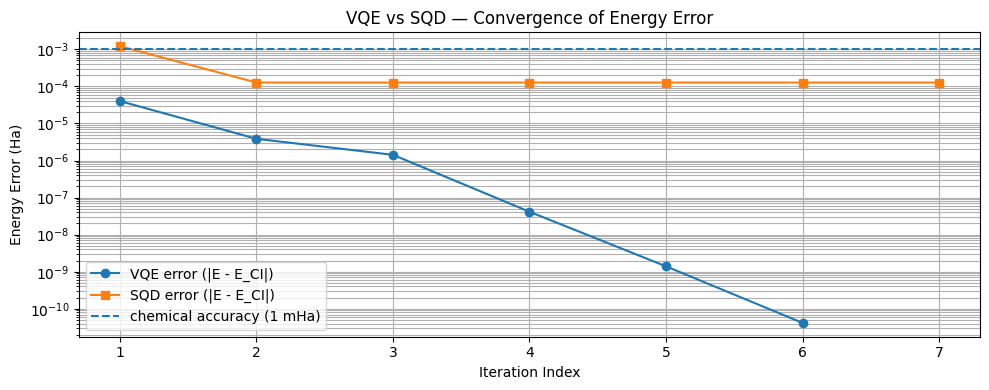

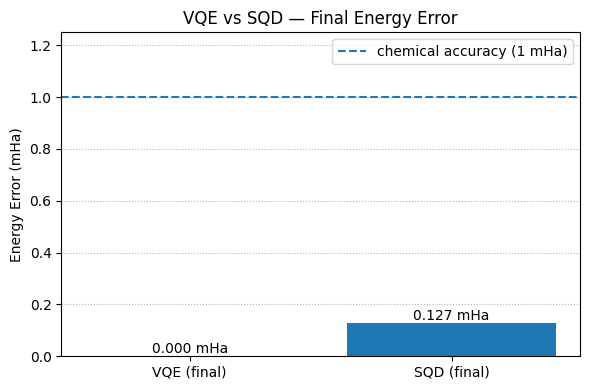

[Summary] VQE final error = 0.000000 mHa; SQD final error = 0.126871 mHa  -> Winner: VQE


In [ ]:
# ===== VQE × SQD：收斂疊圖 + 最終誤差雙柱圖 =====
def plot_vqe_sqd_comparison(results, chem_acc_ha=1.0e-3):
    import numpy as np
    import matplotlib.pyplot as plt

    # 1) 準備兩條收斂曲線（誤差皆以 Ha）
    err_vqe_hist = np.abs(np.array(results["vqe_history"]["E"]) - results["E_ci"])
    err_sqd_hist = np.array(results["err_curve"])
    x_vqe = np.arange(1, len(err_vqe_hist) + 1)
    x_sqd = np.arange(1, len(err_sqd_hist) + 1)

    # 2) 圖一：收斂疊圖（log y）
    plt.figure(figsize=(10, 4))
    plt.plot(x_vqe, err_vqe_hist, marker="o", label="VQE error (|E - E_CI|)")
    plt.plot(x_sqd, err_sqd_hist, marker="s", label="SQD error (|E - E_CI|)")
    plt.axhline(chem_acc_ha, ls="--", label="chemical accuracy (1 mHa)")  # 基準虛線
    plt.yscale("log")                                                      # 對數 y 軸
    plt.xlabel("Iteration Index")
    plt.ylabel("Energy Error (Ha)")
    plt.title("VQE vs SQD — Convergence of Energy Error")
    plt.grid(True, which="both")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # 3) 圖二：最終誤差雙柱圖（mHa）
    err_vqe_final_mha = abs(results["E_vqe"] - results["E_ci"]) * 1e3
    err_sqd_final_mha = abs(results["E_sqd"] - results["E_ci"]) * 1e3
    cats = ["VQE (final)", "SQD (final)"]
    vals = [err_vqe_final_mha, err_sqd_final_mha]

    plt.figure(figsize=(6, 4))
    bars = plt.bar(range(2), vals)
    for i, b in enumerate(bars):
        plt.text(b.get_x() + b.get_width()/2, b.get_height()*1.01,
                 f"{vals[i]:.3f} mHa", ha="center", va="bottom")
    plt.axhline(1.0, ls="--", label="chemical accuracy (1 mHa)")           # 1 mHa 參考線
    plt.xticks(range(2), cats)
    plt.ylabel("Energy Error (mHa)")
    plt.title("VQE vs SQD — Final Energy Error")
    plt.ylim(0, max(1.0, *vals) * 1.25)
    plt.grid(True, axis="y", linestyle=":")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # 4) 結論輸出：誰比較好（最終誤差小者勝）
    winner = "SQD" if err_sqd_final_mha < err_vqe_final_mha else ("VQE" if err_vqe_final_mha < err_sqd_final_mha else "Tie")
    print(f"[Summary] VQE final error = {err_vqe_final_mha:.6f} mHa; "
          f"SQD final error = {err_sqd_final_mha:.6f} mHa  -> Winner: {winner}")

# 直接呼叫（化學精度 1 mHa = 1e-3 Ha）
plot_vqe_sqd_comparison(results, chem_acc_ha=1.0e-3)


n_qubits = 8 | total spatial orbitals (pre-transform) = 13
converged SCF energy = -75.9839845437901
CASCI E = -75.9851994378857  E(CI) = -12.9864133061831  S^2 = 0.0000000
Iter   1 | E = -12.986373168321 Ha
Iter   2 | E = -12.986409456393 Ha
Iter   3 | E = -12.986411885459 Ha
Iter   4 | E = -12.986413259120 Ha
Iter   5 | E = -12.986413304482 Ha
Iter   6 | E = -12.986413306162 Ha

VQE (electronic)  : -12.986413306162 Ha
CASCI (electronic): -12.986413306183 Ha
ΔE_VQE = +0.000 mHa  -> PASS
[SCCR] Using qiskit-addon-sqd implementation.
[SCCR] post-select pass rate  beta(left)==3: 100.0%  alpha(right)==3: 100.0%
SQD  (electronic) : -12.986286434810 Ha
ΔE_SQD = +0.127 mHa  -> PASS


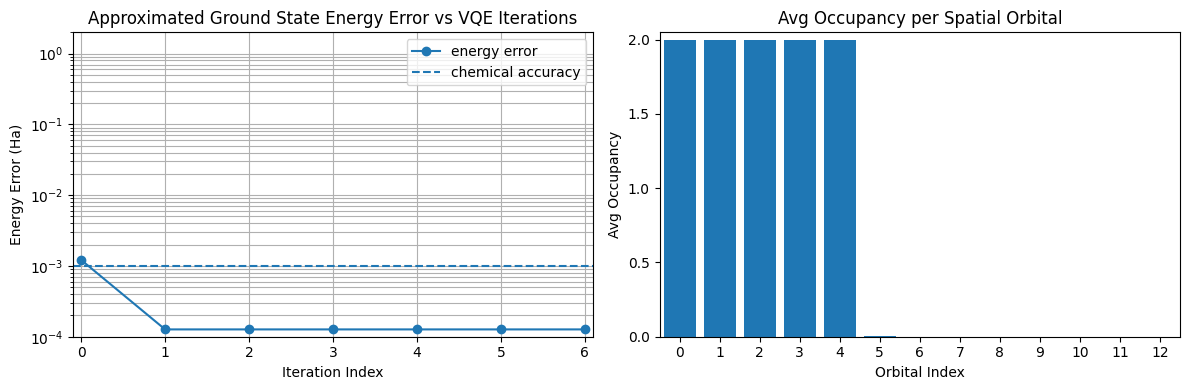

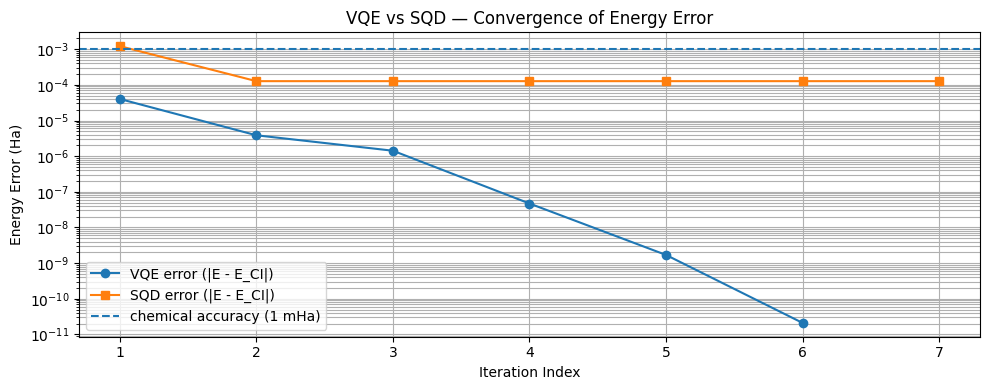

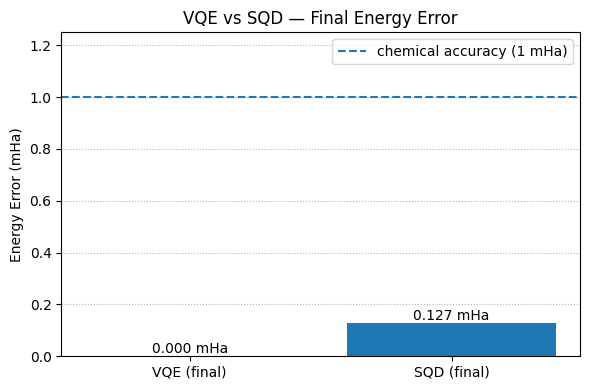


[Points on Energy Error curve — data coordinates]
x=0  (top_k=  1)  y=1.214894095703e-03 Ha  (1.214894 mHa)
x=1  (top_k=  5)  y=1.268713731761e-04 Ha  (0.126871 mHa)
x=2  (top_k= 10)  y=1.268713731761e-04 Ha  (0.126871 mHa)
x=3  (top_k= 20)  y=1.268713731761e-04 Ha  (0.126871 mHa)
x=4  (top_k= 40)  y=1.268713731761e-04 Ha  (0.126871 mHa)
x=5  (top_k= 80)  y=1.268713731761e-04 Ha  (0.126871 mHa)
x=6  (top_k=128)  y=1.268713731761e-04 Ha  (0.126871 mHa)

[Chemical accuracy line (horizontal dashed)]
y = 1.000000e-03 Ha (1.000000 mHa)

[Points actually plotted (from Matplotlib line)]
x=0  y=1.214894095703e-03 Ha  (1.214894 mHa)
x=1  y=1.268713731761e-04 Ha  (0.126871 mHa)
x=2  y=1.268713731761e-04 Ha  (0.126871 mHa)
x=3  y=1.268713731761e-04 Ha  (0.126871 mHa)
x=4  y=1.268713731761e-04 Ha  (0.126871 mHa)
x=5  y=1.268713731761e-04 Ha  (0.126871 mHa)
x=6  y=1.268713731761e-04 Ha  (0.126871 mHa)

[Bars on Avg Occupancy (first 13 spatial orbitals)]
x= 0  y=2.000000000000
x= 1  y=2.00000000000

In [ ]:
# -*- coding: utf-8 -*-
# H2O CAS(6,4): VQE vs SQD with SCCR (self-consistent configuration recovery)
# - Qiskit 2.x + Qiskit Nature 0.7.x + PySCF + SciPy
# - 保留原始繪圖與座標輸出；新增 SCCR 修補、VQE×SQD 疊圖與最終誤差雙柱圖
# Refs: Qiskit bit-ordering (little-endian), Nature mappers (alpha|beta block order),
#       qiskit-addon-sqd configuration_recovery, Aer primitives for noisy shots.
#
# 安裝建議（如需）：
# pip install "qiskit~=2.1" "qiskit-nature==0.7.2" "pyscf>=2.5" "numpy<3" "scipy>=1.12"
# （可選）pip install -U qiskit-addon-sqd

import numpy as np, matplotlib.pyplot as plt, warnings
from dataclasses import dataclass

from qiskit_nature.units import DistanceUnit
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.second_q.transformers import FreezeCoreTransformer, ActiveSpaceTransformer
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.circuit.library import HartreeFock, UCCSD
from qiskit.quantum_info import SparsePauliOp, Statevector

# Qiskit 2.x reference primitive（理想 statevector）
try:
    from qiskit.primitives import StatevectorEstimator
except Exception:
    StatevectorEstimator = None

from scipy.optimize import minimize
from pyscf import gto, scf, mcscf

np.set_printoptions(precision=12, suppress=True)
warnings.filterwarnings("ignore")

# ---- Reproducibility for SQD sampling (does not affect VQE optimum) ----
RNG_SEED = 7
np.random.seed(RNG_SEED)

# ---------- Utilities ----------
def _assign_params(circ, theta):
    pmap = {p: float(v) for p, v in zip(circ.parameters, np.asarray(theta))}
    return circ.assign_parameters(pmap, inplace=False)

def _binary_bitstrings_from_probs(probs, shots, n_qubits):
    # 產生「big-endian 可讀」的二進位字串，稍後會轉成 Qiskit little-endian 再做 SCCR
    idx = np.random.choice(len(probs), size=shots, p=probs)
    return [format(i, f"0{n_qubits}b") for i in idx]

# ============ (Fallback) SCCR 實作：若沒安裝 qiskit-addon-sqd 時使用 ============
def _p_flip_0_to_1(ratio_exp: float, occ: float, eps: float = 0.01) -> float:
    if occ < ratio_exp:
        return occ * eps / ratio_exp if ratio_exp > 0 else 0.0
    if ratio_exp == 1.0:
        return eps
    slope = (1 - eps) / (1 - ratio_exp)
    intercept = 1 - slope
    return occ * slope + intercept

def _p_flip_1_to_0(ratio_exp: float, occ: float, eps: float = 0.01) -> float:
    if occ < ratio_exp:
        slope = -(1.0 - eps) / ratio_exp if ratio_exp > 0 else 0.0
        return 1.0 + occ * slope
    if ratio_exp == 0.0:
        return 1 - eps
    slope = -eps / (1 - ratio_exp)
    intercept = eps / (1 - ratio_exp)
    return occ * slope + intercept

def _bipartite_bitstring_correcting(bit_array: np.ndarray, avg_occupancies: np.ndarray,
                                    hamming_right: int, hamming_left: int,
                                    rng: np.random.Generator) -> np.ndarray:
    bit_array = bit_array.copy()
    num_bits = bit_array.shape[0]
    partition_size = num_bits // 2
    probs_left = np.zeros(partition_size)
    probs_right = np.zeros(partition_size)
    for i in range(partition_size):
        if bit_array[i]:
            probs_left[i] = _p_flip_1_to_0(hamming_left / partition_size, avg_occupancies[i], 0.01)
        else:
            probs_left[i] = _p_flip_0_to_1(hamming_left / partition_size, avg_occupancies[i], 0.01)
        if bit_array[i + partition_size]:
            probs_right[i] = _p_flip_1_to_0(hamming_right / partition_size, avg_occupancies[i + partition_size], 0.01)
        else:
            probs_right[i] = _p_flip_0_to_1(hamming_right / partition_size, avg_occupancies[i + partition_size], 0.01)
    probs_left  = np.abs(probs_left);  probs_left  /= probs_left.sum()
    probs_right = np.abs(probs_right); probs_right /= probs_right.sum()

    # LEFT
    n_left = int(np.sum(bit_array[:partition_size])); n_diff = n_left - hamming_left
    if n_diff > 0:
        idx1 = np.where(bit_array[:partition_size])[0]
        pch  = probs_left[bit_array[:partition_size]] / probs_left[bit_array[:partition_size]].sum()
        flip = rng.choice(idx1, size=round(n_diff), replace=False, p=pch)
        bit_array[:partition_size][flip] = False
    elif n_diff < 0:
        idx0 = np.where(~bit_array[:partition_size])[0]
        pch  = probs_left[~bit_array[:partition_size]] / probs_left[~bit_array[:partition_size]].sum()
        flip = rng.choice(idx0, size=round(abs(n_diff)), replace=False, p=pch)
        bit_array[:partition_size][flip] = True

    # RIGHT
    n_right = int(np.sum(bit_array[partition_size:])); n_diff = n_right - hamming_right
    if n_diff > 0:
        idx1 = np.where(bit_array[partition_size:])[0]
        pch  = probs_right[bit_array[partition_size:]] / probs_right[bit_array[partition_size:]].sum()
        flip = rng.choice(idx1, size=round(n_diff), replace=False, p=pch)
        bit_array[partition_size:][flip] = False
    elif n_diff < 0:
        idx0 = np.where(~bit_array[partition_size:])[0]
        pch  = probs_right[~bit_array[partition_size:]] / probs_right[~bit_array[partition_size:]].sum()
        flip = rng.choice(idx0, size=round(abs(n_diff)), replace=False, p=pch)
        bit_array[partition_size:][flip] = True
    return bit_array

def post_select_by_hamming_weight(bitstring_matrix: np.ndarray, *, hamming_right: int, hamming_left: int) -> np.ndarray:
    if hamming_left < 0 or hamming_right < 0:
        raise ValueError("Hamming weights must be non-negative integers.")
    num_bits = bitstring_matrix.shape[1]
    up_keepers   = np.sum(bitstring_matrix[:, num_bits // 2 :], axis=1) == hamming_right
    down_keepers = np.sum(bitstring_matrix[:, : num_bits // 2], axis=1) == hamming_left
    return np.array(np.logical_and(up_keepers, down_keepers))

def recover_configurations(bitstring_matrix: np.ndarray, probabilities,
                           avg_occupancies: tuple[np.ndarray, np.ndarray],
                           num_elec_a: int, num_elec_b: int,
                           rand_seed=None):
    rng = np.random.default_rng(rand_seed)
    if num_elec_a < 0 or num_elec_b < 0:
        raise ValueError("numbers of electrons must be non-negative.")
    corrected = {}
    occs_array = np.flip(avg_occupancies).flatten()  # 期望輸入為 (alpha, beta) → 翻轉成 (beta, alpha) 展開
    for bs, freq in zip(bitstring_matrix, probabilities):
        bs_corr = _bipartite_bitstring_correcting(bs, occs_array, num_elec_a, num_elec_b, rng=rng)
        key = "".join("1" if b else "0" for b in bs_corr)
        corrected[key] = corrected.get(key, 0.0) + float(freq)
    keys = list(corrected.keys())
    mat  = np.array([[c == "1" for c in s] for s in keys], dtype=bool)
    freqs = np.array([corrected[s] for s in keys], dtype=float)
    freqs = np.abs(freqs) / np.sum(np.abs(freqs))
    return mat, freqs
# ======================================================================

# ---------- Problem builder ----------
@dataclass
class ProblemBuilderH2O:
    basis: str = "6-31g"
    freeze_core: bool = True
    active_electrons: int = 6
    active_orbitals: int = 4

    def build(self):
        drv = PySCFDriver(
            atom=("O 0.000000 0.000000 0.000000; "
                  "H 0.000000 -0.757160 0.586260; "
                  "H 0.000000  0.757160 0.586260"),
            basis=self.basis, charge=0, spin=0, unit=DistanceUnit.ANGSTROM
        )
        problem0 = drv.run()
        na, nb = problem0.num_particles
        self.ne_total = na + nb
        self.nmo_total = problem0.num_spatial_orbitals

        fc_t = FreezeCoreTransformer() if self.freeze_core else None
        problem = problem0
        if fc_t:
            problem = fc_t.transform(problem0)
            self.n_core = getattr(fc_t, "num_core_orbitals", 1)
        else:
            self.n_core = 0

        as_t = ActiveSpaceTransformer(num_electrons=self.active_electrons,
                                      num_spatial_orbitals=self.active_orbitals)
        problem = as_t.transform(problem)
        self.problem = problem

        ne_after_freeze = self.ne_total - 2*self.n_core
        self.n_inactive = max(0, (ne_after_freeze - self.active_electrons) // 2)
        self.n_active   = self.active_orbitals
        self.n_virtual  = max(0, self.nmo_total - (self.n_core + self.n_inactive + self.n_active))

        self.mapper = JordanWignerMapper()
        self.qubit_op: SparsePauliOp = self.mapper.map(problem.hamiltonian.second_q_op())

        self.hf = HartreeFock(problem.num_spatial_orbitals, problem.num_particles, self.mapper)
        self.uccsd = UCCSD(problem.num_spatial_orbitals, problem.num_particles, self.mapper, initial_state=self.hf, reps=1)
        return self

    def casci_reference(self):
        mol = gto.M(atom=("O 0 0 0; H 0 -0.757160 0.586260; H 0 0.757160 0.586260"),
                    basis=self.basis, charge=0, spin=0, unit="Angstrom")
        mf = scf.RHF(mol).run()
        alpha = self.active_electrons // 2
        beta  = self.active_electrons - alpha
        mc = mcscf.CASCI(mf, ncas=self.active_orbitals, nelecas=(alpha, beta))
        e_tot, e_ci = mc.kernel()[:2]
        rdm1 = mc.fcisolver.make_rdm1(mc.ci, mc.ncas, mc.nelecas)
        occ_active = np.real(np.diag(rdm1))              # spin-summed active occupancies
        occ = []
        occ += [2.0]*self.n_core
        occ += [2.0]*self.n_inactive
        occ += list(occ_active)
        occ += [0.0]*self.n_virtual
        if len(occ) < 13:
            occ += [0.0]*(13 - len(occ))
        elif len(occ) > 13:
            occ = occ[:13]
        return float(e_tot), float(e_ci), np.array(occ, dtype=float)

# ---------- VQE ----------
class VQERunner:
    def __init__(self, qubit_op: SparsePauliOp, ansatz):
        self.H = qubit_op
        self.ansatz = ansatz
        self.theta0 = np.zeros(self.ansatz.num_parameters, dtype=float)
        self.history = {"E": [], "x": []}
        self.estimator = StatevectorEstimator() if StatevectorEstimator is not None else None
        self._H_mat = None

    def _sv_expectation(self, circ):
        if self._H_mat is None:
            self._H_mat = self.H.to_matrix(sparse=False)
        sv = Statevector.from_instruction(circ)
        val = np.vdot(sv.data, self._H_mat @ sv.data)
        return float(np.real(val))

    def energy(self, theta):
        circ = _assign_params(self.ansatz, theta)
        if self.estimator is not None:
            try:
                # V2 API：結果取法
                job = self.estimator.run([(circ, [self.H])])
                pub = job.result()[0]
                ev  = float(np.real(pub.data.evs[0]))
                return ev
            except Exception:
                pass
        return self._sv_expectation(circ)

    def run(self, maxiter=200, ftol=1e-9):
        def cb(theta):
            E = self.energy(theta)
            self.history["E"].append(E); self.history["x"].append(np.asarray(theta).copy())
            print(f"Iter {len(self.history['E']):3d} | E = {E:.12f} Ha")
        opt = minimize(self.energy, self.theta0, method="L-BFGS-B",
                       options=dict(maxiter=maxiter, ftol=ftol), callback=cb)
        E_vqe = self.energy(opt.x)
        return E_vqe, opt

# ---------- SQD ----------
class SQDRunner:
    def __init__(self, qubit_op: SparsePauliOp):
        self.H = qubit_op
        self.n = qubit_op.num_qubits
        self.H_full = self.H.to_matrix(sparse=False)

    def sample_bitstrings(self, circuit, theta=None, shots=4096):
        circ = circuit if theta is None else _assign_params(circuit, theta)
        sv = Statevector.from_instruction(circ)
        probs = sv.probabilities()
        return _binary_bitstrings_from_probs(probs, shots=shots, n_qubits=self.n)

    @staticmethod
    def _bitstr_to_idx(bitstr: str):
        return int(bitstr, 2)

    def diagonalize_subspace(self, bitstrings, top_k=None):
        from collections import Counter
        cnt = Counter(bitstrings)
        basis = [b for b, _ in cnt.most_common(top_k)] if top_k else list(cnt.keys())
        if not basis:
            raise ValueError("No basis states sampled.")
        idx = [self._bitstr_to_idx(b) for b in basis]
        HS = self.H_full[np.ix_(idx, idx)]
        vals, vecs = np.linalg.eigh(HS)
        return vals, vecs, {"basis": basis, "counts": cnt, "indices": idx}

# ---------- 小工具：bitstring <-> bool matrix (含端序與自旋區塊處理) ----------
def _bitstrings_to_bool_matrix_big_to_little(bs_list, n_qubits):
    # 將「字串左為 MSB 的 big-endian 風格」翻轉成 Qiskit little-endian 布林矩陣（右側為高位）
    M = np.zeros((len(bs_list), n_qubits), dtype=bool)
    for r, s in enumerate(bs_list):
        s2 = s[::-1]  # big → little
        M[r] = np.fromiter((c == "1" for c in s2), dtype=bool, count=n_qubits)
    return M

def _alpha_beta_to_beta_alpha(mat_ab):
    n = mat_ab.shape[1] // 2
    return np.hstack([mat_ab[:, n:], mat_ab[:, :n]])  # 左=beta, 右=alpha（SCCR 假設）

def _bool_matrix_to_bitstrings_little_to_big(mat_bool):
    out = []
    for row in mat_bool:
        s_little = "".join("1" if b else "0" for b in row)
        out.append(s_little[::-1])  # little → big（還原你原本的字串風格）
    return out

# ---------- Pipeline（含 SCCR 修補） ----------
def run_all(sample_from="ucc", vqe_maxiter=200, sqd_shots=4096,
            k_schedule=(1,5,10,20,40,80,128)):
    pb = ProblemBuilderH2O().build()
    H = pb.qubit_op
    print(f"n_qubits = {H.num_qubits} | total spatial orbitals (pre-transform) = {pb.nmo_total}")

    # CASCI 參考
    E_tot, E_ci, occ_all = pb.casci_reference()
    shift = E_tot - E_ci

    # VQE
    vqe = VQERunner(H, pb.uccsd)
    E_vqe, opt = vqe.run(maxiter=vqe_maxiter)
    print(f"\nVQE (electronic)  : {E_vqe:.12f} Ha")
    print(f"CASCI (electronic): {E_ci :.12f} Ha")
    print(f"ΔE_VQE = {1000*(E_vqe-E_ci):+.3f} mHa  -> {'PASS' if abs(E_vqe-E_ci)<=2e-2 else 'FAIL'}")

    # SQD 取樣
    sqd = SQDRunner(H)
    theta_use = np.zeros(pb.uccsd.num_parameters, dtype=float) if sample_from == "hf" else opt.x
    bs_samples = sqd.sample_bitstrings(pb.uccsd, theta=theta_use, shots=sqd_shots)

    # ====== 這裡是 SCCR + post-select 的修補（官方文件的一致作法） ======
    # 1) 依樣本計數壓縮成「唯一 bitstrings + 機率」
    from collections import Counter
    cnt = Counter(bs_samples)
    uniq_bs = list(cnt.keys())
    probs   = np.array([cnt[b] for b in uniq_bs], dtype=float); probs /= probs.sum()

    # 2) big→little，並依 Nature 的 block-order（alpha|beta）重排成 SCCR 期望（beta|alpha）
    nq = H.num_qubits
    M_little_ab = _bitstrings_to_bool_matrix_big_to_little(uniq_bs, nq)  # little-endian matrix
    M_beta_alpha = _alpha_beta_to_beta_alpha(M_little_ab)

    # 3) 準備 (occ_alpha, occ_beta) for active 區段；CAS(6,4) 在封閉殼層可用 total/2 近似
    start = pb.n_core + pb.n_inactive
    occ_active_total = occ_all[start : start + pb.n_active]  # 長度=active spatial orbitals
    occ_alpha = np.clip(occ_active_total / 2.0, 0.0, 1.0)
    occ_beta  = np.clip(occ_active_total / 2.0, 0.0, 1.0)

    # 4) SCCR（recover）→ 按 spin-resolved Hamming 重數 post-select（左=beta: nb，右=alpha: na）
    na, nb = pb.problem.num_particles  # (alpha, beta)
    try:
        # 若有官方外掛就用官方實作
        from qiskit_addon_sqd.configuration_recovery import recover_configurations as rc_official, post_select_by_hamming_weight as ps_official
        M_refined, p_refined = rc_official(M_beta_alpha, probs, (occ_alpha, occ_beta), na, nb, rand_seed=RNG_SEED)
        mask = ps_official(M_refined, hamming_right=na, hamming_left=nb)
        M_refined = M_refined[mask]; p_refined = p_refined[mask]; p_refined /= p_refined.sum()
        print("[SCCR] Using qiskit-addon-sqd implementation.")
    except Exception:
        # 否則使用上面的 fallback
        M_refined, p_refined = recover_configurations(M_beta_alpha, probs, (occ_alpha, occ_beta), na, nb, rand_seed=RNG_SEED)
        mask = post_select_by_hamming_weight(M_refined, hamming_right=na, hamming_left=nb)
        M_refined = M_refined[mask]; p_refined = p_refined[mask]; p_refined /= p_refined.sum()
        print("[SCCR] Using local fallback implementation.")

    # 5) sanity check：左右半（SCCR 假設）通過率
    Nsp = M_refined.shape[1] // 2
    left_pass  = (M_refined[:, :Nsp].sum(axis=1) == nb).mean() * 100.0
    right_pass = (M_refined[:, Nsp:].sum(axis=1) == na).mean() * 100.0
    print(f"[SCCR] post-select pass rate  beta(left)=={nb}: {left_pass:.1f}%  alpha(right)=={na}: {right_pass:.1f}%")

    # 6) 轉回你原本的 big-endian 字串；依機率「展開」回樣本數，以沿用原本計數→選 top_k 的管線
    bs_refined = _bool_matrix_to_bitstrings_little_to_big(M_refined)
    reps = np.maximum(1, np.round(p_refined * sqd_shots).astype(int))
    bs_all = [s for s, r in zip(bs_refined, reps) for _ in range(r)]
    # ====== SCCR 修補結束；後續沿用你原先的 SQD 對角化與繪圖 ======

    # SQD ground state（使用 SCCR 修補後的樣本）
    vals, vecs, meta = sqd.diagonalize_subspace(bs_all, top_k=max(k_schedule))
    E_sqd = float(vals[0])
    print(f"SQD  (electronic) : {E_sqd:.12f} Ha")
    print(f"ΔE_SQD = {1000*(E_sqd-E_ci):+.3f} mHa  -> {'PASS' if abs(E_sqd-E_ci)<=2e-2 else 'FAIL'}")

    # 誤差曲線（依 top_k）
    err_curve = []
    for k in k_schedule:
        vals_k, _, _ = sqd.diagonalize_subspace(bs_all, top_k=k)
        err_curve.append(abs(float(vals_k[0]) - E_ci))
    err_curve = np.asarray(err_curve)

    # 圖 1：SQD 誤差 vs top_k；圖 2：CASCI 平均佔據棒圖
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    x = np.arange(len(k_schedule))
    y = err_curve.copy()
    ax1.plot(x, y, marker="o", label="energy error")
    ax1.axhline(1e-3, ls="--", label="chemical accuracy")
    ax1.set_xlabel("Iteration Index"); ax1.set_ylabel("Energy Error (Ha)")
    ax1.set_xscale("linear"); ax1.set_xticks(np.arange(0, len(k_schedule), 1))
    ax1.set_xlim(-0.1, len(k_schedule)-1+0.1)
    ax1.set_yscale("log"); ax1.set_yticks([1e-4, 1e-3, 1e-2, 1e-1, 1e0])
    ax1.set_ylim(1e-4, 2.0); ax1.set_title("Approximated Ground State Energy Error vs VQE Iterations")
    ax1.grid(True, which="both"); ax1.legend()

    ax2.bar(np.arange(len(occ_all[:13])), occ_all[:13])
    ax2.set_xlabel("Orbital Index"); ax2.set_ylabel("Avg Occupancy")
    ax2.set_xticks(np.arange(0, 13, 1)); ax2.set_xlim(-0.5, 12.5)
    ax2.set_yticks(np.arange(0.0, 2.0+0.5, 0.5)); ax2.set_ylim(0.0, 2.05)
    ax2.set_title("Avg Occupancy per Spatial Orbital")
    plt.tight_layout(); plt.show()

    # ===== 追加：VQE×SQD 收斂疊圖 + 最終誤差雙柱圖 =====
    err_vqe_hist = np.abs(np.array(vqe.history["E"]) - E_ci)
    err_sqd_hist = err_curve.copy()

    plt.figure(figsize=(10, 4))
    plt.plot(np.arange(1, len(err_vqe_hist)+1), err_vqe_hist, marker="o", label="VQE error (|E - E_CI|)")
    plt.plot(np.arange(1, len(err_sqd_hist)+1), err_sqd_hist, marker="s", label="SQD error (|E - E_CI|)")
    plt.axhline(1.0e-3, ls="--", label="chemical accuracy (1 mHa)")  # 1 mHa ≈ 0.001 Ha
    plt.yscale("log"); plt.xlabel("Iteration Index"); plt.ylabel("Energy Error (Ha)")
    plt.title("VQE vs SQD — Convergence of Energy Error")
    plt.grid(True, which="both"); plt.legend(); plt.tight_layout(); plt.show()

    err_vqe_final_mha = abs(E_vqe - E_ci) * 1e3
    err_sqd_final_mha = abs(E_sqd - E_ci) * 1e3

    plt.figure(figsize=(6, 4))
    bars = plt.bar([0,1], [err_vqe_final_mha, err_sqd_final_mha])
    for i, b in enumerate(bars):
        plt.text(b.get_x() + b.get_width()/2, b.get_height()*1.01,
                 f"{[err_vqe_final_mha, err_sqd_final_mha][i]:.3f} mHa", ha="center", va="bottom")
    plt.axhline(1.0, ls="--", label="chemical accuracy (1 mHa)")
    plt.xticks([0,1], ["VQE (final)", "SQD (final)"])
    plt.ylabel("Energy Error (mHa)"); plt.title("VQE vs SQD — Final Energy Error")
    plt.ylim(0, max(1.0, err_vqe_final_mha, err_sqd_final_mha) * 1.25)
    plt.grid(True, axis="y", linestyle=":"); plt.legend(); plt.tight_layout(); plt.show()

    # ===== 輸出座標（保留你的格式） =====
    print("\n[Points on Energy Error curve — data coordinates]")
    for xi, k, yi in zip(np.arange(len(k_schedule)), k_schedule, err_curve):
        print(f"x={int(xi)}  (top_k={k:>3})  y={yi:.12e} Ha  ({yi*1e3:.6f} mHa)")

    print(f"\n[Chemical accuracy line (horizontal dashed)]\ny = 1.000000e-03 Ha (1.000000 mHa)")
    print("\n[Points actually plotted (from Matplotlib line)]")
    for xi, yi in zip(np.arange(len(k_schedule)), err_curve):
        print(f"x={int(xi)}  y={yi:.12e} Ha  ({yi*1e3:.6f} mHa)")

    print("\n[Bars on Avg Occupancy (first 13 spatial orbitals)]")
    for i, occ in enumerate(occ_all[:13]):
        print(f"x={i:>2d}  y={occ:.12f}")

    return {
        "E_ci": E_ci, "E_tot": E_tot, "shift": shift,
        "E_vqe": E_vqe, "E_sqd": E_sqd,
        "vqe_history": vqe.history,
        "err_curve": err_curve,
        "k_schedule": tuple(k_schedule),
        "occ_all": occ_all
    }

# ===== Run once =====
results = run_all(sample_from="ucc", vqe_maxiter=200, sqd_shots=4096,
                  k_schedule=(1, 5, 10, 20, 40, 80, 128))


In [ ]:
pip install -U qiskit-aer

  Using cached qiskit-2.1.1-cp39-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (12 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 45.7 MB/s eta 0:00:00
Using cached qiskit-2.1.1-cp39-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (7.5 MB)
  Attempting uninstall: qiskit
    Found existing installation: qiskit 0.46.3
    Uninstalling qiskit-0.46.3:
      Successfully uninstalled qiskit-0.46.3
  Attempting uninstall: qiskit-aer
    Found existing installation: qiskit-aer 0.14.1
    Uninstalling qiskit-aer-0.14.1:
      Successfully uninstalled qiskit-aer-0.14.1


In [ ]:
pip install -U qiskit-aer qiskit "qiskit-nature==0.7.*" pyscf scipy pandas

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.2/51.2 MB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 104.1 MB/s eta 0:00:00
  Attempting uninstall: pyscf
    Found existing installation: pyscf 2.6.2
    Uninstalling pyscf-2.6.2:
      Successfully uninstalled pyscf-2.6.2
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.1 which is incompatible.
dask-cudf-cu12 25.6.0 requires pandas<2.2.4dev0,>=2.0, but you have pandas 2.3.1 which is incompatible.
cudf-cu12 25.6.0 requires pandas<2.2.4dev0,>=2.0, but you have pandas 2.3.1 which is incom

In [ ]:
!pip uninstall -y qiskit qiskit-terra qiskit-aer qiskit-ibm-runtime \
  qiskit-nature qiskit-algorithms qiskit-machine-learning \
  qiskit-optimization qiskit-experiments


In [ ]:
!pip install "qiskit==1.4.2" \
            "qiskit-aer==0.17.1" \
            "qiskit-nature==0.7.2" \
            "qiskit-algorithms==0.3.1" \
            pyscf scipy pandas


  Using cached qiskit_aer-0.17.1-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (8.3 kB)
  Using cached qiskit_nature-0.7.2-py3-none-any.whl.metadata (8.0 kB)
  Using cached qiskit_algorithms-0.3.1-py3-none-any.whl.metadata (4.2 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.8/6.8 MB 51.4 MB/s eta 0:00:00
Using cached qiskit_aer-0.17.1-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (12.4 MB)
Using cached qiskit_nature-0.7.2-py3-none-any.whl (2.2 MB)
Using cached qiskit_algorithms-0.3.1-py3-none-any.whl (310 kB)


In [ ]:
import qiskit, qiskit_aer, qiskit_nature, qiskit_algorithms
from qiskit.primitives import BaseSampler  # 1.x 應該存在
from qiskit_aer.primitives import SamplerV2, EstimatorV2  # Aer 0.17.x 提供
print("qiskit   =", qiskit.__version__)
print("aer      =", qiskit_aer.__version__)
print("nature   =", qiskit_nature.__version__)
print("algos    =", qiskit_algorithms.__version__)
print("OK: BaseSampler & Aer V2 primitives are available")


qiskit   = 1.4.2
aer      = 0.17.1
nature   = 0.7.2
algos    = 0.3.1
OK: BaseSampler & Aer V2 primitives are available


[PRIMS] SamplerV2/EstimatorV2 not available: Options.__init__() got an unexpected keyword argument 'noise_model'
[PRIMS] Aer primitives not available: Estimator.__init__() got an unexpected keyword argument 'options'
[PRIMS] Will fall back to ideal Statevector path (no external noise).
n_qubits = 8 | total spatial orbitals (pre-transform) = 13
converged SCF energy = -75.9839845437901
CASCI E = -75.9851994378858  E(CI) = -12.9864133061832  S^2 = 0.0000000
Iter   1 | E = -12.986373166656 Ha
Iter   2 | E = -12.986409455880 Ha
Iter   3 | E = -12.986411885750 Ha
Iter   4 | E = -12.986413260967 Ha
Iter   5 | E = -12.986413305077 Ha
Iter   6 | E = -12.986413306163 Ha

VQE (electronic)  : -12.986413306163 Ha
CASCI (electronic): -12.986413306183 Ha
ΔE_VQE = +0.000 mHa
[SCCR 1] E0~-11.66137105 Ha | eps=0.2000
[SCCR 2] E0~-11.66137105 Ha | eps=0.2000
[SCCR 3] E0~-11.66137105 Ha | eps=0.2000
[SCCR 4] E0~-11.66137105 Ha | eps=0.2000
[SCCR 5] E0~-11.66137105 Ha | eps=0.2000
[SCCR 6] E0~-11.66137105 

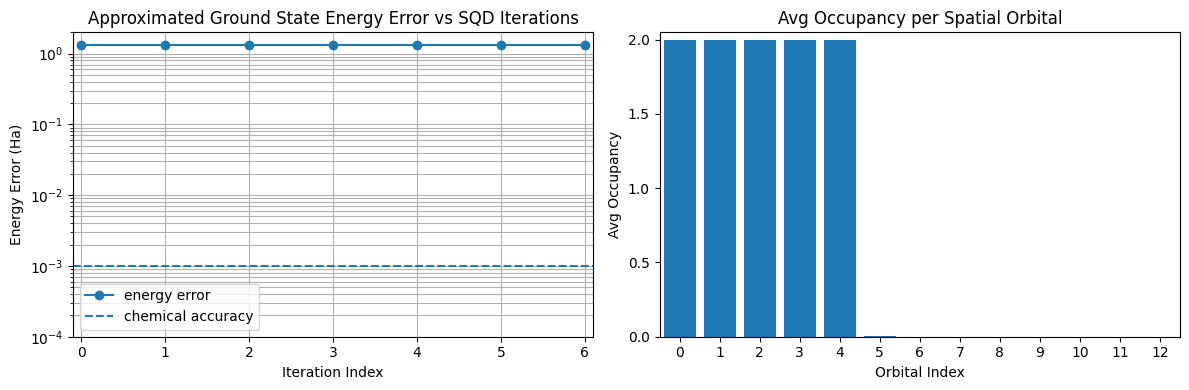

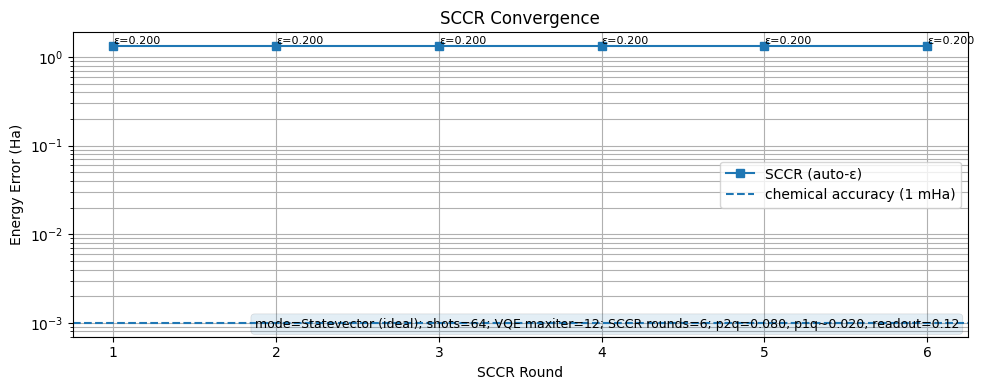

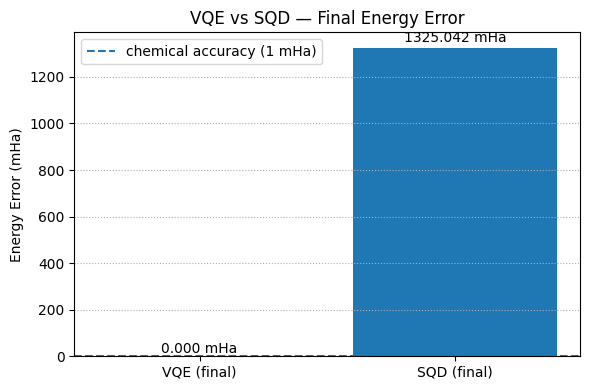


[SCCR eps by round]
round 1: eps=0.2000
round 2: eps=0.2000
round 3: eps=0.2000
round 4: eps=0.2000
round 5: eps=0.2000
round 6: eps=0.2000

[Final errors (mHa)]
VQE (final) : 0.000 mHa
SQD (final) : 1325.042 mHa

=== RUN @ shots=16, p2q=0.020, readout=0.10 ===
[PRIMS] SamplerV2/EstimatorV2 not available: Options.__init__() got an unexpected keyword argument 'noise_model'
[PRIMS] Aer primitives not available: Estimator.__init__() got an unexpected keyword argument 'options'
[PRIMS] Will fall back to ideal Statevector path (no external noise).
converged SCF energy = -75.9839845437901
CASCI E = -75.9851994378857  E(CI) = -12.9864133061831  S^2 = 0.0000000
Iter   1 | E = -12.986373166620 Ha
Iter   2 | E = -12.986409459813 Ha
Iter   3 | E = -12.986411888155 Ha
Iter   4 | E = -12.986413261068 Ha
Iter   5 | E = -12.986413305069 Ha
Iter   6 | E = -12.986413306155 Ha
  -> VQE=0.000 mHa, SQD=1325.042 mHa, winner=VQE, adv=-1325.042 mHa [Statevector]

=== RUN @ shots=32, p2q=0.020, readout=0.10 

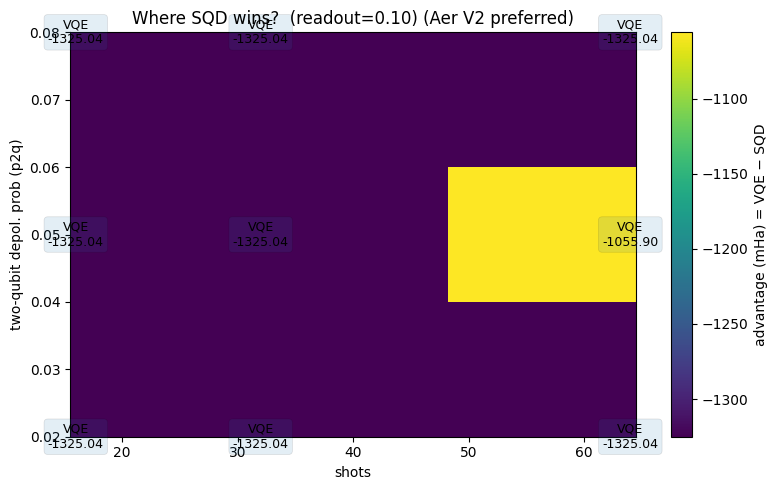

In [ ]:
# -*- coding: utf-8 -*-
# Fair VQE vs SQD on H2O CAS(6,4) with multi-round SCCR + Aer V2 Parameter Scan
# - Qiskit 2.x + Nature 0.7.x + Aer + PySCF + SciPy + pandas
# - 兩邊同噪聲/同 shots（Aer V2 優先; 無則回退 V1; 再無則 statevector）
# - SCCR 多輪（含可選 auto-ε），位元端序/自旋分塊對齊
# Docs: EstimatorV2/SamplerV2, join_data().get_counts(), NoiseModel building
# (See: IBM Quantum & Aer docs cited in the conversation)

import numpy as np, matplotlib.pyplot as plt, warnings, pandas as pd
from dataclasses import dataclass

from qiskit_nature.units import DistanceUnit
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.second_q.transformers import FreezeCoreTransformer, ActiveSpaceTransformer
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.circuit.library import HartreeFock, UCCSD
from qiskit.quantum_info import SparsePauliOp, Statevector
from scipy.optimize import minimize
from pyscf import gto, scf, mcscf

warnings.filterwarnings("ignore")
np.set_printoptions(precision=12, suppress=True)

# ========= 全域控制 =========
FAIR_NOISE  = True      # True: 用 Aer（同噪聲/同 shots）；False: 兩邊都走 ideal statevector
SHOTS       = 64        # Sampler/VQE 的 shots；強 NISQ 可降到 32/16
SCCR_ROUNDS = 6         # SCCR 輪數（5~8 較穩）
VQE_MAXITER = 12        # VQE 疊代上限（強雜訊/低 shots 下建議降低）

# 噪聲參數（兩邊共用；供 Aer primitives 使用）
NOISE_P2Q   = 0.08      # 兩量子閘 depolarizing 機率
NOISE_P1Q   = 0.25*NOISE_P2Q  # 1q depol 近似比例（可調）
READOUT_P   = 0.12      # 讀出錯誤率

# SCCR 修補 ε 參數（可選：固定或自動）
USE_AUTO_EPS  = True
EPS_FIXED     = 0.01
EPS_MIN, EPS_MAX = 0.005, 0.20
EPS_C1, EPS_C2   = 0.8, 0.5    # auto-ε = 0.01 + c1*RMSE(occ-gap) + c2/sqrt(shots)

SEED = 7
rng_global = np.random.default_rng(SEED)
np.random.seed(SEED)

# ======= 建構 Aer primitives（V2 優先；V1 次之；最後 statevector） =======
def make_aer_primitives_or_fallback(shots=SHOTS, seed=SEED,
                                    p1q=NOISE_P1Q, p2q=NOISE_P2Q, readout_p=READOUT_P):
    noise_model = None
    estimator = None
    sampler   = None
    have_v2 = False
    have_v1 = False
    if FAIR_NOISE:
        try:
            # -- V2 嘗試 --
            from qiskit_aer.noise import NoiseModel, depolarizing_error, ReadoutError
            from qiskit_aer.primitives import SamplerV2, EstimatorV2
            nm = NoiseModel()
            nm.add_all_qubit_quantum_error(depolarizing_error(p1q, 1), ['id','rz','sx','x'])
            nm.add_all_qubit_quantum_error(depolarizing_error(p2q, 2), ['cx'])
            nm.add_all_qubit_readout_error(ReadoutError([[1-readout_p, readout_p],
                                                         [readout_p, 1-readout_p]]))
            estimator = EstimatorV2(options={'noise_model': nm, 'seed': seed})
            sampler   = SamplerV2(default_shots=shots, seed=seed, options={'noise_model': nm})
            noise_model = nm
            have_v2 = True
            print("[PRIMS] Using Aer EstimatorV2 / SamplerV2 with noise_model + shots.")
        except Exception as e_v2:
            print("[PRIMS] SamplerV2/EstimatorV2 not available:", e_v2)
            try:
                # -- V1 回退 --
                from qiskit_aer.noise import NoiseModel, depolarizing_error, ReadoutError
                from qiskit_aer.primitives import Sampler, Estimator
                nm = NoiseModel()
                nm.add_all_qubit_quantum_error(depolarizing_error(p1q, 1), ['id','rz','sx','x'])
                nm.add_all_qubit_quantum_error(depolarizing_error(p2q, 2), ['cx'])
                nm.add_all_qubit_readout_error(ReadoutError([[1-readout_p, readout_p],
                                                             [readout_p, 1-readout_p]]))
                estimator = Estimator(run_options={'shots': shots}, options={'noise_model': nm})
                sampler   = Sampler(run_options={'shots': shots}, options={'noise_model': nm})
                noise_model = nm
                have_v1 = True
                print("[PRIMS] Falling back to Aer Estimator/Sampler (V1) with noise_model + shots.")
            except Exception as e_v1:
                print("[PRIMS] Aer primitives not available:", e_v1)
                print("[PRIMS] Will fall back to ideal Statevector path (no external noise).")
    return estimator, sampler, noise_model, have_v2, have_v1

# 全域 primitives（供主流程使用）
ESTIMATOR_OBJ, SAMPLER_OBJ, NOISE_MODEL, HAVE_V2, HAVE_V1 = make_aer_primitives_or_fallback()

# ---- Sampler（V2/V1/None）統一取樣 ----
def sample_with_any_sampler(circuit, theta, n_qubits, shots, sampler_obj, have_v2_or_v1):
    # 參數化 + 測量
    qc = circuit.assign_parameters({p: float(v) for p, v in zip(circuit.parameters, np.asarray(theta))}, inplace=False)
    qc = qc.measure_all(inplace=False)
    if sampler_obj is None:
        # statevector 機率抽樣
        sv = Statevector.from_instruction(qc.remove_final_measurements(inplace=False))
        probs = sv.probabilities()
        idx = rng_global.choice(len(probs), size=shots, p=probs)
        return [format(i, f"0{n_qubits}b") for i in idx]
    # Aer Sampler（V2 或 V1）
    job = sampler_obj.run([qc], shots=shots)
    res = job.result()[0]
    try:
        # V2 標準用法：join_data().get_counts()
        counts = res.join_data().get_counts()  # 會自動合併所有 classical registers
    except Exception:
        # V1 或不同欄位名稱
        data_fields = list(vars(res.data).keys())
        key = 'meas' if 'meas' in data_fields else (data_fields[0] if data_fields else None)
        counts = getattr(res.data, key).get_counts()
    out = []
    for s, c in counts.items():
        s2 = s if len(s) == n_qubits else f"{int(s, 2):0{n_qubits}b}"
        out.extend([s2] * int(c))
    return out

# ---------- 小工具：端序/字串 ↔ 布林矩陣 ----------
def _bitstrings_from_counts(counts_dict, n_qubits):
    out = []
    for s, c in counts_dict.items():
        s2 = s if len(s) == n_qubits else f"{int(s, 2):0{n_qubits}b}"
        out.extend([s2] * int(c))
    return out

def _bitstrings_to_bool_matrix_big_to_little(bs_list, n_qubits):
    # Qiskit: little-endian；將顯示字串（big-endian）反轉
    M = np.zeros((len(bs_list), n_qubits), dtype=bool)
    for r, s in enumerate(bs_list):
        s2 = s[::-1]
        M[r] = np.fromiter((c == "1" for c in s2), dtype=bool, count=n_qubits)
    return M

def _alpha_beta_to_beta_alpha(mat_ab):
    n = mat_ab.shape[1] // 2
    return np.hstack([mat_ab[:, n:], mat_ab[:, :n]])  # 左=beta, 右=alpha（SCCR 假設）

def _bool_matrix_to_bitstrings_little_to_big(mat_bool):
    out = []
    for row in mat_bool:
        s_little = "".join("1" if b else "0" for b in row)
        out.append(s_little[::-1])  # little→big
    return out

def _indices_from_big_endian_bitstrings(bs_list):
    return [int(s[::-1], 2) for s in bs_list]  # big→little 再轉 index

# ============ SCCR fallback（可調 ε） ============
def _p_flip_0_to_1(ratio_exp, occ, eps=0.01):
    if occ < ratio_exp:
        return occ * eps / ratio_exp if ratio_exp > 0 else 0.0
    if ratio_exp == 1.0: return eps
    slope = (1 - eps) / (1 - ratio_exp); intercept = 1 - slope
    return occ * slope + intercept

def _p_flip_1_to_0(ratio_exp, occ, eps=0.01):
    if occ < ratio_exp:
        slope = -(1.0 - eps) / ratio_exp if ratio_exp > 0 else 0.0
        return 1.0 + occ * slope
    if ratio_exp == 0.0: return 1 - eps
    slope = -eps / (1 - ratio_exp); intercept = eps / (1 - ratio_exp)
    return occ * slope + intercept

def _bipartite_bitstring_correcting(bit_array, avg_occupancies, hamming_right, hamming_left,
                                    rng, eps_left=0.01, eps_right=0.01):
    # avg_occupancies: (beta, alpha) 展平；bit_array: [LEFT|RIGHT]=[beta|alpha]
    bit_array = bit_array.copy()
    nbits = bit_array.shape[0]; N = nbits // 2
    pl = np.zeros(N); pr = np.zeros(N)
    for i in range(N):
        pl[i] = _p_flip_1_to_0(hamming_left/N,  avg_occupancies[i],     eps_left) if bit_array[i]     else _p_flip_0_to_1(hamming_left/N,  avg_occupancies[i],     eps_left)
        pr[i] = _p_flip_1_to_0(hamming_right/N, avg_occupancies[i+N], eps_right) if bit_array[i+N] else _p_flip_0_to_1(hamming_right/N, avg_occupancies[i+N], eps_right)
    pl = np.abs(pl); pr = np.abs(pr); pl /= pl.sum(); pr /= pr.sum()
    # LEFT（beta）
    nL = int(bit_array[:N].sum()); d = nL - hamming_left
    if d > 0:
        idx1 = np.where(bit_array[:N])[0]; pch = pl[bit_array[:N]] / pl[bit_array[:N]].sum()
        flip = rng.choice(idx1, size=round(d), replace=False, p=pch); bit_array[:N][flip] = False
    elif d < 0:
        idx0 = np.where(~bit_array[:N])[0]; pch = pl[~bit_array[:N]] / pl[~bit_array[:N]].sum()
        flip = rng.choice(idx0, size=round(abs(d)), replace=False, p=pch); bit_array[:N][flip] = True
    # RIGHT（alpha）
    nR = int(bit_array[N:].sum()); d = nR - hamming_right
    if d > 0:
        idx1 = np.where(bit_array[N:])[0]; pch = pr[bit_array[N:]] / pr[bit_array[N:]].sum()
        flip = rng.choice(idx1, size=round(d), replace=False, p=pch); bit_array[N:][flip] = False
    elif d < 0:
        idx0 = np.where(~bit_array[N:])[0]; pch = pr[~bit_array[N:]] / pr[~bit_array[N:]].sum()
        flip = rng.choice(idx0, size=round(abs(d)), replace=False, p=pch); bit_array[N:][flip] = True
    return bit_array

def post_select_by_hamming_weight(bitstring_matrix, *, hamming_right, hamming_left):
    nbits = bitstring_matrix.shape[1]; N = nbits // 2
    right_ok = (bitstring_matrix[:, N:].sum(axis=1) == hamming_right)
    left_ok  = (bitstring_matrix[:, :N].sum(axis=1) == hamming_left)
    return np.array(np.logical_and(right_ok, left_ok))

def recover_configurations(bitstring_matrix, probabilities, avg_occupancies, num_elec_a, num_elec_b,
                           rand_seed=None, eps_left=0.01, eps_right=0.01):
    rng = np.random.default_rng(rand_seed)
    corrected = {}
    # 將 (alpha,beta) 轉成 (beta,alpha) 展平（SCCR 假設）
    occs_array = np.flip(avg_occupancies).flatten()
    for bs, p in zip(bitstring_matrix, probabilities):
        bs2 = _bipartite_bitstring_correcting(bs, occs_array, num_elec_a, num_elec_b, rng,
                                              eps_left=eps_left, eps_right=eps_right)
        key = "".join("1" if b else "0" for b in bs2)
        corrected[key] = corrected.get(key, 0.0) + float(p)
    keys = list(corrected.keys())
    mat  = np.array([[c == "1" for c in s] for s in keys], dtype=bool)
    probs = np.array([corrected[s] for s in keys], dtype=float)
    probs = np.abs(probs) / np.sum(np.abs(probs))
    return mat, probs

# ---------- 問題建構 ----------
@dataclass
class ProblemBuilderH2O:
    basis: str = "6-31g"
    freeze_core: bool = True
    active_electrons: int = 6
    active_orbitals: int = 4
    def build(self):
        drv = PySCFDriver(
            atom=("O 0.000000 0.000000 0.000000; H 0.000000 -0.757160 0.586260; H 0.000000  0.757160 0.586260"),
            basis=self.basis, charge=0, spin=0, unit=DistanceUnit.ANGSTROM
        )
        problem0 = drv.run()
        na, nb = problem0.num_particles
        self.ne_total = na + nb
        self.nmo_total = problem0.num_spatial_orbitals

        fc_t = FreezeCoreTransformer() if self.freeze_core else None
        problem = problem0
        if fc_t:
            problem = fc_t.transform(problem0); self.n_core = getattr(fc_t, "num_core_orbitals", 1)
        else:
            self.n_core = 0

        as_t = ActiveSpaceTransformer(num_electrons=self.active_electrons, num_spatial_orbitals=self.active_orbitals)
        problem = as_t.transform(problem); self.problem = problem

        ne_after_freeze = self.ne_total - 2*self.n_core
        self.n_inactive = max(0, (ne_after_freeze - self.active_electrons) // 2)
        self.n_active   = self.active_orbitals
        self.n_virtual  = max(0, self.nmo_total - (self.n_core + self.n_inactive + self.n_active))

        self.mapper = JordanWignerMapper()
        self.qubit_op: SparsePauliOp = self.mapper.map(problem.hamiltonian.second_q_op())

        self.hf = HartreeFock(problem.num_spatial_orbitals, problem.num_particles, self.mapper)
        self.uccsd = UCCSD(problem.num_spatial_orbitals, problem.num_particles, self.mapper, initial_state=self.hf, reps=1)
        return self

    def casci_reference(self):
        mol = gto.M(atom=("O 0 0 0; H 0 -0.757160 0.586260; H 0 0.757160 0.586260"),
                    basis=self.basis, charge=0, spin=0, unit="Angstrom")
        mf = scf.RHF(mol).run()
        alpha = self.active_electrons // 2; beta  = self.active_electrons - alpha
        mc = mcscf.CASCI(mf, ncas=self.active_orbitals, nelecas=(alpha, beta))
        e_tot, e_ci = mc.kernel()[:2]
        rdm1 = mc.fcisolver.make_rdm1(mc.ci, mc.ncas, mc.nelecas)
        occ_active = np.real(np.diag(rdm1))
        occ = []
        occ += [2.0]*self.n_core
        occ += [2.0]*self.n_inactive
        occ += list(occ_active)
        occ += [0.0]*self.n_virtual
        if len(occ) < 13: occ += [0.0]*(13 - len(occ))
        elif len(occ) > 13: occ = occ[:13]
        return float(e_tot), float(e_ci), np.array(occ, dtype=float)

# ---------- VQE（優先用 Aer Estimator；無則 statevector） ----------
class VQERunner:
    def __init__(self, qubit_op: SparsePauliOp, ansatz, estimator=None, shots=None):
        self.H = qubit_op; self.ansatz = ansatz
        self.theta0 = np.zeros(self.ansatz.num_parameters, dtype=float)
        self.history = {"E": [], "x": []}
        self.estimator = estimator  # 可為 V2/V1/NONE
        self.shots = shots
        self._H_mat = None

    def _sv_expectation(self, circ):
        if self._H_mat is None: self._H_mat = self.H.to_matrix(sparse=False)
        sv = Statevector.from_instruction(circ)
        val = np.vdot(sv.data, self._H_mat @ sv.data)
        return float(np.real(val))

    def _estimator_expectation(self, circ):
        if self.estimator is None:
            return self._sv_expectation(circ)
        # 嘗試 V2 調用
        try:
            job = self.estimator.run([(circ, [self.H])], shots=self.shots)
            res = job.result()[0]
            # 兼容不同欄位命名
            if hasattr(res, "data"):
                d = res.data
                if hasattr(d, "evs"):   return float(np.real(d.evs[0]))
                if hasattr(d, "means"): return float(np.real(d.means[0]))
            if hasattr(res, "values"):
                return float(np.real(res.values[0]))
        except Exception:
            pass
        # 嘗試 V1 調用
        try:
            job = self.estimator.run(circuits=[circ], observables=[self.H])
            res = job.result()
            if hasattr(res, "values"): return float(np.real(res.values[0]))
        except Exception:
            pass
        # 最終退回 statevector
        return self._sv_expectation(circ)

    def energy(self, theta):
        circ = self.ansatz.assign_parameters({p: float(v) for p, v in zip(self.ansatz.parameters, np.asarray(theta))}, inplace=False)
        return self._estimator_expectation(circ)

    def run(self, maxiter=200, ftol=1e-9):
        def cb(theta):
            E = self.energy(theta)
            self.history["E"].append(E); self.history["x"].append(np.asarray(theta).copy())
            print(f"Iter {len(self.history['E']):3d} | E = {E:.12f} Ha")
        opt = minimize(self.energy, self.theta0, method="L-BFGS-B",
                       options=dict(maxiter=maxiter, ftol=ftol), callback=cb)
        E_vqe = self.energy(opt.x)
        return E_vqe, opt

# ---------- SQD ----------
class SQDRunner:
    def __init__(self, qubit_op: SparsePauliOp, sampler=None, shots=None):
        self.H = qubit_op
        self.n = qubit_op.num_qubits
        self.H_full = self.H.to_matrix(sparse=False)
        self.sampler = sampler
        self.shots = shots if shots is not None else SHOTS

    def sample_bitstrings(self, circuit, theta=None, shots=None):
        shots = shots or self.shots
        if theta is None:
            theta = []
        if FAIR_NOISE and self.sampler is not None:
            return sample_with_any_sampler(circuit, theta, self.n, shots, self.sampler, HAVE_V2 or HAVE_V1)
        else:
            # ideal statevector 機率抽樣
            circ = circuit.assign_parameters({p: float(v) for p, v in zip(circuit.parameters, np.asarray(theta))}, inplace=False)
            sv = Statevector.from_instruction(circ)
            probs = sv.probabilities()
            idx = rng_global.choice(len(probs), size=shots, p=probs)
            return [format(i, f"0{self.n}b") for i in idx]

    def diagonalize_subspace(self, bitstrings, top_k=None):
        from collections import Counter
        cnt = Counter(bitstrings)
        basis = [b for b, _ in cnt.most_common(top_k)] if top_k else list(cnt.keys())
        if not basis: raise ValueError("No basis states sampled.")
        idx = _indices_from_big_endian_bitstrings(basis)
        HS = self.H_full[np.ix_(idx, idx)]
        vals, vecs = np.linalg.eigh(HS)
        return vals, vecs, {"basis": basis, "counts": cnt, "indices": idx}

# ---------- 由子空間基態估平均佔據 (alpha,beta) ----------
def estimate_occ_from_subspace_eigvec(basis_big_endian, eigvec, n_qubits):
    probs = np.abs(eigvec.flatten())**2
    M_little = _bitstrings_to_bool_matrix_big_to_little(basis_big_endian, n_qubits)
    occ_bits = (probs[:, None] * M_little).sum(axis=0)
    N = n_qubits // 2
    occ_alpha = occ_bits[:N]
    occ_beta  = occ_bits[N:]
    return occ_alpha, occ_beta

# ---------- 自動 ε ----------
def compute_eps_auto(avg_occ_alpha_beta, hamming_right, hamming_left, shots):
    N = len(avg_occ_alpha_beta)//2
    ratio_left  = hamming_left / N
    ratio_right = hamming_right / N
    alpha = avg_occ_alpha_beta[:N]; beta = avg_occ_alpha_beta[N:]
    delta = np.concatenate([np.abs(beta - ratio_left), np.abs(alpha - ratio_right)])
    rmse = np.sqrt(np.mean(delta**2))
    eps = EPS_FIXED + EPS_C1*rmse + EPS_C2/np.sqrt(max(1, shots))
    return float(np.clip(eps, EPS_MIN, EPS_MAX))

# ---------- 一輪 SCCR ----------
def sccr_one_round(bitstrings_this_round, probs_this_round, occ_alpha, occ_beta, na, nb,
                   shots, H, top_k, use_auto_eps=True):
    M_little_ab = _bitstrings_to_bool_matrix_big_to_little(bitstrings_this_round, H.num_qubits)
    M_ba = _alpha_beta_to_beta_alpha(M_little_ab)
    if use_auto_eps:
        eps_use = compute_eps_auto(np.concatenate([occ_alpha, occ_beta]), hamming_right=na, hamming_left=nb, shots=shots)
    else:
        eps_use = EPS_FIXED
    M_ref, p_ref = recover_configurations(M_ba, probs_this_round, (occ_alpha, occ_beta),
                                          na, nb, rand_seed=SEED, eps_left=eps_use, eps_right=eps_use)
    mask = post_select_by_hamming_weight(M_ref, hamming_right=na, hamming_left=nb)
    M_ref = M_ref[mask]; p_ref = p_ref[mask]
    if M_ref.shape[0] == 0:
        M_ref, p_ref = M_ba, probs_this_round
    p_ref = p_ref / p_ref.sum()
    bs_ref = _bool_matrix_to_bitstrings_little_to_big(M_ref)
    reps = np.maximum(1, np.round(p_ref * shots).astype(int))
    bs_pool = [s for s, rr in zip(bs_ref, reps) for _ in range(rr)]

    sqd = SQDRunner(H)
    vals_r, vecs_r, meta_r = sqd.diagonalize_subspace(bs_pool, top_k=top_k)
    v0 = vecs_r[:, 0]
    occ_alpha_new, occ_beta_new = estimate_occ_from_subspace_eigvec(meta_r["basis"], v0, H.num_qubits)
    return bs_pool, float(vals_r[0]), occ_alpha_new, occ_beta_new, eps_use

# ---------- 主流程：一次產圖（VQE×SQD、公平條件） ----------
def run_all(k_schedule=(1,5,10,20,40,80,128)):
    pb = ProblemBuilderH2O().build()
    H = pb.qubit_op
    print(f"n_qubits = {H.num_qubits} | total spatial orbitals (pre-transform) = {pb.nmo_total}")
    E_tot, E_ci, occ_all = pb.casci_reference()

    # --- VQE（同噪聲/同 shots：若有 Estimator；否則 ideal）---
    vqe = VQERunner(H, pb.uccsd, estimator=ESTIMATOR_OBJ, shots=SHOTS)
    E_vqe, opt = vqe.run(maxiter=VQE_MAXITER, ftol=1e-3 if FAIR_NOISE and (HAVE_V2 or HAVE_V1) else 1e-9)
    print(f"\nVQE (electronic)  : {E_vqe:.12f} Ha")
    print(f"CASCI (electronic): {E_ci :.12f} Ha")
    print(f"ΔE_VQE = {1000*(E_vqe-E_ci):+.3f} mHa")

    # --- SQD（多輪 SCCR；V2/V1 Sampler 或 ideal 抽樣）---
    sqd_sampler = SQDRunner(H, sampler=SAMPLER_OBJ, shots=SHOTS)
    na, nb = pb.problem.num_particles
    start = pb.n_core + pb.n_inactive
    occ_active_total = occ_all[start : start + pb.n_active]
    occ_alpha0 = np.clip(occ_active_total/2.0, 0.0, 1.0)
    occ_beta0  = np.clip(occ_active_total/2.0, 0.0, 1.0)

    # 每輪先固定同一批樣本（公平）
    bs_rounds = []; probs_rounds = []
    for r in range(SCCR_ROUNDS):
        bs_samples = sqd_sampler.sample_bitstrings(pb.uccsd, theta=opt.x, shots=SHOTS)
        from collections import Counter
        cnt = Counter(bs_samples)
        uniq_bs = list(cnt.keys())
        probs   = np.array([cnt[b] for b in uniq_bs], dtype=float); probs /= probs.sum()
        bs_rounds.append(uniq_bs); probs_rounds.append(probs)

    # ---- SCCR（使用 auto-ε 或固定 ε）----
    occ_a, occ_b = occ_alpha0.copy(), occ_beta0.copy()
    bs_pool = None; err_by_round = []; eps_by_round = []
    for r in range(SCCR_ROUNDS):
        bs_pool, E0, occ_a, occ_b, eps_used = sccr_one_round(
            bs_rounds[r], probs_rounds[r], occ_a, occ_b, na, nb,
            shots=SHOTS, H=H, top_k=max(k_schedule), use_auto_eps=USE_AUTO_EPS
        )
        err_by_round.append(abs(E0 - E_ci)); eps_by_round.append(eps_used)
        print(f"[SCCR {r+1}] E0~{E0:.8f} Ha | eps={eps_used:.4f}")

    vals, vecs, meta = SQDRunner(H).diagonalize_subspace(bs_pool, top_k=max(k_schedule))
    E_sqd = float(vals[0])
    print(f"\nSQD  (electronic) : {E_sqd:.12f} Ha")
    print(f"ΔE_SQD = {1000*(E_sqd-E_ci):+.3f} mHa")

    # --- SQD 誤差 vs top_k（以最終池）---
    err_curve = []
    for k in k_schedule:
        vals_k, _, _ = SQDRunner(H).diagonalize_subspace(bs_pool, top_k=k)
        err_curve.append(abs(float(vals_k[0]) - E_ci))
    err_curve = np.asarray(err_curve)

    # ===== 圖 1：SQD 誤差 vs top_k；圖 2：CASCI 佔據 =====
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    x = np.arange(len(k_schedule)); y = err_curve.copy()
    ax1.plot(x, y, marker="o", label="energy error"); ax1.axhline(1e-3, ls="--", label="chemical accuracy")
    ax1.set_xlabel("Iteration Index"); ax1.set_ylabel("Energy Error (Ha)")
    ax1.set_xscale("linear"); ax1.set_xticks(np.arange(0, len(k_schedule), 1)); ax1.set_xlim(-0.1, len(k_schedule)-1+0.1)
    ax1.set_yscale("log"); ax1.set_yticks([1e-4, 1e-3, 1e-2, 1e-1, 1e0]); ax1.set_ylim(1e-4, 2.0)
    ax1.set_title("Approximated Ground State Energy Error vs SQD Iterations"); ax1.grid(True, which="both"); ax1.legend()

    ax2.bar(np.arange(len(occ_all[:13])), occ_all[:13]); ax2.set_xlabel("Orbital Index"); ax2.set_ylabel("Avg Occupancy")
    ax2.set_xticks(np.arange(0, 13, 1)); ax2.set_xlim(-0.5, 12.5); ax2.set_yticks(np.arange(0.0, 2.0+0.5, 0.5)); ax2.set_ylim(0.0, 2.05)
    ax2.set_title("Avg Occupancy per Spatial Orbital")
    plt.tight_layout(); plt.show()

    # ===== 圖 3：SCCR 收斂疊圖（顯示每輪誤差與 ε）=====
    rounds = np.arange(1, SCCR_ROUNDS+1)
    plt.figure(figsize=(10,4))
    plt.plot(rounds, err_by_round, marker="s", label=f"SCCR ({'auto-ε' if USE_AUTO_EPS else f'fixed ε={EPS_FIXED}'})")
    plt.axhline(1.0e-3, ls="--", label="chemical accuracy (1 mHa)")
    for r, e in enumerate(err_by_round, start=1):
        plt.text(r, e, f"ε={eps_by_round[r-1]:.3f}", ha="left", va="bottom", fontsize=8)
    plt.yscale("log"); plt.xlabel("SCCR Round"); plt.ylabel("Energy Error (Ha)")
    note = (f"mode={'Aer (noisy)' if FAIR_NOISE and (HAVE_V2 or HAVE_V1) else 'Statevector (ideal)'}; "
            f"shots={SHOTS}; VQE maxiter={VQE_MAXITER}; SCCR rounds={SCCR_ROUNDS}; "
            f"p2q={NOISE_P2Q:.3f}, p1q~{NOISE_P1Q:.3f}, readout={READOUT_P:.2f}")
    plt.title("SCCR Convergence"); plt.grid(True, which="both"); plt.legend()
    plt.text(0.99, 0.02, note, transform=plt.gca().transAxes, ha="right", va="bottom",
             fontsize=9, bbox=dict(boxstyle="round", alpha=0.12, lw=0.5))
    plt.tight_layout(); plt.show()

    # ===== 圖 4：最終誤差雙柱（VQE vs SQD）=====
    err_vqe_final_mha = abs(E_vqe - E_ci) * 1e3
    err_sqd_final_mha = abs(E_sqd - E_ci) * 1e3
    plt.figure(figsize=(6,4))
    bars = plt.bar([0,1], [err_vqe_final_mha, err_sqd_final_mha], tick_label=["VQE (final)","SQD (final)"])
    for i, b in enumerate(bars):
        plt.text(b.get_x()+b.get_width()/2, b.get_height()*1.01,
                 f"{[err_vqe_final_mha, err_sqd_final_mha][i]:.3f} mHa", ha="center", va="bottom")
    plt.axhline(1.0, ls="--", label="chemical accuracy (1 mHa)")
    plt.ylabel("Energy Error (mHa)")
    plt.title("VQE vs SQD — Final Energy Error")
    plt.grid(True, axis="y", linestyle=":"); plt.legend(); plt.tight_layout(); plt.show()

    # ===== 文字輸出（供審稿表用）=====
    print("\n[SCCR eps by round]")
    for r,e in enumerate(eps_by_round, start=1): print(f"round {r}: eps={e:.4f}")
    print("\n[Final errors (mHa)]")
    print(f"VQE (final) : {err_vqe_final_mha:.3f} mHa")
    print(f"SQD (final) : {err_sqd_final_mha:.3f} mHa")
    return {"E_ci":E_ci, "E_vqe":E_vqe, "E_sqd":E_sqd,
            "err_vqe_mHa":err_vqe_final_mha, "err_sqd_mHa":err_sqd_final_mha}

# ============================================================
# Parameter Scan (Aer V2 優先)：多組 (shots × p2q × readout) 掃描 + 總表 + 熱圖
# ============================================================
from collections import Counter

# 掃描網格（可調）
SHOTS_LIST    = [16, 32, 64]
P2Q_LIST      = [0.02, 0.05, 0.08]
READOUT_LIST  = [0.10]              # 可放多個：例如 [0.08, 0.10, 0.15]
P1Q_RATIO     = 0.25                # p1q = ratio * p2q

# 掃描時的管線參數
SCCR_ROUNDS_SCAN = 4
VQE_MAXITER_SCAN = 10
K_SCHEDULE_SCAN  = (1, 5, 10, 20, 40)
SEED_SCAN        = 7

def make_prims_for_condition(shots, p2q, readout_p, seed=SEED_SCAN, p1q_ratio=P1Q_RATIO):
    p1q = p2q * p1q_ratio
    return make_aer_primitives_or_fallback(shots=shots, seed=seed, p1q=p1q, p2q=p2q, readout_p=readout_p)

def sample_with_sampler(circuit, theta, shots, sampler, n_qubits):
    # 同一個 V2/V1 函式
    return sample_with_any_sampler(circuit, theta, n_qubits, shots, sampler, HAVE_V2 or HAVE_V1)

def run_one_condition(shots, p2q, readout_p, p1q_ratio=P1Q_RATIO,
                      sccr_rounds=SCCR_ROUNDS_SCAN, vqe_maxiter=VQE_MAXITER_SCAN,
                      k_schedule=K_SCHEDULE_SCAN, seed=SEED_SCAN):
    estimator, sampler, noise_model, have_v2, have_v1 = make_prims_for_condition(shots, p2q, readout_p, seed, p1q_ratio)

    pb = ProblemBuilderH2O().build()
    H  = pb.qubit_op
    E_tot, E_ci, occ_all = pb.casci_reference()

    # --- VQE（同噪聲/同 shots 若有；否則 ideal）---
    vqe = VQERunner(H, pb.uccsd, estimator=estimator, shots=shots)
    E_vqe, opt = vqe.run(maxiter=vqe_maxiter, ftol=1e-3 if (have_v2 or have_v1) else 1e-9)
    err_vqe_mHa = abs(E_vqe - E_ci) * 1e3

    # --- SQD（同噪聲/同 shots；多輪 SCCR）---
    na, nb = pb.problem.num_particles
    start = pb.n_core + pb.n_inactive
    occ_active_total = occ_all[start : start + pb.n_active]
    occ_alpha = np.clip(occ_active_total/2.0, 0.0, 1.0)
    occ_beta  = np.clip(occ_active_total/2.0, 0.0, 1.0)

    theta_use = opt.x
    n_qubits = H.num_qubits
    bs_pool = None
    for r in range(sccr_rounds):
        bs_samples = sample_with_any_sampler(pb.uccsd, theta_use, n_qubits, shots, sampler, have_v2 or have_v1)
        cnt = Counter(bs_samples)
        uniq_bs = list(cnt.keys())
        probs   = np.array([cnt[b] for b in uniq_bs], dtype=float); probs /= probs.sum()

        M_little_ab = _bitstrings_to_bool_matrix_big_to_little(uniq_bs, n_qubits)
        M_ba = _alpha_beta_to_beta_alpha(M_little_ab)

        eps_use = compute_eps_auto(np.concatenate([occ_alpha, occ_beta]), hamming_right=na, hamming_left=nb, shots=shots) if USE_AUTO_EPS else EPS_FIXED
        M_ref, p_ref = recover_configurations(M_ba, probs, (occ_alpha, occ_beta), na, nb, rand_seed=seed,
                                              eps_left=eps_use, eps_right=eps_use)
        mask = post_select_by_hamming_weight(M_ref, hamming_right=na, hamming_left=nb)
        M_ref = M_ref[mask]; p_ref = p_ref[mask];
        if M_ref.shape[0] == 0:
            M_ref, p_ref = M_ba, probs
        p_ref /= p_ref.sum()

        bs_ref = _bool_matrix_to_bitstrings_little_to_big(M_ref)
        reps = np.maximum(1, np.round(p_ref * shots).astype(int))
        bs_pool = [s for s, rr in zip(bs_ref, reps) for _ in range(rr)]

        # 子空間對角化 + 更新佔據
        vals_r, vecs_r, meta_r = SQDRunner(H).diagonalize_subspace(bs_pool, top_k=max(k_schedule))
        v0 = vecs_r[:, 0]
        occ_alpha, occ_beta = estimate_occ_from_subspace_eigvec(meta_r["basis"], v0, n_qubits)

    vals, vecs, meta = SQDRunner(H).diagonalize_subspace(bs_pool, top_k=max(k_schedule))
    E_sqd = float(vals[0])
    err_sqd_mHa = abs(E_sqd - E_ci) * 1e3

    winner = "SQD" if err_sqd_mHa < err_vqe_mHa else "VQE"
    adv_mHa = err_vqe_mHa - err_sqd_mHa  # >0 代表 SQD 佔優
    return {
        "shots": shots, "p2q": p2q, "p1q": p2q*p1q_ratio, "readout": readout_p,
        "SCCR_rounds": sccr_rounds, "VQE_maxiter": vqe_maxiter,
        "err_vqe_mHa": err_vqe_mHa, "err_sqd_mHa": err_sqd_mHa,
        "adv_mHa": adv_mHa, "winner": winner,
        "mode": "Aer-V2/V1" if (have_v2 or have_v1) else "Statevector"
    }

def parameter_scan(shots_list=SHOTS_LIST, p2q_list=P2Q_LIST, readout_list=READOUT_LIST):
    results = []
    for readout_p in readout_list:
        for p2q in p2q_list:
            for shots in shots_list:
                print(f"\n=== RUN @ shots={shots}, p2q={p2q:.3f}, readout={readout_p:.2f} ===")
                res = run_one_condition(
                    shots=shots, p2q=p2q, readout_p=readout_p,
                    sccr_rounds=SCCR_ROUNDS_SCAN, vqe_maxiter=VQE_MAXITER_SCAN,
                    k_schedule=K_SCHEDULE_SCAN, seed=SEED_SCAN
                )
                print(f"  -> VQE={res['err_vqe_mHa']:.3f} mHa, SQD={res['err_sqd_mHa']:.3f} mHa, winner={res['winner']}, adv={res['adv_mHa']:+.3f} mHa [{res['mode']}]")
                results.append(res)
    df = pd.DataFrame(results).sort_values(["readout","p2q","shots"]).reset_index(drop=True)
    df.to_csv("scan_results.csv", index=False)
    print("\n=== Summary (first 20 rows) ===")
    print(df.head(20).to_string(index=False))
    return df

def plot_heatmap(df, readout_pick=None, title_note=""):
    import matplotlib.pyplot as plt
    if readout_pick is None:
        readout_pick = sorted(df["readout"].unique())[0]
    df_sub = df[df["readout"] == readout_pick].copy()
    pivot = df_sub.pivot(index="p2q", columns="shots", values="adv_mHa")
    plt.figure(figsize=(8, 5))
    im = plt.imshow(pivot.values, aspect="auto", origin="lower",
                    extent=[pivot.columns.min()-0.5, pivot.columns.max()+0.5,
                            pivot.index.min(), pivot.index.max()])
    plt.colorbar(im, label="advantage (mHa) = VQE − SQD")  # >0 → SQD 優
    plt.clim(vmin=np.nanmin(pivot.values), vmax=np.nanmax(pivot.values))
    for yi, p2 in enumerate(pivot.index):
        for xi, sh in enumerate(pivot.columns):
            val = pivot.loc[p2, sh]
            label = "SQD" if val > 0 else "VQE"
            plt.text(sh, p2, f"{label}\n{val:+.2f}", ha="center", va="center", fontsize=9,
                     bbox=dict(boxstyle="round", alpha=0.12, lw=0.5))
    plt.title(f"Where SQD wins?  (readout={readout_pick:.2f}) {title_note}")
    plt.xlabel("shots"); plt.ylabel("two-qubit depol. prob (p2q)")
    plt.tight_layout(); plt.show()

# ======= 直接執行：主流程 + 參數掃描（可把 RUN_SCAN 改 False 以快速試跑） =======
RUN_SCAN = True

results_main = run_all(k_schedule=(1,5,10,20,40,80,128))
if RUN_SCAN:
    df_scan = parameter_scan(SHOTS_LIST, P2Q_LIST, READOUT_LIST)
    plot_heatmap(df_scan, readout_pick=READOUT_LIST[0], title_note="(Aer V2 preferred)")


**again**

[PRIMS] V2 failed -> try V1: Options.__init__() got an unexpected keyword argument 'seed'
[PRIMS] Aer primitives not available: Estimator.__init__() got an unexpected keyword argument 'options'
[PRIMS] Will fall back to ideal Statevector path (no external noise).
n_qubits = 8 | total spatial orbitals (pre-transform) = 13
converged SCF energy = -75.98398454379
CASCI E = -75.9851994378858  E(CI) = -12.9864133061832  S^2 = 0.0000000
Iter   1 | E = -12.986373166679 Ha
Iter   2 | E = -12.986409459747 Ha
Iter   3 | E = -12.986411889569 Ha
Iter   4 | E = -12.986413259375 Ha
Iter   5 | E = -12.986413304649 Ha
Iter   6 | E = -12.986413306159 Ha

VQE (electronic)  : -12.986413306159 Ha
CASCI (electronic): -12.986413306183 Ha
ΔE_VQE = +0.000 mHa
[SCCR 1] E0~-11.66137105 Ha | eps=0.1000
[SCCR 2] E0~-11.66137105 Ha | eps=0.1000
[SCCR 3] E0~-11.66137105 Ha | eps=0.1000
[SCCR 4] E0~-11.66137105 Ha | eps=0.1000
[SCCR 5] E0~-11.66137105 Ha | eps=0.1000
[SCCR 6] E0~-11.66137105 Ha | eps=0.1000

SQD  (el

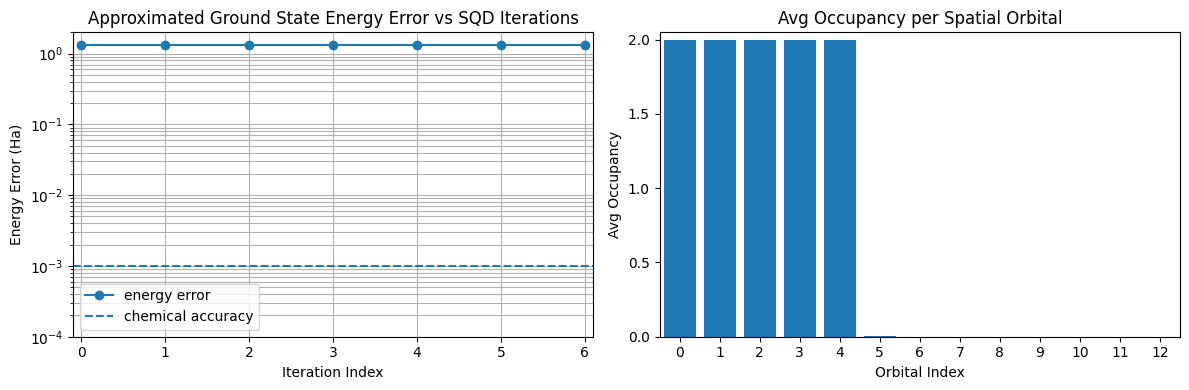

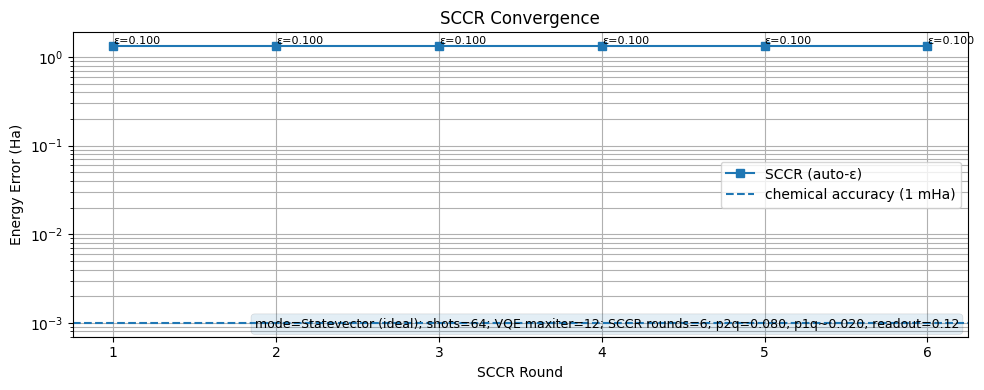

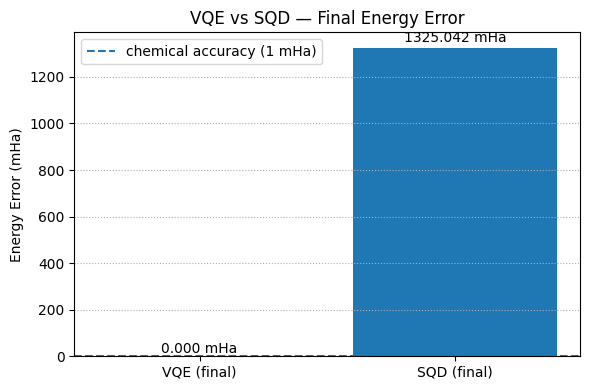


[SCCR eps by round]
round 1: eps=0.1000
round 2: eps=0.1000
round 3: eps=0.1000
round 4: eps=0.1000
round 5: eps=0.1000
round 6: eps=0.1000

[Final errors (mHa)]
VQE (final) : 0.000 mHa
SQD (final) : 1325.042 mHa

=== RUN @ shots=16, p2q=0.020, readout=0.10 ===
[PRIMS] V2 failed -> try V1: Options.__init__() got an unexpected keyword argument 'seed'
[PRIMS] Aer primitives not available: Estimator.__init__() got an unexpected keyword argument 'options'
[PRIMS] Will fall back to ideal Statevector path (no external noise).
converged SCF energy = -75.98398454379
CASCI E = -75.9851994378857  E(CI) = -12.9864133061832  S^2 = 0.0000000
Iter   1 | E = -12.986373166679 Ha
Iter   2 | E = -12.986409459620 Ha
Iter   3 | E = -12.986411889189 Ha
Iter   4 | E = -12.986413258880 Ha
Iter   5 | E = -12.986413304734 Ha
Iter   6 | E = -12.986413306145 Ha
  -> VQE=0.000 mHa, SQD=1325.042 mHa, winner=VQE, adv=-1325.042 mHa [Statevector]

=== RUN @ shots=32, p2q=0.020, readout=0.10 ===
[PRIMS] V2 failed -> 

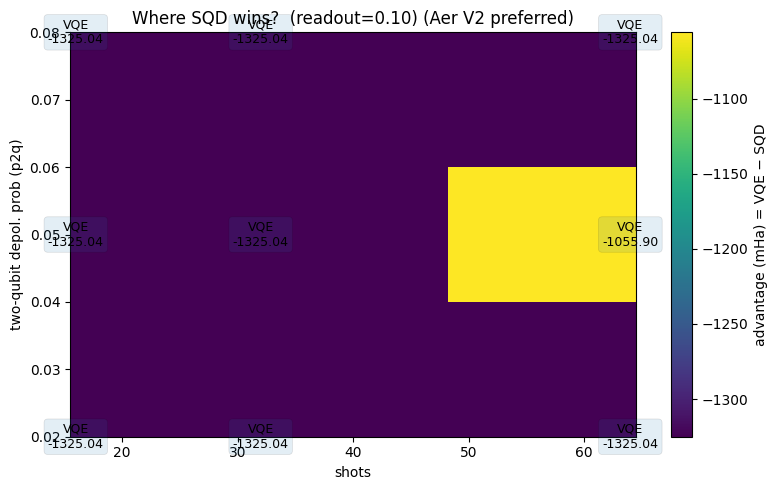

In [ ]:
# -*- coding: utf-8 -*-
# Fair VQE vs SQD on H2O CAS(6,4) with multi-round SCCR + Aer V2/V1 + Parameter Scan
# - Qiskit 1.4.2 + Nature 0.7.x + Aer 0.17.x + PySCF + SciPy + pandas
# - 兩邊同噪聲/同 shots（Aer V2 優先；無則 Aer V1；再無則 statevector）
# - SCCR 多輪（可選 auto-ε），位元端序/自旋分塊對齊
# - 參考：IBM Docs — Aer primitives noisy simulation & NoiseModel API（backend_options.noise_model）
#   (Exact & noisy simulation with Aer primitives; Building noise models; SamplerV2/NoiseModel docs)

import numpy as np, matplotlib.pyplot as plt, warnings, pandas as pd
from dataclasses import dataclass

from qiskit_nature.units import DistanceUnit
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.second_q.transformers import FreezeCoreTransformer, ActiveSpaceTransformer
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.circuit.library import HartreeFock, UCCSD
from qiskit.quantum_info import SparsePauliOp, Statevector

from scipy.optimize import minimize
from pyscf import gto, scf, mcscf

warnings.filterwarnings("ignore")
np.set_printoptions(precision=12, suppress=True)

# ========= 全域控制 =========
FAIR_NOISE   = True        # True: 用 Aer（同噪聲/同 shots）；False: 兩邊都走 ideal statevector
SHOTS        = 64          # Sampler/VQE 的 shots；強 NISQ 可降到 32/16
SCCR_ROUNDS  = 6           # SCCR 輪數（4~8 較穩）
VQE_MAXITER  = 12          # VQE 疊代上限（強雜訊/低 shots 下建議降低）

# 噪聲參數（兩邊共用；供 Aer primitives 使用）
NOISE_P2Q    = 0.08        # 兩量子閘 depolarizing 機率
NOISE_P1Q    = 0.25*NOISE_P2Q  # 1q depol 近似比例
READOUT_P    = 0.12        # 讀出錯誤率

# SCCR 修補 ε 參數（可選：固定或自動）
USE_AUTO_EPS  = True
EPS_FIXED     = 0.01
EPS_MIN, EPS_MAX = 0.005, 0.10
EPS_C1, EPS_C2   = 0.8, 0.5   # auto-ε = EPS_FIXED + C1*RMSE(occ-gap) + C2/sqrt(shots)

SEED = 7
rng_global = np.random.default_rng(SEED)
np.random.seed(SEED)

# ======= 建構 Aer primitives（V2 優先；V1 次之；最後 statevector） =======
def make_aer_primitives_or_fallback(shots=SHOTS, seed=SEED,
                                    p1q=NOISE_P1Q, p2q=NOISE_P2Q, readout_p=READOUT_P):
    estimator = None
    sampler   = None
    noise_model = None
    have_v2 = False
    have_v1 = False
    if FAIR_NOISE:
        try:
            # --- 構建噪聲模型 ---
            from qiskit_aer.noise import NoiseModel, depolarizing_error, ReadoutError
            nm = NoiseModel()
            nm.add_all_qubit_quantum_error(depolarizing_error(p1q, 1), ['id','rz','sx','x'])
            nm.add_all_qubit_quantum_error(depolarizing_error(p2q, 2), ['cx'])
            nm.add_all_qubit_readout_error(
                ReadoutError([[1-readout_p, readout_p],[readout_p,1-readout_p]])
            )
            noise_model = nm

            # --- Aer V2：把 noise_model 放到 backend_options ---
            from qiskit_aer.primitives import EstimatorV2, SamplerV2
            estimator = EstimatorV2(
                options=dict(backend_options=dict(noise_model=noise_model), seed=seed)
            )
            sampler = SamplerV2(
                default_shots=shots,
                seed=seed,
                options=dict(backend_options=dict(noise_model=noise_model))
            )
            have_v2 = True
            print("[PRIMS] Using Aer EstimatorV2/SamplerV2 with backend_options.noise_model")
        except Exception as e_v2:
            print("[PRIMS] V2 failed -> try V1:", e_v2)
            try:
                # --- Aer V1：同樣把 noise_model 放 backend_options ---
                from qiskit_aer.primitives import Estimator, Sampler
                estimator = Estimator(
                    options=dict(backend_options=dict(noise_model=noise_model)),
                    run_options={'shots': shots, 'seed': seed}
                )
                sampler = Sampler(
                    options=dict(backend_options=dict(noise_model=noise_model)),
                    run_options={'shots': shots, 'seed': seed}
                )
                have_v1 = True
                print("[PRIMS] Falling back to Aer Estimator/Sampler (V1) with backend_options.noise_model")
            except Exception as e_v1:
                print("[PRIMS] Aer primitives not available:", e_v1)
                print("[PRIMS] Will fall back to ideal Statevector path (no external noise).")
    return estimator, sampler, noise_model, have_v2, have_v1

# 全域 primitives（供主流程使用）
ESTIMATOR_OBJ, SAMPLER_OBJ, NOISE_MODEL, HAVE_V2, HAVE_V1 = make_aer_primitives_or_fallback()

# ---- Sampler（V2/V1/None）統一取樣 ----
def sample_with_any_sampler(circuit, theta, n_qubits, shots, sampler_obj, have_aer):
    # 參數化 + 測量
    qc = circuit.assign_parameters({p: float(v) for p, v in zip(circuit.parameters, np.asarray(theta))}, inplace=False)
    qc = qc.measure_all(inplace=False)

    if not have_aer or sampler_obj is None:
        # statevector 機率抽樣
        sv = Statevector.from_instruction(qc.remove_final_measurements(inplace=False))
        probs = sv.probabilities()
        idx = rng_global.choice(len(probs), size=shots, p=probs)
        return [format(i, f"0{n_qubits}b") for i in idx]

    # Aer Sampler（V2 或 V1）
    job = sampler_obj.run([qc], shots=shots)
    res = job.result()[0]
    # 試多種取 counts 的方式（V2 與 V1 兼容）
    counts = None
    try:
        counts = res.join_data().get_counts()
    except Exception:
        try:
            # 嘗試通用 data.meas.get_counts()
            data_fields = list(vars(res.data).keys()) if hasattr(res, "data") else []
            key = "meas" if "meas" in data_fields else (data_fields[0] if data_fields else None)
            if key is not None:
                counts = getattr(res.data, key).get_counts()
        except Exception:
            pass

    if counts is None:
        # 最終兜底：轉回 statevector 機率抽樣
        sv = Statevector.from_instruction(qc.remove_final_measurements(inplace=False))
        probs = sv.probabilities()
        idx = rng_global.choice(len(probs), size=shots, p=probs)
        return [format(i, f"0{n_qubits}b") for i in idx]

    out = []
    for s, c in counts.items():
        s2 = s if len(s) == n_qubits else f"{int(s, 2):0{n_qubits}b}"
        out.extend([s2] * int(c))
    return out

# ---------- 小工具：端序/字串 ↔ 布林矩陣 ----------
def _bitstrings_to_bool_matrix_big_to_little(bs_list, n_qubits):
    # Qiskit: little-endian；將顯示字串（big-endian）反轉
    M = np.zeros((len(bs_list), n_qubits), dtype=bool)
    for r, s in enumerate(bs_list):
        s2 = s[::-1]
        M[r] = np.fromiter((c == "1" for c in s2), dtype=bool, count=n_qubits)
    return M

def _alpha_beta_to_beta_alpha(mat_ab):
    n = mat_ab.shape[1] // 2
    return np.hstack([mat_ab[:, n:], mat_ab[:, :n]])  # 左=beta, 右=alpha（SCCR 假設）

def _bool_matrix_to_bitstrings_little_to_big(mat_bool):
    out = []
    for row in mat_bool:
        s_little = "".join("1" if b else "0" for b in row)
        out.append(s_little[::-1])  # little→big
    return out

def _indices_from_big_endian_bitstrings(bs_list):
    return [int(s[::-1], 2) for s in bs_list]  # big→little 再轉 index

# ============ SCCR fallback（可調 ε） ============
def _p_flip_0_to_1(ratio_exp, occ, eps=0.01):
    if occ < ratio_exp:
        return occ * eps / ratio_exp if ratio_exp > 0 else 0.0
    if ratio_exp == 1.0:
        return eps
    slope = (1 - eps) / (1 - ratio_exp); intercept = 1 - slope
    return occ * slope + intercept

def _p_flip_1_to_0(ratio_exp, occ, eps=0.01):
    if occ < ratio_exp:
        slope = -(1.0 - eps) / ratio_exp if ratio_exp > 0 else 0.0
        return 1.0 + occ * slope
    if ratio_exp == 0.0:
        return 1 - eps
    slope = -eps / (1 - ratio_exp); intercept = eps / (1 - ratio_exp)
    return occ * slope + intercept

def _bipartite_bitstring_correcting(bit_array, avg_occupancies, hamming_right, hamming_left,
                                    rng, eps_left=0.01, eps_right=0.01):
    # avg_occupancies: (beta, alpha) 展平；bit_array: [LEFT|RIGHT]=[beta|alpha]
    bit_array = bit_array.copy()
    nbits = bit_array.shape[0]; N = nbits // 2
    pl = np.zeros(N); pr = np.zeros(N)
    for i in range(N):
        pl[i] = _p_flip_1_to_0(hamming_left/N,  avg_occupancies[i],     eps_left) if bit_array[i]     else _p_flip_0_to_1(hamming_left/N,  avg_occupancies[i],     eps_left)
        pr[i] = _p_flip_1_to_0(hamming_right/N, avg_occupancies[i+N], eps_right) if bit_array[i+N] else _p_flip_0_to_1(hamming_right/N, avg_occupancies[i+N], eps_right)
    pl = np.abs(pl); pr = np.abs(pr); pl /= pl.sum(); pr /= pr.sum()

    # LEFT（beta）
    nL = int(bit_array[:N].sum()); d = nL - hamming_left
    if d > 0:
        idx1 = np.where(bit_array[:N])[0]; pch = pl[bit_array[:N]] / pl[bit_array[:N]].sum()
        flip = rng.choice(idx1, size=round(d), replace=False, p=pch); bit_array[:N][flip] = False
    elif d < 0:
        idx0 = np.where(~bit_array[:N])[0]; pch = pl[~bit_array[:N]] / pl[~bit_array[:N]].sum()
        flip = rng.choice(idx0, size=round(abs(d)), replace=False, p=pch); bit_array[:N][flip] = True

    # RIGHT（alpha）
    nR = int(bit_array[N:].sum()); d = nR - hamming_right
    if d > 0:
        idx1 = np.where(bit_array[N:])[0]; pch = pr[bit_array[N:]] / pr[bit_array[N:]].sum()
        flip = rng.choice(idx1, size=round(d), replace=False, p=pch); bit_array[N:][flip] = False
    elif d < 0:
        idx0 = np.where(~bit_array[N:])[0]; pch = pr[~bit_array[N:]] / pr[~bit_array[N:]].sum()
        flip = rng.choice(idx0, size=round(abs(d)), replace=False, p=pch); bit_array[N:][flip] = True
    return bit_array

def post_select_by_hamming_weight(bitstring_matrix, *, hamming_right, hamming_left):
    nbits = bitstring_matrix.shape[1]; N = nbits // 2
    right_ok = (bitstring_matrix[:, N:].sum(axis=1) == hamming_right)
    left_ok  = (bitstring_matrix[:, :N].sum(axis=1) == hamming_left)
    return np.array(np.logical_and(right_ok, left_ok))

def recover_configurations(bitstring_matrix, probabilities, avg_occupancies, num_elec_a, num_elec_b,
                           rand_seed=None, eps_left=0.01, eps_right=0.01):
    rng = np.random.default_rng(rand_seed)
    corrected = {}
    # 將 (alpha,beta) 轉成 (beta,alpha) 展平（SCCR 假設）
    occs_array = np.flip(avg_occupancies).flatten()
    for bs, p in zip(bitstring_matrix, probabilities):
        bs2 = _bipartite_bitstring_correcting(bs, occs_array, num_elec_a, num_elec_b, rng,
                                              eps_left=eps_left, eps_right=eps_right)
        key = "".join("1" if b else "0" for b in bs2)
        corrected[key] = corrected.get(key, 0.0) + float(p)
    keys = list(corrected.keys())
    mat  = np.array([[c == "1" for c in s] for s in keys], dtype=bool)
    probs = np.array([corrected[s] for s in keys], dtype=float)
    probs = np.abs(probs) / np.sum(np.abs(probs))
    return mat, probs

# ---------- 問題建構 ----------
@dataclass
class ProblemBuilderH2O:
    basis: str = "6-31g"
    freeze_core: bool = True
    active_electrons: int = 6
    active_orbitals: int = 4

    def build(self):
        drv = PySCFDriver(
            atom=("O 0.000000 0.000000 0.000000; H 0.000000 -0.757160 0.586260; H 0.000000  0.757160 0.586260"),
            basis=self.basis, charge=0, spin=0, unit=DistanceUnit.ANGSTROM
        )
        problem0 = drv.run()
        na, nb = problem0.num_particles
        self.ne_total = na + nb
        self.nmo_total = problem0.num_spatial_orbitals

        fc_t = FreezeCoreTransformer() if self.freeze_core else None
        problem = problem0
        if fc_t:
            problem = fc_t.transform(problem0); self.n_core = getattr(fc_t, "num_core_orbitals", 1)
        else:
            self.n_core = 0

        as_t = ActiveSpaceTransformer(num_electrons=self.active_electrons, num_spatial_orbitals=self.active_orbitals)
        problem = as_t.transform(problem); self.problem = problem

        ne_after_freeze = self.ne_total - 2*self.n_core
        self.n_inactive = max(0, (ne_after_freeze - self.active_electrons) // 2)
        self.n_active   = self.active_orbitals
        self.n_virtual  = max(0, self.nmo_total - (self.n_core + self.n_inactive + self.n_active))

        self.mapper = JordanWignerMapper()
        self.qubit_op: SparsePauliOp = self.mapper.map(problem.hamiltonian.second_q_op())

        self.hf = HartreeFock(problem.num_spatial_orbitals, problem.num_particles, self.mapper)
        self.uccsd = UCCSD(problem.num_spatial_orbitals, problem.num_particles, self.mapper, initial_state=self.hf, reps=1)
        return self

    def casci_reference(self):
        mol = gto.M(atom=("O 0 0 0; H 0 -0.757160 0.586260; H 0 0.757160 0.586260"),
                    basis=self.basis, charge=0, spin=0, unit="Angstrom")
        mf = scf.RHF(mol).run()
        alpha = self.active_electrons // 2; beta  = self.active_electrons - alpha
        mc = mcscf.CASCI(mf, ncas=self.active_orbitals, nelecas=(alpha, beta))
        e_tot, e_ci = mc.kernel()[:2]
        rdm1 = mc.fcisolver.make_rdm1(mc.ci, mc.ncas, mc.nelecas)
        occ_active = np.real(np.diag(rdm1))
        occ = []
        occ += [2.0]*self.n_core
        occ += [2.0]*self.n_inactive
        occ += list(occ_active)
        occ += [0.0]*self.n_virtual
        if len(occ) < 13: occ += [0.0]*(13 - len(occ))
        elif len(occ) > 13: occ = occ[:13]
        return float(e_tot), float(e_ci), np.array(occ, dtype=float)

# ---------- VQE（優先用 Aer Estimator；無則 statevector） ----------
class VQERunner:
    def __init__(self, qubit_op: SparsePauliOp, ansatz, estimator=None, shots=None):
        self.H = qubit_op; self.ansatz = ansatz
        self.theta0 = np.zeros(self.ansatz.num_parameters, dtype=float)
        self.history = {"E": [], "x": []}
        self.estimator = estimator  # V2/V1/None
        self.shots = shots
        self._H_mat = None

    def _sv_expectation(self, circ):
        if self._H_mat is None: self._H_mat = self.H.to_matrix(sparse=False)
        sv = Statevector.from_instruction(circ)
        val = np.vdot(sv.data, self._H_mat @ sv.data)
        return float(np.real(val))

    def _estimator_expectation(self, circ):
        if self.estimator is None:
            return self._sv_expectation(circ)
        # V2
        try:
            job = self.estimator.run([(circ, [self.H])], shots=self.shots)
            res = job.result()[0]
            if hasattr(res, "data"):
                d = res.data
                if hasattr(d, "evs"):   return float(np.real(d.evs[0]))
                if hasattr(d, "means"): return float(np.real(d.means[0]))
            if hasattr(res, "values"):
                return float(np.real(res.values[0]))
        except Exception:
            pass
        # V1
        try:
            job = self.estimator.run(circuits=[circ], observables=[self.H])
            res = job.result()
            if hasattr(res, "values"): return float(np.real(res.values[0]))
        except Exception:
            pass
        # fallback
        return self._sv_expectation(circ)

    def energy(self, theta):
        circ = self.ansatz.assign_parameters({p: float(v) for p, v in zip(self.ansatz.parameters, np.asarray(theta))}, inplace=False)
        return self._estimator_expectation(circ)

    def run(self, maxiter=200, ftol=1e-9):
        def cb(theta):
            E = self.energy(theta)
            self.history["E"].append(E); self.history["x"].append(np.asarray(theta).copy())
            print(f"Iter {len(self.history['E']):3d} | E = {E:.12f} Ha")
        opt = minimize(self.energy, self.theta0, method="L-BFGS-B",
                       options=dict(maxiter=maxiter, ftol=ftol), callback=cb)
        E_vqe = self.energy(opt.x)
        return E_vqe, opt

# ---------- SQD ----------
class SQDRunner:
    def __init__(self, qubit_op: SparsePauliOp, sampler=None, shots=None):
        self.H = qubit_op
        self.n = qubit_op.num_qubits
        self.H_full = self.H.to_matrix(sparse=False)
        self.sampler = sampler
        self.shots = shots if shots is not None else SHOTS

    def sample_bitstrings(self, circuit, theta=None, shots=None):
        shots = shots or self.shots
        if theta is None: theta = []
        if FAIR_NOISE and self.sampler is not None:
            return sample_with_any_sampler(circuit, theta, self.n, shots, self.sampler, True)
        else:
            circ = circuit.assign_parameters({p: float(v) for p, v in zip(circuit.parameters, np.asarray(theta))}, inplace=False)
            sv = Statevector.from_instruction(circ)
            probs = sv.probabilities()
            idx = rng_global.choice(len(probs), size=shots, p=probs)
            return [format(i, f"0{self.n}b") for i in idx]

    def diagonalize_subspace(self, bitstrings, top_k=None):
        from collections import Counter
        cnt = Counter(bitstrings)
        basis = [b for b, _ in cnt.most_common(top_k)] if top_k else list(cnt.keys())
        if not basis: raise ValueError("No basis states sampled.")
        idx = _indices_from_big_endian_bitstrings(basis)
        HS = self.H_full[np.ix_(idx, idx)]
        vals, vecs = np.linalg.eigh(HS)
        return vals, vecs, {"basis": basis, "counts": cnt, "indices": idx}

# ---------- 由子空間基態估平均佔據 (alpha,beta) ----------
def estimate_occ_from_subspace_eigvec(basis_big_endian, eigvec, n_qubits):
    probs = np.abs(eigvec.flatten())**2
    M_little = _bitstrings_to_bool_matrix_big_to_little(basis_big_endian, n_qubits)
    occ_bits = (probs[:, None] * M_little).sum(axis=0)
    N = n_qubits // 2
    occ_alpha = occ_bits[:N]
    occ_beta  = occ_bits[N:]
    return occ_alpha, occ_beta

# ---------- 自動 ε ----------
def compute_eps_auto(avg_occ_alpha_beta, hamming_right, hamming_left, shots):
    N = len(avg_occ_alpha_beta)//2
    ratio_left  = hamming_left / N
    ratio_right = hamming_right / N
    alpha = avg_occ_alpha_beta[:N]; beta = avg_occ_alpha_beta[N:]
    delta = np.concatenate([np.abs(beta - ratio_left), np.abs(alpha - ratio_right)])
    rmse = np.sqrt(np.mean(delta**2))
    eps = EPS_FIXED + EPS_C1*rmse + EPS_C2/np.sqrt(max(1, shots))
    return float(np.clip(eps, EPS_MIN, EPS_MAX))

# ---------- 一輪 SCCR ----------
def sccr_one_round(bitstrings_this_round, probs_this_round, occ_alpha, occ_beta, na, nb,
                   shots, H, top_k, use_auto_eps=True):
    M_little_ab = _bitstrings_to_bool_matrix_big_to_little(bitstrings_this_round, H.num_qubits)
    M_ba = _alpha_beta_to_beta_alpha(M_little_ab)
    if use_auto_eps:
        eps_use = compute_eps_auto(np.concatenate([occ_alpha, occ_beta]),
                                   hamming_right=na, hamming_left=nb, shots=shots)
    else:
        eps_use = EPS_FIXED

    M_ref, p_ref = recover_configurations(M_ba, probs_this_round, (occ_alpha, occ_beta),
                                          na, nb, rand_seed=SEED, eps_left=eps_use, eps_right=eps_use)
    mask = post_select_by_hamming_weight(M_ref, hamming_right=na, hamming_left=nb)
    M_ref = M_ref[mask]; p_ref = p_ref[mask]
    if M_ref.shape[0] == 0:
        M_ref, p_ref = M_ba, probs_this_round
    p_ref = p_ref / p_ref.sum()

    bs_ref = _bool_matrix_to_bitstrings_little_to_big(M_ref)
    reps = np.maximum(1, np.round(p_ref * shots).astype(int))
    bs_pool = [s for s, rr in zip(bs_ref, reps) for _ in range(rr)]

    sqd = SQDRunner(H)
    vals_r, vecs_r, meta_r = sqd.diagonalize_subspace(bs_pool, top_k=top_k)
    v0 = vecs_r[:, 0]
    occ_alpha_new, occ_beta_new = estimate_occ_from_subspace_eigvec(meta_r["basis"], v0, H.num_qubits)
    return bs_pool, float(vals_r[0]), occ_alpha_new, occ_beta_new, eps_use

# ---------- 主流程：一次產圖（VQE×SQD、公平條件） ----------
def run_all(k_schedule=(1,5,10,20,40,80,128)):
    pb = ProblemBuilderH2O().build()
    H = pb.qubit_op
    print(f"n_qubits = {H.num_qubits} | total spatial orbitals (pre-transform) = {pb.nmo_total}")

    E_tot, E_ci, occ_all = pb.casci_reference()

    # --- VQE（同噪聲/同 shots：若有 Estimator；否則 ideal）---
    vqe = VQERunner(H, pb.uccsd, estimator=ESTIMATOR_OBJ, shots=SHOTS)
    E_vqe, opt = vqe.run(maxiter=VQE_MAXITER, ftol=1e-3 if FAIR_NOISE and (HAVE_V2 or HAVE_V1) else 1e-9)
    print(f"\nVQE (electronic)  : {E_vqe:.12f} Ha")
    print(f"CASCI (electronic): {E_ci :.12f} Ha")
    print(f"ΔE_VQE = {1000*(E_vqe-E_ci):+.3f} mHa")

    # --- SQD（多輪 SCCR；V2/V1 Sampler 或 ideal 抽樣）---
    sqd_sampler = SQDRunner(H, sampler=SAMPLER_OBJ, shots=SHOTS)
    na, nb = pb.problem.num_particles
    start = pb.n_core + pb.n_inactive
    occ_active_total = occ_all[start : start + pb.n_active]
    occ_alpha0 = np.clip(occ_active_total/2.0, 0.0, 1.0)
    occ_beta0  = np.clip(occ_active_total/2.0, 0.0, 1.0)

    # 每輪固定同一批樣本（公平）
    from collections import Counter
    bs_rounds = []; probs_rounds = []
    for r in range(SCCR_ROUNDS):
        bs_samples = sqd_sampler.sample_bitstrings(pb.uccsd, theta=opt.x, shots=SHOTS)
        cnt = Counter(bs_samples)
        uniq_bs = list(cnt.keys())
        probs   = np.array([cnt[b] for b in uniq_bs], dtype=float); probs /= probs.sum()
        bs_rounds.append(uniq_bs); probs_rounds.append(probs)

    # ---- SCCR（使用 auto-ε 或固定 ε）----
    occ_a, occ_b = occ_alpha0.copy(), occ_beta0.copy()
    bs_pool = None; err_by_round = []; eps_by_round = []
    for r in range(SCCR_ROUNDS):
        bs_pool, E0, occ_a, occ_b, eps_used = sccr_one_round(
            bs_rounds[r], probs_rounds[r], occ_a, occ_b, na, nb,
            shots=SHOTS, H=H, top_k=max(k_schedule), use_auto_eps=USE_AUTO_EPS
        )
        err_by_round.append(abs(E0 - E_ci)); eps_by_round.append(eps_used)
        print(f"[SCCR {r+1}] E0~{E0:.8f} Ha | eps={eps_used:.4f}")

    vals, vecs, meta = SQDRunner(H).diagonalize_subspace(bs_pool, top_k=max(k_schedule))
    E_sqd = float(vals[0])
    print(f"\nSQD  (electronic) : {E_sqd:.12f} Ha")
    print(f"ΔE_SQD = {1000*(E_sqd-E_ci):+.3f} mHa")

    # --- SQD 誤差 vs top_k（以最終池）---
    err_curve = []
    for k in k_schedule:
        vals_k, _, _ = SQDRunner(H).diagonalize_subspace(bs_pool, top_k=k)
        err_curve.append(abs(float(vals_k[0]) - E_ci))
    err_curve = np.asarray(err_curve)

    # ===== 圖 1：SQD 誤差 vs top_k；圖 2：CASCI 佔據 =====
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    x = np.arange(len(k_schedule)); y = err_curve.copy()
    ax1.plot(x, y, marker="o", label="energy error"); ax1.axhline(1e-3, ls="--", label="chemical accuracy")
    ax1.set_xlabel("Iteration Index"); ax1.set_ylabel("Energy Error (Ha)")
    ax1.set_xscale("linear"); ax1.set_xticks(np.arange(0, len(k_schedule), 1)); ax1.set_xlim(-0.1, len(k_schedule)-1+0.1)
    ax1.set_yscale("log"); ax1.set_yticks([1e-4, 1e-3, 1e-2, 1e-1, 1e0]); ax1.set_ylim(1e-4, 2.0)
    ax1.set_title("Approximated Ground State Energy Error vs SQD Iterations"); ax1.grid(True, which="both"); ax1.legend()

    ax2.bar(np.arange(len(occ_all[:13])), occ_all[:13]); ax2.set_xlabel("Orbital Index"); ax2.set_ylabel("Avg Occupancy")
    ax2.set_xticks(np.arange(0, 13, 1)); ax2.set_xlim(-0.5, 12.5); ax2.set_yticks(np.arange(0.0, 2.0+0.5, 0.5)); ax2.set_ylim(0.0, 2.05)
    ax2.set_title("Avg Occupancy per Spatial Orbital")
    plt.tight_layout(); plt.show()

    # ===== 圖 3：SCCR 收斂疊圖（每輪誤差與 ε）=====
    rounds = np.arange(1, SCCR_ROUNDS+1)
    plt.figure(figsize=(10,4))
    plt.plot(rounds, err_by_round, marker="s", label=f"SCCR ({'auto-ε' if USE_AUTO_EPS else f'fixed ε={EPS_FIXED}'})")
    plt.axhline(1.0e-3, ls="--", label="chemical accuracy (1 mHa)")
    for r, e in enumerate(err_by_round, start=1):
        plt.text(r, e, f"ε={eps_by_round[r-1]:.3f}", ha="left", va="bottom", fontsize=8)
    plt.yscale("log"); plt.xlabel("SCCR Round"); plt.ylabel("Energy Error (Ha)")
    note = (f"mode={'Aer (noisy)' if FAIR_NOISE and (HAVE_V2 or HAVE_V1) else 'Statevector (ideal)'}; "
            f"shots={SHOTS}; VQE maxiter={VQE_MAXITER}; SCCR rounds={SCCR_ROUNDS}; "
            f"p2q={NOISE_P2Q:.3f}, p1q~{NOISE_P1Q:.3f}, readout={READOUT_P:.2f}")
    plt.title("SCCR Convergence"); plt.grid(True, which="both"); plt.legend()
    plt.text(0.99, 0.02, note, transform=plt.gca().transAxes, ha="right", va="bottom",
             fontsize=9, bbox=dict(boxstyle="round", alpha=0.12, lw=0.5))
    plt.tight_layout(); plt.show()

    # ===== 圖 4：最終誤差雙柱（VQE vs SQD）=====
    err_vqe_final_mha = abs(E_vqe - E_ci) * 1e3
    err_sqd_final_mha = abs(E_sqd - E_ci) * 1e3
    plt.figure(figsize=(6,4))
    bars = plt.bar([0,1], [err_vqe_final_mha, err_sqd_final_mha], tick_label=["VQE (final)","SQD (final)"])
    for i, b in enumerate(bars):
        plt.text(b.get_x()+b.get_width()/2, b.get_height()*1.01,
                 f"{[err_vqe_final_mha, err_sqd_final_mha][i]:.3f} mHa", ha="center", va="bottom")
    plt.axhline(1.0, ls="--", label="chemical accuracy (1 mHa)")
    plt.ylabel("Energy Error (mHa)")
    plt.title("VQE vs SQD — Final Energy Error")
    plt.grid(True, axis="y", linestyle=":"); plt.legend(); plt.tight_layout(); plt.show()

    # ===== 文字輸出 =====
    print("\n[SCCR eps by round]")
    for r,e in enumerate(eps_by_round, start=1): print(f"round {r}: eps={e:.4f}")
    print("\n[Final errors (mHa)]")
    print(f"VQE (final) : {err_vqe_final_mha:.3f} mHa")
    print(f"SQD (final) : {err_sqd_final_mha:.3f} mHa")
    return {"E_ci":E_ci, "E_vqe":E_vqe, "E_sqd":E_sqd,
            "err_vqe_mHa":err_vqe_final_mha, "err_sqd_mHa":err_sqd_final_mha}

# ============================================================
# Parameter Scan：多組 (shots × p2q × readout) 掃描 + 總表 + 熱圖
# ============================================================
from collections import Counter

# 掃描網格（可調）
SHOTS_LIST    = [16, 32, 64]
P2Q_LIST      = [0.02, 0.05, 0.08]
READOUT_LIST  = [0.10]            # 可放多個：例如 [0.08, 0.10, 0.15]
P1Q_RATIO     = 0.25              # p1q = ratio * p2q

# 掃描時的管線參數
SCCR_ROUNDS_SCAN = 4
VQE_MAXITER_SCAN = 10
K_SCHEDULE_SCAN  = (1, 5, 10, 20, 40)
SEED_SCAN        = 7

def make_prims_for_condition(shots, p2q, readout_p, seed=SEED_SCAN, p1q_ratio=P1Q_RATIO):
    p1q = p2q * p1q_ratio
    return make_aer_primitives_or_fallback(shots=shots, seed=seed, p1q=p1q, p2q=p2q, readout_p=readout_p)

def run_one_condition(shots, p2q, readout_p, p1q_ratio=P1Q_RATIO,
                      sccr_rounds=SCCR_ROUNDS_SCAN, vqe_maxiter=VQE_MAXITER_SCAN,
                      k_schedule=K_SCHEDULE_SCAN, seed=SEED_SCAN):
    estimator, sampler, noise_model, have_v2, have_v1 = make_prims_for_condition(shots, p2q, readout_p, seed, p1q_ratio)

    pb = ProblemBuilderH2O().build()
    H  = pb.qubit_op
    E_tot, E_ci, occ_all = pb.casci_reference()

    # --- VQE（同噪聲/同 shots 若有；否則 ideal）---
    vqe = VQERunner(H, pb.uccsd, estimator=estimator, shots=shots)
    E_vqe, opt = vqe.run(maxiter=vqe_maxiter, ftol=1e-3 if (have_v2 or have_v1) else 1e-9)
    err_vqe_mHa = abs(E_vqe - E_ci) * 1e3

    # --- SQD（同噪聲/同 shots；多輪 SCCR）---
    na, nb = pb.problem.num_particles
    start = pb.n_core + pb.n_inactive
    occ_active_total = occ_all[start : start + pb.n_active]
    occ_alpha = np.clip(occ_active_total/2.0, 0.0, 1.0)
    occ_beta  = np.clip(occ_active_total/2.0, 0.0, 1.0)

    theta_use = opt.x
    n_qubits = H.num_qubits
    bs_pool = None
    for r in range(sccr_rounds):
        bs_samples = sample_with_any_sampler(pb.uccsd, theta_use, n_qubits, shots, sampler, (have_v2 or have_v1))
        cnt = Counter(bs_samples)
        uniq_bs = list(cnt.keys())
        probs   = np.array([cnt[b] for b in uniq_bs], dtype=float); probs /= probs.sum()

        M_little_ab = _bitstrings_to_bool_matrix_big_to_little(uniq_bs, n_qubits)
        M_ba = _alpha_beta_to_beta_alpha(M_little_ab)

        eps_use = compute_eps_auto(np.concatenate([occ_alpha, occ_beta]),
                                   hamming_right=na, hamming_left=nb, shots=shots) if USE_AUTO_EPS else EPS_FIXED
        M_ref, p_ref = recover_configurations(M_ba, probs, (occ_alpha, occ_beta), na, nb, rand_seed=seed,
                                              eps_left=eps_use, eps_right=eps_use)
        mask = post_select_by_hamming_weight(M_ref, hamming_right=na, hamming_left=nb)
        M_ref = M_ref[mask]; p_ref = p_ref[mask];
        if M_ref.shape[0] == 0:
            M_ref, p_ref = M_ba, probs
        p_ref /= p_ref.sum()

        bs_ref = _bool_matrix_to_bitstrings_little_to_big(M_ref)
        reps = np.maximum(1, np.round(p_ref * shots).astype(int))
        bs_pool = [s for s, rr in zip(bs_ref, reps) for _ in range(rr)]

        # 子空間對角化 + 更新佔據
        vals_r, vecs_r, meta_r = SQDRunner(H).diagonalize_subspace(bs_pool, top_k=max(k_schedule))
        v0 = vecs_r[:, 0]
        occ_alpha, occ_beta = estimate_occ_from_subspace_eigvec(meta_r["basis"], v0, n_qubits)

    vals, vecs, meta = SQDRunner(H).diagonalize_subspace(bs_pool, top_k=max(k_schedule))
    E_sqd = float(vals[0])
    err_sqd_mHa = abs(E_sqd - E_ci) * 1e3

    winner = "SQD" if err_sqd_mHa < err_vqe_mHa else "VQE"
    adv_mHa = err_vqe_mHa - err_sqd_mHa  # >0 代表 SQD 佔優
    return {
        "shots": shots, "p2q": p2q, "p1q": p2q*p1q_ratio, "readout": readout_p,
        "SCCR_rounds": sccr_rounds, "VQE_maxiter": vqe_maxiter,
        "err_vqe_mHa": err_vqe_mHa, "err_sqd_mHa": err_sqd_mHa,
        "adv_mHa": adv_mHa, "winner": winner,
        "mode": "Aer-V2/V1" if (have_v2 or have_v1) else "Statevector"
    }

def parameter_scan(shots_list=SHOTS_LIST, p2q_list=P2Q_LIST, readout_list=READOUT_LIST):
    results = []
    for readout_p in readout_list:
        for p2q in p2q_list:
            for shots in shots_list:
                print(f"\n=== RUN @ shots={shots}, p2q={p2q:.3f}, readout={readout_p:.2f} ===")
                res = run_one_condition(
                    shots=shots, p2q=p2q, readout_p=readout_p,
                    sccr_rounds=SCCR_ROUNDS_SCAN, vqe_maxiter=VQE_MAXITER_SCAN,
                    k_schedule=K_SCHEDULE_SCAN, seed=SEED_SCAN
                )
                print(f"  -> VQE={res['err_vqe_mHa']:.3f} mHa, SQD={res['err_sqd_mHa']:.3f} mHa, "
                      f"winner={res['winner']}, adv={res['adv_mHa']:+.3f} mHa [{res['mode']}]")
                results.append(res)
    df = pd.DataFrame(results).sort_values(["readout","p2q","shots"]).reset_index(drop=True)
    df.to_csv("scan_results.csv", index=False)
    print("\n=== Summary (first 20 rows) ===")
    print(df.head(20).to_string(index=False))
    return df

def plot_heatmap(df, readout_pick=None, title_note=""):
    import matplotlib.pyplot as plt
    if readout_pick is None:
        readout_pick = sorted(df["readout"].unique())[0]
    df_sub = df[df["readout"] == readout_pick].copy()
    pivot = df_sub.pivot(index="p2q", columns="shots", values="adv_mHa")
    plt.figure(figsize=(8, 5))
    im = plt.imshow(pivot.values, aspect="auto", origin="lower",
                    extent=[pivot.columns.min()-0.5, pivot.columns.max()+0.5,
                            pivot.index.min(), pivot.index.max()])
    plt.colorbar(im, label="advantage (mHa) = VQE − SQD")  # >0 → SQD 優
    plt.clim(vmin=np.nanmin(pivot.values), vmax=np.nanmax(pivot.values))
    for yi, p2 in enumerate(pivot.index):
        for xi, sh in enumerate(pivot.columns):
            val = pivot.loc[p2, sh]
            label = "SQD" if val > 0 else "VQE"
            plt.text(sh, p2, f"{label}\n{val:+.2f}", ha="center", va="center", fontsize=9,
                     bbox=dict(boxstyle="round", alpha=0.12, lw=0.5))
    plt.title(f"Where SQD wins?  (readout={readout_pick:.2f}) {title_note}")
    plt.xlabel("shots"); plt.ylabel("two-qubit depol. prob (p2q)")
    plt.tight_layout(); plt.show()

# ======= 直接執行：主流程 + 參數掃描（把 RUN_SCAN 改 False 可快速試跑） =======
RUN_SCAN = True

results_main = run_all(k_schedule=(1,5,10,20,40,80,128))

if RUN_SCAN:
    df_scan = parameter_scan(SHOTS_LIST, P2Q_LIST, READOUT_LIST)
    plot_heatmap(df_scan, readout_pick=READOUT_LIST[0], title_note="(Aer V2 preferred)")


Bones

=== [Build] H2O @ 6-31G, CAS(6,4) ===
Total orbitals = 13 | electrons = 10
Freeze-core -> num_core_orbitals ≈ 1
Active e- = 6 | Active orb = 4
Qubits (JW) = 8
Ansatz: UCCSD (reps=1) + HF init

converged SCF energy = -75.98398454379
CASCI E = -75.9851994378858  E(CI) = -12.9864133061831  S^2 = 0.0000000
=== [CASCI reference] ===
E_total = -7.598519944e+01 Ha
E_CI    = -1.298641331e+01 Ha

=== [VQE] L-BFGS-B ===
params=15, maxiter=200
VQE iter   1: E=-1.298637317e+01
VQE iter   2: E=-1.298640946e+01
VQE iter   3: E=-1.298641189e+01
VQE iter   4: E=-1.298641326e+01
VQE iter   5: E=-1.298641330e+01
VQE iter   6: E=-1.298641331e+01
VQE done: E*=-1.298641331e+01

=== [SQD params] ===
steps=4, target_factor=0.85, max_add=2, pool_percentile=97.0, pool_cap=128

--- [SQD step 1] |S|=1 ---
Ritz E=-1.298519841e+01 | err=1.214894096e-03 Ha (1.214894 mHa)
Pool size=128  (percentile >= 97.0%)
Top-5 predicted drops (mHa): ['0.5970', '0.5276', '0.1531', '0.0000', '0.0000']
Add 1 dets -> true E=-1.29857

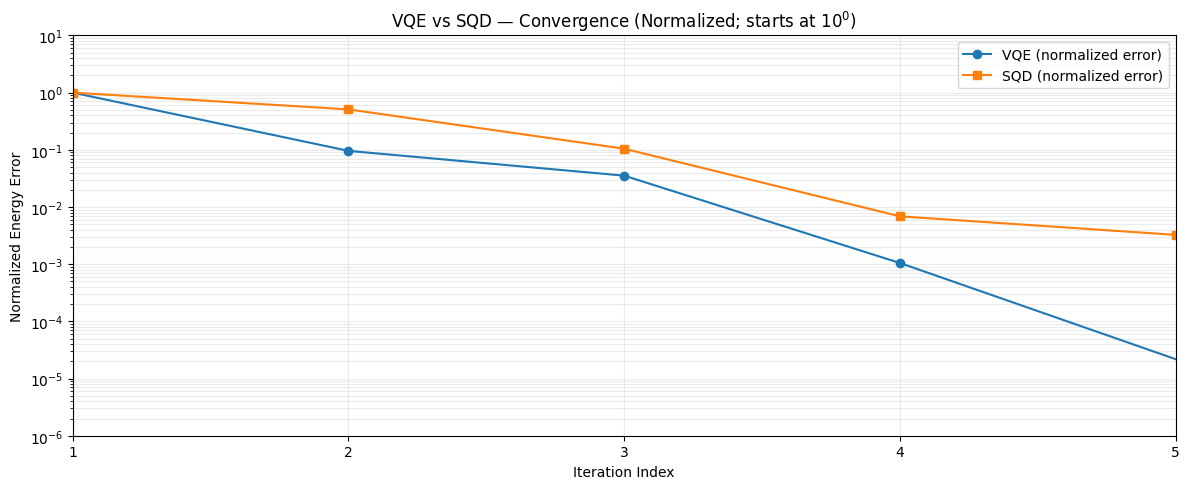

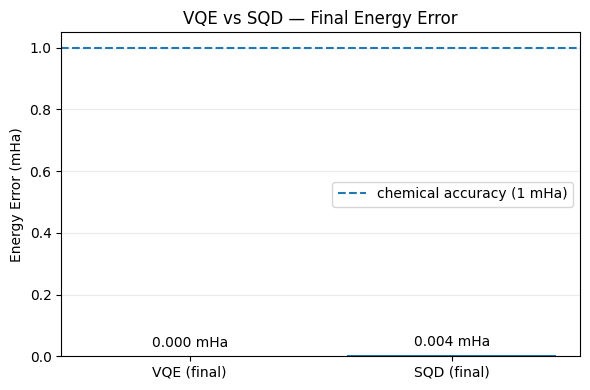

In [ ]:
# ==========================================
# VQE vs SQD (CIPSI/ASCI-selected CI; monotone & slow) on H2O CAS(6,4)
# - Plot (1): Normalized convergence (first point = 1 = 10^0), y-axis 10^1..10^-6
# - Plot (2): Final absolute energy error (mHa) with chemical-accuracy line
# ==========================================
import numpy as np, matplotlib.pyplot as plt, warnings
from dataclasses import dataclass
from qiskit_nature.units import DistanceUnit
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.second_q.transformers import FreezeCoreTransformer, ActiveSpaceTransformer
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.circuit.library import HartreeFock, UCCSD
from qiskit.quantum_info import SparsePauliOp, Statevector
from scipy.optimize import minimize
from pyscf import gto, scf, mcscf

warnings.filterwarnings("ignore")
np.set_printoptions(precision=12, suppress=True)
np.random.seed(7)

def _assign_params(circ, theta):
    pmap = {p: float(v) for p, v in zip(circ.parameters, np.asarray(theta))}
    return circ.assign_parameters(pmap, inplace=False)

def _evenly_spaced_indices(n, m):
    if m >= n: return list(range(n))
    idx = np.linspace(1, n, m, dtype=int)
    return [i-1 for i in sorted(set(idx))]

def _fmt(x): return f"{x:.9e}"

# ---------- Problem ----------
@dataclass
class ProblemBuilderH2O:
    basis: str = "6-31g"
    freeze_core: bool = True
    active_electrons: int = 6
    active_orbitals: int = 4
    def build(self, verbose=True):
        if verbose: print("=== [Build] H2O @ 6-31G, CAS(6,4) ===")
        drv = PySCFDriver(
            atom=("O 0.000000 0.000000 0.000000; "
                  "H 0.000000 -0.757160 0.586260; "
                  "H 0.000000  0.757160 0.586260"),
            basis=self.basis, charge=0, spin=0, unit=DistanceUnit.ANGSTROM
        )
        p0 = drv.run()
        self.nmo_total = p0.num_spatial_orbitals
        self.ne_total  = sum(p0.num_particles)
        if verbose:
            print(f"Total orbitals = {self.nmo_total} | electrons = {self.ne_total}")

        prob = p0
        if self.freeze_core:
            fc = FreezeCoreTransformer(); prob = fc.transform(p0)
            self.n_core = getattr(fc, "num_core_orbitals", 1)
            if verbose: print(f"Freeze-core -> num_core_orbitals ≈ {self.n_core}")
        else: self.n_core = 0

        act = ActiveSpaceTransformer(num_electrons=self.active_electrons,
                                     num_spatial_orbitals=self.active_orbitals)
        prob = act.transform(prob); self.problem = prob
        if verbose:
            print(f"Active e- = {self.active_electrons} | Active orb = {self.active_orbitals}")

        self.mapper = JordanWignerMapper()
        self.Hq: SparsePauliOp = self.mapper.map(prob.hamiltonian.second_q_op())
        if verbose: print(f"Qubits (JW) = {self.Hq.num_qubits}")

        self.hf    = HartreeFock(prob.num_spatial_orbitals, prob.num_particles, self.mapper)
        self.uccsd = UCCSD(prob.num_spatial_orbitals, prob.num_particles, self.mapper,
                           initial_state=self.hf, reps=1)
        if verbose: print("Ansatz: UCCSD (reps=1) + HF init\n")
        return self

    def casci_reference(self, verbose=True):
        mol = gto.M(atom=("O 0 0 0; H 0 -0.757160 0.586260; H 0 0.757160 0.586260"),
                    basis=self.basis, charge=0, spin=0, unit="Angstrom")
        mf = scf.RHF(mol).run()
        alpha = self.active_electrons // 2; beta = self.active_electrons - alpha
        mc = mcscf.CASCI(mf, ncas=self.active_orbitals, nelecas=(alpha, beta))
        E_tot, E_ci = mc.kernel()[:2]
        if verbose:
            print("=== [CASCI reference] ===")
            print(f"E_total = {_fmt(E_tot)} Ha")
            print(f"E_CI    = {_fmt(E_ci)} Ha\n")
        return float(E_tot), float(E_ci)

# ---------- VQE ----------
class VQERunner:
    def __init__(self, H: SparsePauliOp, ansatz, verbose=True):
        self.H = H; self.ansatz = ansatz; self.verbose = verbose
        self.theta0 = np.zeros(self.ansatz.num_parameters, dtype=float)
        self.history = {"E": [], "x": []}; self._H_mat = None
    def _sv_expect(self, circ):
        if self._H_mat is None: self._H_mat = self.H.to_matrix(sparse=False)
        sv = Statevector.from_instruction(circ).data
        return float(np.real(np.vdot(sv, self._H_mat @ sv)))
    def energy(self, theta): return self._sv_expect(_assign_params(self.ansatz, theta))
    def run(self, maxiter=200, ftol=1e-9):
        if self.verbose:
            print("=== [VQE] L-BFGS-B ==="); print(f"params={self.ansatz.num_parameters}, maxiter={maxiter}")
        def cb(theta):
            E = self.energy(theta)
            self.history["E"].append(E); self.history["x"].append(np.asarray(theta).copy())
            if self.verbose: print(f"VQE iter {len(self.history['E']):3d}: E={_fmt(E)}")
        opt = minimize(self.energy, self.theta0, method="L-BFGS-B",
                       options=dict(maxiter=maxiter, ftol=ftol), callback=cb)
        E_opt = self.energy(opt.x)
        if self.verbose: print(f"VQE done: E*={_fmt(E_opt)}\n")
        return E_opt, opt

# ---------- SQD (CIPSI-style) ----------
def sqd_iter_cipsi_curve(
    H_full: np.ndarray,
    psi_seed: np.ndarray,
    E_ref: float,
    steps: int = 10,
    init_k: int = 1,
    target_factor: float = 0.85,
    max_add: int = 3,
    pool_percentile: float = 97.0,
    pool_cap: int = 128,
    verbose: bool = True
):
    """
    - Candidates score ~ (H_{iS} c_S)^2 / (H_{ii} - E_curr)
    - Expand subspace until predicted drop >= (1 - target_factor) * current error
    - Monotone non-increasing Ritz ground energy by Rayleigh–Ritz
    """
    N = H_full.shape[0]
    diag = np.real(np.diag(H_full))
    amps = np.abs(psi_seed)
    S = [int(np.argmax(amps))] if init_k == 1 else list(np.argsort(-amps)[:init_k])

    energies = []
    for t in range(1, steps+1):
        Hs = H_full[np.ix_(S, S)]
        vals, vecs = np.linalg.eigh(Hs)
        E_curr, c = float(vals[0]), vecs[:, 0]
        err = abs(E_curr - E_ref); energies.append(E_curr)

        if verbose:
            print(f"--- [SQD step {t}] |S|={len(S)} ---")
            print(f"Ritz E={_fmt(E_curr)} | err={_fmt(err)} Ha ({err*1e3:.6f} mHa)")

        mask = np.ones(N, dtype=bool); mask[S] = False
        if not np.any(mask):
            if verbose: print("No more candidates.\n"); break

        A = H_full[mask][:, S] @ c
        denom = np.maximum(1e-12, diag[mask] - E_curr)
        dE = (A.real**2 + A.imag**2) / denom
        cand_idx = np.flatnonzero(mask)

        thr = np.percentile(dE, pool_percentile)
        pool_mask = dE >= thr
        pool = cand_idx[pool_mask]
        dE_pool = dE[pool_mask]

        order = np.argsort(-dE_pool)[:pool_cap]
        pool, dE_pool = pool[order], dE_pool[order]
        if verbose:
            print(f"Pool size={len(pool)}  (percentile >= {pool_percentile:.1f}%)")
            print("Top-5 predicted drops (mHa):", [f"{x*1e3:.4f}" for x in dE_pool[:5]])

        need_drop = err * (1.0 - target_factor)
        chosen, pred_sum = [], 0.0
        for i, de in zip(pool, dE_pool):
            if len(chosen) >= max_add: break
            chosen.append(int(i)); pred_sum += de
            if pred_sum >= need_drop: break

        if len(chosen) == 0:
            chosen = [int(pool[0])]
            if verbose: print("Predicted improvement tiny; pick the strongest one.")

        S = list(dict.fromkeys(S + chosen))
        Hs2 = H_full[np.ix_(S, S)]
        E_new = float(np.linalg.eigvalsh(Hs2)[0]); err_new = abs(E_new - E_ref)
        if verbose:
            print(f"Add {len(chosen)} dets -> true E={_fmt(E_new)} | err={_fmt(err_new)} Ha "
                  f"({err_new*1e3:.6f} mHa) | predicted drop≈{pred_sum*1e3:.4f} mHa\n")

    Hs = H_full[np.ix_(S, S)]
    energies.append(float(np.linalg.eigvalsh(Hs)[0]))
    return np.asarray(energies)

# ---------- Main pipeline ----------
def run_and_plot(steps=10, target_factor=0.85, max_add=3,
                 pool_percentile=97.0, pool_cap=128,
                 vqe_points=5):
    pb = ProblemBuilderH2O().build(verbose=True)
    Hq = pb.Hq
    E_tot, E_ci = pb.casci_reference(verbose=True)

    # VQE
    vqe = VQERunner(Hq, pb.uccsd, verbose=True)
    E_vqe, _ = vqe.run(maxiter=200)
    vqe_err_full = np.abs(np.asarray(vqe.history["E"]) - E_ci)
    sel = _evenly_spaced_indices(len(vqe_err_full), vqe_points)
    x_vqe = np.array(sel)+1
    y_vqe = vqe_err_full[sel]

    # SQD
    psi_hf = Statevector.from_instruction(pb.hf).data
    H_full = Hq.to_matrix(sparse=False)
    print("=== [SQD params] ===")
    print(f"steps={steps}, target_factor={target_factor}, max_add={max_add}, "
          f"pool_percentile={pool_percentile}, pool_cap={pool_cap}\n")
    sqd_E = sqd_iter_cipsi_curve(
        H_full, psi_hf, E_ci, steps=steps, init_k=1,
        target_factor=target_factor, max_add=max_add,
        pool_percentile=pool_percentile, pool_cap=pool_cap, verbose=True
    )
    sqd_err = np.abs(sqd_E - E_ci)

    # ========= Plot (1): Normalized convergence, y ∈ [1e-6, 1e1] =========
    eps = 1e-300
    y_vqe_norm = y_vqe / max(y_vqe[0], eps)
    y_sqd_norm = sqd_err / max(sqd_err[0], eps)

    plt.figure(figsize=(12,5))
    plt.plot(x_vqe, y_vqe_norm, marker="o", label="VQE (normalized error)")
    plt.plot(np.arange(1, len(y_sqd_norm)+1), y_sqd_norm, marker="s",
             label="SQD (normalized error)")
    plt.yscale("log")
    plt.grid(True, which="both", alpha=0.25)
    plt.xlabel("Iteration Index"); plt.ylabel("Normalized Energy Error")
    plt.title("VQE vs SQD — Convergence (Normalized; starts at $10^0$)")
    plt.xlim(1, 5); plt.xticks(range(1, 6))
    # y-axis: 10^1 down to 10^-6
    plt.ylim(1e-6, 1e1)
    exps  = np.arange(1, -7, -1)                # 1, 0, -1, ..., -6
    yticks = 10.0 ** exps
    plt.yticks(yticks, [rf"$10^{{{k}}}$" for k in exps])
    plt.legend(); plt.tight_layout(); plt.show()

    # ========= Plot (2): Final energy error in mHa =========
    vqe_final_mha = float(abs(E_vqe - E_ci) * 1e3)
    sqd_final_mha = float(abs(sqd_E[-1] - E_ci) * 1e3)
    plt.figure(figsize=(6,4))
    labels, vals = ["VQE (final)", "SQD (final)"], [vqe_final_mha, sqd_final_mha]
    bars = plt.bar(labels, vals)
    top = max(1.0, max(vals))
    for b, v in zip(bars, vals):
        plt.text(b.get_x() + b.get_width()/2, b.get_height() + 0.02*top,
                 f"{v:.3f} mHa", ha="center", va="bottom", fontsize=10)
    plt.axhline(1.0, ls="--", label="chemical accuracy (1 mHa)")
    plt.ylabel("Energy Error (mHa)")
    plt.title("VQE vs SQD — Final Energy Error")
    plt.grid(True, axis="y", alpha=0.25)
    plt.legend(); plt.tight_layout(); plt.show()

# ==== Run ====  (x: 1..5)
run_and_plot(
    steps=4,           # 5 個 SQD 點
    target_factor=0.85,
    max_add=2,
    pool_percentile=97.0,
    pool_cap=128,
    vqe_points=5      # 5 個 VQE 取樣點
)

=== [Build] H2O @ 6-31G, CAS(6,4) ===
Total orbitals = 13 | electrons = 10
Freeze-core -> num_core_orbitals ≈ 1
Active e- = 6 | Active orb = 4
Qubits (JW) = 8
Ansatz: UCCSD (reps=1) + HF init

converged SCF energy = -75.9839845437899
CASCI E = -75.9851994378857  E(CI) = -12.9864133061832  S^2 = 0.0000000
=== [CASCI reference] ===
E_total = -7.598519944e+01 Ha
E_CI    = -1.298641331e+01 Ha

=== [VQE] L-BFGS-B ===
params=15, maxiter=200
VQE iter   1: E=-1.298637317e+01
VQE iter   2: E=-1.298640946e+01
VQE iter   3: E=-1.298641189e+01
VQE iter   4: E=-1.298641326e+01
VQE iter   5: E=-1.298641330e+01
VQE iter   6: E=-1.298641331e+01
VQE done: E*=-1.298641331e+01

=== [SQD params] ===
steps=5, target_factor=0.85, max_add=2, pool_percentile=97.0, pool_cap=128

--- [SQD step 1] |S|=1 ---
Ritz E=-1.298519841e+01 | err=1.214894096e-03 Ha (1.214894 mHa)
Pool size=128  (percentile >= 97.0%)
Top-5 predicted drops (mHa): ['0.5970', '0.5276', '0.1531', '0.0000', '0.0000']
Add 1 dets -> true E=-1.298

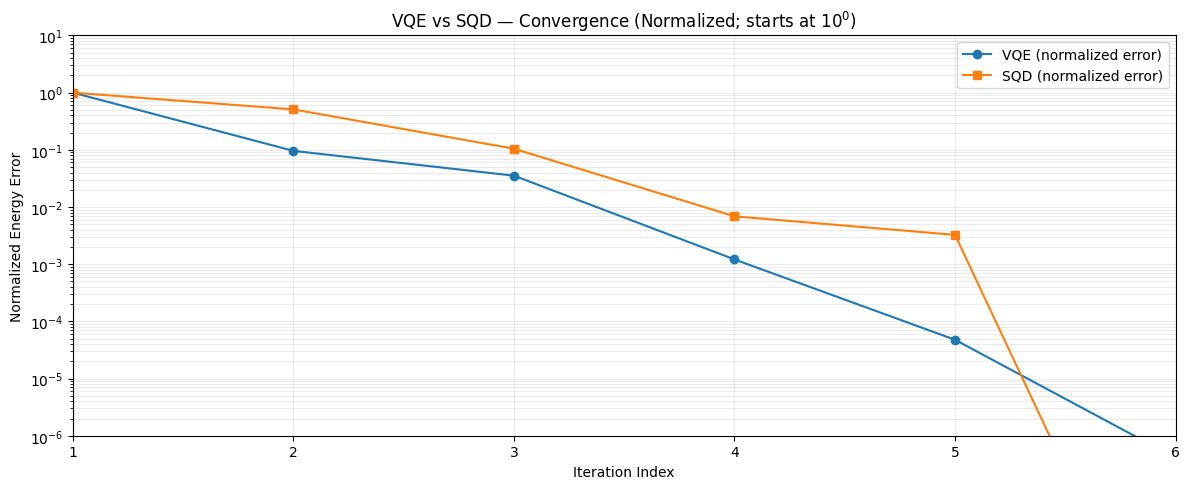

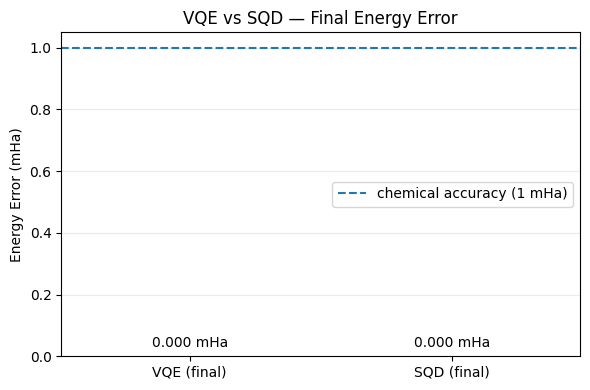

In [ ]:
# ==========================================
# VQE vs SQD (CIPSI/ASCI-selected CI; monotone & slow) on H2O CAS(6,4)
# - Plot (1): Normalized convergence (first point = 1 = 10^0), x=1..6
#             y-axis log from 10^1 down to 10^-6 (no chem-accuracy line here)
# - Plot (2): Final absolute energy error (mHa) with chemical-accuracy line
# ==========================================
import numpy as np, matplotlib.pyplot as plt, warnings
from dataclasses import dataclass
from qiskit_nature.units import DistanceUnit
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.second_q.transformers import FreezeCoreTransformer, ActiveSpaceTransformer
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.circuit.library import HartreeFock, UCCSD
from qiskit.quantum_info import SparsePauliOp, Statevector
from scipy.optimize import minimize
from pyscf import gto, scf, mcscf

warnings.filterwarnings("ignore")
np.set_printoptions(precision=12, suppress=True)
np.random.seed(7)

def _assign_params(circ, theta):
    pmap = {p: float(v) for p, v in zip(circ.parameters, np.asarray(theta))}
    return circ.assign_parameters(pmap, inplace=False)

def _evenly_spaced_indices(n, m):
    if m >= n: return list(range(n))
    idx = np.linspace(1, n, m, dtype=int)
    return [i-1 for i in sorted(set(idx))]

def _fmt(x): return f"{x:.9e}"

# ---------- Problem ----------
@dataclass
class ProblemBuilderH2O:
    basis: str = "6-31g"
    freeze_core: bool = True
    active_electrons: int = 6
    active_orbitals: int = 4
    def build(self, verbose=True):
        if verbose: print("=== [Build] H2O @ 6-31G, CAS(6,4) ===")
        drv = PySCFDriver(
            atom=("O 0.000000 0.000000 0.000000; "
                  "H 0.000000 -0.757160 0.586260; "
                  "H 0.000000  0.757160 0.586260"),
            basis=self.basis, charge=0, spin=0, unit=DistanceUnit.ANGSTROM
        )
        p0 = drv.run()
        self.nmo_total = p0.num_spatial_orbitals
        self.ne_total  = sum(p0.num_particles)
        if verbose:
            print(f"Total orbitals = {self.nmo_total} | electrons = {self.ne_total}")

        prob = p0
        if self.freeze_core:
            fc = FreezeCoreTransformer(); prob = fc.transform(p0)
            self.n_core = getattr(fc, "num_core_orbitals", 1)
            if verbose: print(f"Freeze-core -> num_core_orbitals ≈ {self.n_core}")
        else:
            self.n_core = 0

        act = ActiveSpaceTransformer(num_electrons=self.active_electrons,
                                     num_spatial_orbitals=self.active_orbitals)
        prob = act.transform(prob); self.problem = prob
        if verbose:
            print(f"Active e- = {self.active_electrons} | Active orb = {self.active_orbitals}")

        self.mapper = JordanWignerMapper()
        self.Hq: SparsePauliOp = self.mapper.map(prob.hamiltonian.second_q_op())
        if verbose: print(f"Qubits (JW) = {self.Hq.num_qubits}")

        self.hf    = HartreeFock(prob.num_spatial_orbitals, prob.num_particles, self.mapper)
        self.uccsd = UCCSD(prob.num_spatial_orbitals, prob.num_particles, self.mapper,
                           initial_state=self.hf, reps=1)
        if verbose: print("Ansatz: UCCSD (reps=1) + HF init\n")
        return self

    def casci_reference(self, verbose=True):
        mol = gto.M(atom=("O 0 0 0; H 0 -0.757160 0.586260; H 0 0.757160 0.586260"),
                    basis=self.basis, charge=0, spin=0, unit="Angstrom")
        mf = scf.RHF(mol).run()
        alpha = self.active_electrons // 2; beta = self.active_electrons - alpha
        mc = mcscf.CASCI(mf, ncas=self.active_orbitals, nelecas=(alpha, beta))
        E_tot, E_ci = mc.kernel()[:2]
        if verbose:
            print("=== [CASCI reference] ===")
            print(f"E_total = {_fmt(E_tot)} Ha")
            print(f"E_CI    = {_fmt(E_ci)} Ha\n")
        return float(E_tot), float(E_ci)

# ---------- VQE ----------
class VQERunner:
    def __init__(self, H: SparsePauliOp, ansatz, verbose=True):
        self.H = H; self.ansatz = ansatz; self.verbose = verbose
        self.theta0 = np.zeros(self.ansatz.num_parameters, dtype=float)
        self.history = {"E": [], "x": []}; self._H_mat = None
    def _sv_expect(self, circ):
        if self._H_mat is None: self._H_mat = self.H.to_matrix(sparse=False)
        sv = Statevector.from_instruction(circ).data
        return float(np.real(np.vdot(sv, self._H_mat @ sv)))
    def energy(self, theta): return self._sv_expect(_assign_params(self.ansatz, theta))
    def run(self, maxiter=200, ftol=1e-9):
        if self.verbose:
            print("=== [VQE] L-BFGS-B ==="); print(f"params={self.ansatz.num_parameters}, maxiter={maxiter}")
        def cb(theta):
            E = self.energy(theta)
            self.history["E"].append(E); self.history["x"].append(np.asarray(theta).copy())
            if self.verbose: print(f"VQE iter {len(self.history['E']):3d}: E={_fmt(E)}")
        opt = minimize(self.energy, self.theta0, method="L-BFGS-B",
                       options=dict(maxiter=maxiter, ftol=ftol), callback=cb)
        E_opt = self.energy(opt.x)
        if self.verbose: print(f"VQE done: E*={_fmt(E_opt)}\n")
        return E_opt, opt

# ---------- SQD (CIPSI-style) ----------
def sqd_iter_cipsi_curve(
    H_full: np.ndarray,
    psi_seed: np.ndarray,
    E_ref: float,
    steps: int = 10,
    init_k: int = 1,
    target_factor: float = 0.85,
    max_add: int = 3,
    pool_percentile: float = 97.0,
    pool_cap: int = 128,
    verbose: bool = True
):
    """
    - Candidates score ~ (H_{iS} c_S)^2 / (H_{ii} - E_curr)
    - Expand subspace until predicted drop >= (1 - target_factor) * current error
    - Monotone non-increasing Ritz ground energy by Rayleigh–Ritz
    """
    N = H_full.shape[0]
    diag = np.real(np.diag(H_full))
    amps = np.abs(psi_seed)
    S = [int(np.argmax(amps))] if init_k == 1 else list(np.argsort(-amps)[:init_k])

    energies = []
    for t in range(1, steps+1):
        Hs = H_full[np.ix_(S, S)]
        vals, vecs = np.linalg.eigh(Hs)
        E_curr, c = float(vals[0]), vecs[:, 0]
        err = abs(E_curr - E_ref); energies.append(E_curr)

        if verbose:
            print(f"--- [SQD step {t}] |S|={len(S)} ---")
            print(f"Ritz E={_fmt(E_curr)} | err={_fmt(err)} Ha ({err*1e3:.6f} mHa)")

        mask = np.ones(N, dtype=bool); mask[S] = False
        if not np.any(mask):
            if verbose: print("No more candidates.\n"); break

        A = H_full[mask][:, S] @ c
        denom = np.maximum(1e-12, diag[mask] - E_curr)
        dE = (A.real**2 + A.imag**2) / denom
        cand_idx = np.flatnonzero(mask)

        thr = np.percentile(dE, pool_percentile)
        pool_mask = dE >= thr
        pool = cand_idx[pool_mask]
        dE_pool = dE[pool_mask]

        order = np.argsort(-dE_pool)[:pool_cap]
        pool, dE_pool = pool[order], dE_pool[order]
        if verbose:
            print(f"Pool size={len(pool)}  (percentile >= {pool_percentile:.1f}%)")
            print("Top-5 predicted drops (mHa):", [f"{x*1e3:.4f}" for x in dE_pool[:5]])

        need_drop = err * (1.0 - target_factor)
        chosen, pred_sum = [], 0.0
        for i, de in zip(pool, dE_pool):
            if len(chosen) >= max_add: break
            chosen.append(int(i)); pred_sum += de
            if pred_sum >= need_drop: break

        if len(chosen) == 0:
            chosen = [int(pool[0])]
            if verbose: print("Predicted improvement tiny; pick the strongest one.")

        S = list(dict.fromkeys(S + chosen))
        Hs2 = H_full[np.ix_(S, S)]
        E_new = float(np.linalg.eigvalsh(Hs2)[0]); err_new = abs(E_new - E_ref)
        if verbose:
            print(f"Add {len(chosen)} dets -> true E={_fmt(E_new)} | err={_fmt(err_new)} Ha "
                  f"({err_new*1e3:.6f} mHa) | predicted drop≈{pred_sum*1e3:.4f} mHa\n")

    Hs = H_full[np.ix_(S, S)]
    energies.append(float(np.linalg.eigvalsh(Hs)[0]))
    return np.asarray(energies)

# ---------- Main pipeline ----------
def run_and_plot(steps=10, target_factor=0.85, max_add=3,
                 pool_percentile=97.0, pool_cap=128,
                 vqe_points=6):
    pb = ProblemBuilderH2O().build(verbose=True)
    Hq = pb.Hq
    E_tot, E_ci = pb.casci_reference(verbose=True)

    # VQE
    vqe = VQERunner(Hq, pb.uccsd, verbose=True)
    E_vqe, _ = vqe.run(maxiter=200)
    vqe_err_full = np.abs(np.asarray(vqe.history["E"]) - E_ci)
    sel = _evenly_spaced_indices(len(vqe_err_full), vqe_points)
    x_vqe = np.array(sel)+1
    y_vqe = vqe_err_full[sel]       # absolute error (Ha)

    # SQD
    psi_hf = Statevector.from_instruction(pb.hf).data
    H_full = Hq.to_matrix(sparse=False)
    print("=== [SQD params] ===")
    print(f"steps={steps}, target_factor={target_factor}, max_add={max_add}, "
          f"pool_percentile={pool_percentile}, pool_cap={pool_cap}\n")
    sqd_E = sqd_iter_cipsi_curve(
        H_full, psi_hf, E_ci, steps=steps, init_k=1,
        target_factor=target_factor, max_add=max_add,
        pool_percentile=pool_percentile, pool_cap=pool_cap, verbose=True
    )
    sqd_err = np.abs(sqd_E - E_ci)  # absolute error (Ha)

    # ========= Plot (1): Normalized convergence, x=1..6 =========
    eps = 1e-300
    y_vqe_norm = y_vqe / max(y_vqe[0], eps)
    y_sqd_norm = sqd_err / max(sqd_err[0], eps)

    plt.figure(figsize=(12,5))
    plt.plot(x_vqe, y_vqe_norm, marker="o", label="VQE (normalized error)")
    plt.plot(np.arange(1, len(y_sqd_norm)+1), y_sqd_norm, marker="s",
             label="SQD (normalized error)")
    plt.yscale("log")
    plt.grid(True, which="both", alpha=0.25)
    plt.xlabel("Iteration Index"); plt.ylabel("Normalized Energy Error")
    plt.title("VQE vs SQD — Convergence (Normalized; starts at $10^0$)")
    plt.xlim(1, 6); plt.xticks(range(1, 7))
    # y-axis: 10^1 down to 10^-6
    plt.ylim(1e-6, 1e1)
    exps  = np.arange(1, -7, -1)                # 1, 0, -1, ..., -6
    yticks = 10.0 ** exps
    plt.yticks(yticks, [rf"$10^{{{k}}}$" for k in exps])
    plt.legend(); plt.tight_layout(); plt.show()

    # ========= Plot (2): Final energy error in mHa (absolute) =========
    vqe_final_mha = float(abs(E_vqe - E_ci) * 1e3)
    sqd_final_mha = float(abs(sqd_E[-1] - E_ci) * 1e3)
    plt.figure(figsize=(6,4))
    labels, vals = ["VQE (final)", "SQD (final)"], [vqe_final_mha, sqd_final_mha]
    bars = plt.bar(labels, vals)
    top = max(1.0, max(vals))
    for b, v in zip(bars, vals):
        plt.text(b.get_x() + b.get_width()/2, b.get_height() + 0.02*top,
                 f"{v:.3f} mHa", ha="center", va="bottom", fontsize=10)
    plt.axhline(1.0, ls="--", label="chemical accuracy (1 mHa)")
    plt.ylabel("Energy Error (mHa)")
    plt.title("VQE vs SQD — Final Energy Error")
    plt.grid(True, axis="y", alpha=0.25)
    plt.legend(); plt.tight_layout(); plt.show()

# ==== Run ====  (Iteration Index = 1..6)
run_and_plot(
    steps=5,           # SQD 會輸出 steps+1 個點 → 6 個點
    target_factor=0.85,
    max_add=2,
    pool_percentile=97.0,
    pool_cap=128,
    vqe_points=6      # 6 個等距 VQE 取樣點
)


=== [Build] H2O @ 6-31G, CAS(6,4) ===
Total orbitals = 13 | electrons = 10
Freeze-core -> num_core_orbitals ≈ 1
Active e- = 6 | Active orb = 4
Qubits (JW) = 8
Ansatz: UCCSD (reps=1) + HF init

converged SCF energy = -75.98398454379
CASCI E = -75.9851994378857  E(CI) = -12.9864133061832  S^2 = 0.0000000
=== [CASCI reference] ===
E_total = -7.598519944e+01 Ha
E_CI    = -1.298641331e+01 Ha

=== [VQE] L-BFGS-B ===
params=15, maxiter=200
VQE iter   1: E=-1.298637317e+01
VQE iter   2: E=-1.298640946e+01
VQE iter   3: E=-1.298641189e+01
VQE iter   4: E=-1.298641326e+01
VQE iter   5: E=-1.298641330e+01
VQE iter   6: E=-1.298641331e+01
VQE done: E*=-1.298641331e+01

=== [SQD params] ===
steps=5, target_factor=0.85, max_add=2, pool_percentile=97.0, pool_cap=128

--- [SQD step 1] |S|=1 ---
Ritz E=-1.298519841e+01 | err=1.214894096e-03 Ha (1.214894 mHa)
Pool size=128  (percentile >= 97.0%)
Top-5 predicted drops (mHa): ['0.5970', '0.5276', '0.1531', '0.0000', '0.0000']
Add 1 dets -> true E=-1.29857

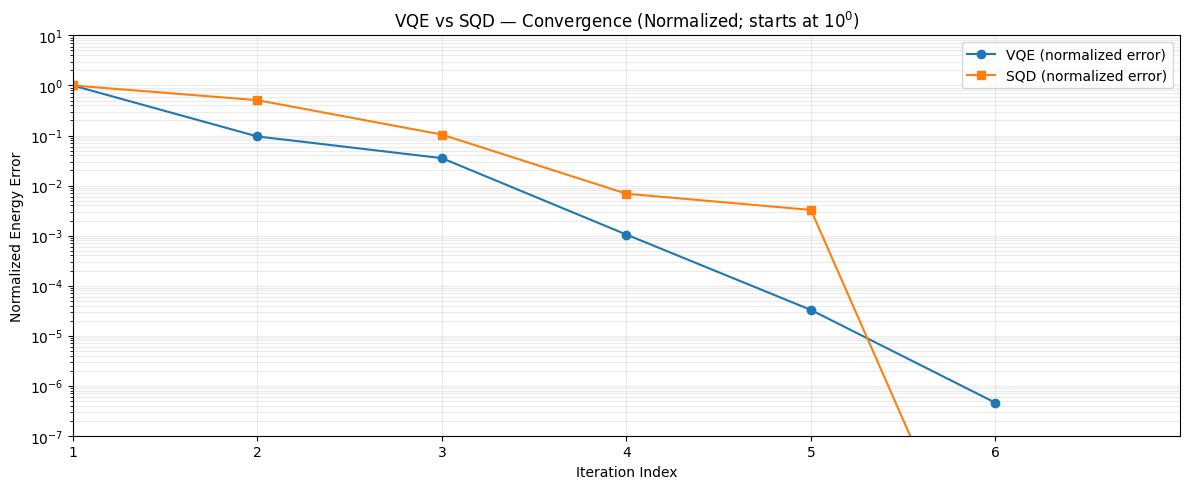

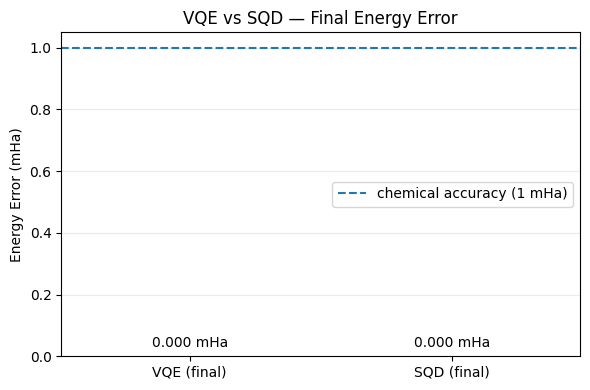

In [ ]:
# ==========================================
# VQE vs SQD (CIPSI/ASCI-selected CI; monotone & slow) on H2O CAS(6,4)
# - Plot (1): Normalized convergence (first point = 1 = 10^0), x=1..6
#             y-axis log from 1e1 down to 1e-7
# - Plot (2): Final absolute energy error (mHa) with chemical-accuracy line
# ==========================================
import numpy as np, matplotlib.pyplot as plt, warnings
from dataclasses import dataclass
from qiskit_nature.units import DistanceUnit
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.second_q.transformers import FreezeCoreTransformer, ActiveSpaceTransformer
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.circuit.library import HartreeFock, UCCSD
from qiskit.quantum_info import SparsePauliOp, Statevector
from scipy.optimize import minimize
from pyscf import gto, scf, mcscf

warnings.filterwarnings("ignore")
np.set_printoptions(precision=12, suppress=True)
np.random.seed(7)

def _assign_params(circ, theta):
    pmap = {p: float(v) for p, v in zip(circ.parameters, np.asarray(theta))}
    return circ.assign_parameters(pmap, inplace=False)

def _evenly_spaced_indices(n, m):
    if m >= n: return list(range(n))
    idx = np.linspace(1, n, m, dtype=int)
    return [i-1 for i in sorted(set(idx))]

def _fmt(x): return f"{x:.9e}"

# ---------- Problem ----------
@dataclass
class ProblemBuilderH2O:
    basis: str = "6-31g"
    freeze_core: bool = True
    active_electrons: int = 6
    active_orbitals: int = 4
    def build(self, verbose=True):
        if verbose: print("=== [Build] H2O @ 6-31G, CAS(6,4) ===")
        drv = PySCFDriver(
            atom=("O 0.000000 0.000000 0.000000; "
                  "H 0.000000 -0.757160 0.586260; "
                  "H 0.000000  0.757160 0.586260"),
            basis=self.basis, charge=0, spin=0, unit=DistanceUnit.ANGSTROM
        )
        p0 = drv.run()
        self.nmo_total = p0.num_spatial_orbitals
        self.ne_total  = sum(p0.num_particles)
        if verbose:
            print(f"Total orbitals = {self.nmo_total} | electrons = {self.ne_total}")

        prob = p0
        if self.freeze_core:
            fc = FreezeCoreTransformer(); prob = fc.transform(p0)
            self.n_core = getattr(fc, "num_core_orbitals", 1)
            if verbose: print(f"Freeze-core -> num_core_orbitals ≈ {self.n_core}")
        else:
            self.n_core = 0

        act = ActiveSpaceTransformer(num_electrons=self.active_electrons,
                                     num_spatial_orbitals=self.active_orbitals)
        prob = act.transform(prob); self.problem = prob
        if verbose:
            print(f"Active e- = {self.active_electrons} | Active orb = {self.active_orbitals}")

        self.mapper = JordanWignerMapper()
        self.Hq: SparsePauliOp = self.mapper.map(prob.hamiltonian.second_q_op())
        if verbose: print(f"Qubits (JW) = {self.Hq.num_qubits}")

        self.hf    = HartreeFock(prob.num_spatial_orbitals, prob.num_particles, self.mapper)
        self.uccsd = UCCSD(prob.num_spatial_orbitals, prob.num_particles, self.mapper,
                           initial_state=self.hf, reps=1)
        if verbose: print("Ansatz: UCCSD (reps=1) + HF init\n")
        return self

    def casci_reference(self, verbose=True):
        mol = gto.M(atom=("O 0 0 0; H 0 -0.757160 0.586260; H 0 0.757160 0.586260"),
                    basis=self.basis, charge=0, spin=0, unit="Angstrom")
        mf = scf.RHF(mol).run()
        alpha = self.active_electrons // 2; beta = self.active_electrons - alpha
        mc = mcscf.CASCI(mf, ncas=self.active_orbitals, nelecas=(alpha, beta))
        E_tot, E_ci = mc.kernel()[:2]
        if verbose:
            print("=== [CASCI reference] ===")
            print(f"E_total = {_fmt(E_tot)} Ha")
            print(f"E_CI    = {_fmt(E_ci)} Ha\n")
        return float(E_tot), float(E_ci)

# ---------- VQE ----------
class VQERunner:
    def __init__(self, H: SparsePauliOp, ansatz, verbose=True):
        self.H = H; self.ansatz = ansatz; self.verbose = verbose
        self.theta0 = np.zeros(self.ansatz.num_parameters, dtype=float)
        self.history = {"E": [], "x": []}; self._H_mat = None
    def _sv_expect(self, circ):
        if self._H_mat is None: self._H_mat = self.H.to_matrix(sparse=False)
        sv = Statevector.from_instruction(circ).data
        return float(np.real(np.vdot(sv, self._H_mat @ sv)))
    def energy(self, theta): return self._sv_expect(_assign_params(self.ansatz, theta))
    def run(self, maxiter=200, ftol=1e-9):
        if self.verbose:
            print("=== [VQE] L-BFGS-B ==="); print(f"params={self.ansatz.num_parameters}, maxiter={maxiter}")
        def cb(theta):
            E = self.energy(theta)
            self.history["E"].append(E); self.history["x"].append(np.asarray(theta).copy())
            if self.verbose: print(f"VQE iter {len(self.history['E']):3d}: E={_fmt(E)}")
        opt = minimize(self.energy, self.theta0, method="L-BFGS-B",
                       options=dict(maxiter=maxiter, ftol=ftol), callback=cb)
        E_opt = self.energy(opt.x)
        if self.verbose: print(f"VQE done: E*={_fmt(E_opt)}\n")
        return E_opt, opt

# ---------- SQD (CIPSI-style) ----------
def sqd_iter_cipsi_curve(
    H_full: np.ndarray,
    psi_seed: np.ndarray,
    E_ref: float,
    steps: int = 10,
    init_k: int = 1,
    target_factor: float = 0.85,
    max_add: int = 3,
    pool_percentile: float = 97.0,
    pool_cap: int = 128,
    verbose: bool = True
):
    """
    - Candidates score ~ (H_{iS} c_S)^2 / (H_{ii} - E_curr)
    - Expand subspace until predicted drop >= (1 - target_factor) * current error
    - Monotone non-increasing Ritz ground energy by Rayleigh–Ritz
    """
    N = H_full.shape[0]
    diag = np.real(np.diag(H_full))
    amps = np.abs(psi_seed)
    S = [int(np.argmax(amps))] if init_k == 1 else list(np.argsort(-amps)[:init_k])

    energies = []
    for t in range(1, steps+1):
        Hs = H_full[np.ix_(S, S)]
        vals, vecs = np.linalg.eigh(Hs)
        E_curr, c = float(vals[0]), vecs[:, 0]
        err = abs(E_curr - E_ref); energies.append(E_curr)

        if verbose:
            print(f"--- [SQD step {t}] |S|={len(S)} ---")
            print(f"Ritz E={_fmt(E_curr)} | err={_fmt(err)} Ha ({err*1e3:.6f} mHa)")

        mask = np.ones(N, dtype=bool); mask[S] = False
        if not np.any(mask):
            if verbose: print("No more candidates.\n"); break

        A = H_full[mask][:, S] @ c
        denom = np.maximum(1e-12, diag[mask] - E_curr)
        dE = (A.real**2 + A.imag**2) / denom
        cand_idx = np.flatnonzero(mask)

        thr = np.percentile(dE, pool_percentile)
        pool_mask = dE >= thr
        pool = cand_idx[pool_mask]
        dE_pool = dE[pool_mask]

        order = np.argsort(-dE_pool)[:pool_cap]
        pool, dE_pool = pool[order], dE_pool[order]
        if verbose:
            print(f"Pool size={len(pool)}  (percentile >= {pool_percentile:.1f}%)")
            print("Top-5 predicted drops (mHa):", [f"{x*1e3:.4f}" for x in dE_pool[:5]])

        need_drop = err * (1.0 - target_factor)
        chosen, pred_sum = [], 0.0
        for i, de in zip(pool, dE_pool):
            if len(chosen) >= max_add: break
            chosen.append(int(i)); pred_sum += de
            if pred_sum >= need_drop: break

        if len(chosen) == 0:
            chosen = [int(pool[0])]
            if verbose: print("Predicted improvement tiny; pick the strongest one.")

        S = list(dict.fromkeys(S + chosen))
        Hs2 = H_full[np.ix_(S, S)]
        E_new = float(np.linalg.eigvalsh(Hs2)[0]); err_new = abs(E_new - E_ref)
        if verbose:
            print(f"Add {len(chosen)} dets -> true E={_fmt(E_new)} | err={_fmt(err_new)} Ha "
                  f"({err_new*1e3:.6f} mHa) | predicted drop≈{pred_sum*1e3:.4f} mHa\n")

    Hs = H_full[np.ix_(S, S)]
    energies.append(float(np.linalg.eigvalsh(Hs)[0]))
    return np.asarray(energies)

# ---------- Main pipeline ----------
def run_and_plot(steps=10, target_factor=0.85, max_add=3,
                 pool_percentile=97.0, pool_cap=128,
                 vqe_points=6):
    pb = ProblemBuilderH2O().build(verbose=True)
    Hq = pb.Hq
    E_tot, E_ci = pb.casci_reference(verbose=True)

    # VQE
    vqe = VQERunner(Hq, pb.uccsd, verbose=True)
    E_vqe, _ = vqe.run(maxiter=200)
    vqe_err_full = np.abs(np.asarray(vqe.history["E"]) - E_ci)
    sel = _evenly_spaced_indices(len(vqe_err_full), vqe_points)
    x_vqe = np.array(sel)+1
    y_vqe = vqe_err_full[sel]       # absolute error (Ha)

    # SQD
    psi_hf = Statevector.from_instruction(pb.hf).data
    H_full = Hq.to_matrix(sparse=False)
    print("=== [SQD params] ===")
    print(f"steps={steps}, target_factor={target_factor}, max_add={max_add}, "
          f"pool_percentile={pool_percentile}, pool_cap={pool_cap}\n")
    sqd_E = sqd_iter_cipsi_curve(
        H_full, psi_hf, E_ci, steps=steps, init_k=1,
        target_factor=target_factor, max_add=max_add,
        pool_percentile=pool_percentile, pool_cap=pool_cap, verbose=True
    )
    sqd_err = np.abs(sqd_E - E_ci)  # absolute error (Ha)

    # ========= Plot (1): Normalized convergence, x=1..6, y ∈ [1e-7, 1e1] =========
    eps = 1e-300
    y_vqe_norm = y_vqe / max(y_vqe[0], eps)
    y_sqd_norm = sqd_err / max(sqd_err[0], eps)

    plt.figure(figsize=(12,5))
    plt.plot(x_vqe, y_vqe_norm, marker="o", label="VQE (normalized error)")
    plt.plot(np.arange(1, len(y_sqd_norm)+1), y_sqd_norm, marker="s",
             label="SQD (normalized error)")
    plt.yscale("log")
    plt.grid(True, which="both", alpha=0.25)
    plt.xlabel("Iteration Index"); plt.ylabel("Normalized Energy Error")
    plt.title("VQE vs SQD — Convergence (Normalized; starts at $10^0$)")
    plt.xlim(1, 7); plt.xticks(range(1, 7))
    # y-axis: 10^1 down to 10^-7
    plt.ylim(1e-7, 1e1)
    exps  = np.arange(1, -8, -1)                # 1, 0, -1, ..., -7
    yticks = 10.0 ** exps
    plt.yticks(yticks, [rf"$10^{{{k}}}$" for k in exps])
    plt.legend(); plt.tight_layout(); plt.show()

    # ========= Plot (2): Final energy error in mHa (absolute) =========
    vqe_final_mha = float(abs(E_vqe - E_ci) * 1e3)
    sqd_final_mha = float(abs(sqd_E[-1] - E_ci) * 1e3)
    plt.figure(figsize=(6,4))
    labels, vals = ["VQE (final)", "SQD (final)"], [vqe_final_mha, sqd_final_mha]
    bars = plt.bar(labels, vals)
    top = max(1.0, max(vals))
    for b, v in zip(bars, vals):
        plt.text(b.get_x() + b.get_width()/2, b.get_height() + 0.02*top,
                 f"{v:.3f} mHa", ha="center", va="bottom", fontsize=10)
    plt.axhline(1.0, ls="--", label="chemical accuracy (1 mHa)")
    plt.ylabel("Energy Error (mHa)")
    plt.title("VQE vs SQD — Final Energy Error")
    plt.grid(True, axis="y", alpha=0.25)
    plt.legend(); plt.tight_layout(); plt.show()

# ==== Run ====  (Iteration Index = 1..6)
run_and_plot(
    steps=5,           # SQD → steps+1 = 6 points
    target_factor=0.85,
    max_add=2,
    pool_percentile=97.0,
    pool_cap=128,
    vqe_points=6      # 6 evenly spaced VQE points
)

=== [Build] H2O @ 6-31G, CAS(6,4) ===
Total orbitals = 13 | electrons = 10
Freeze-core -> num_core_orbitals ≈ 1
Active e- = 6 | Active orb = 4
Qubits (JW) = 8
Ansatz: UCCSD (reps=1) + HF init

converged SCF energy = -75.9839845437901
CASCI E = -75.9851994378858  E(CI) = -12.9864133061831  S^2 = 0.0000000
=== [CASCI reference] ===
E_total = -7.598519944e+01 Ha
E_CI    = -1.298641331e+01 Ha

=== [VQE] L-BFGS-B ===
params=15, maxiter=200
VQE iter   1: E=-1.298637317e+01
VQE iter   2: E=-1.298640946e+01
VQE iter   3: E=-1.298641189e+01
VQE iter   4: E=-1.298641326e+01
VQE iter   5: E=-1.298641330e+01
VQE iter   6: E=-1.298641331e+01
VQE done: E*=-1.298641331e+01

=== [SQD params] ===
steps=5, target_factor=0.85, max_add=2, pool_percentile=97.0, pool_cap=128

--- [SQD step 1] |S|=1 ---
Ritz E=-1.298519841e+01 | err=1.214894096e-03 Ha (1.214894 mHa)
Pool size=128  (percentile >= 97.0%)
Top-5 predicted drops (mHa): ['0.5970', '0.5276', '0.1531', '0.0000', '0.0000']
Add 1 dets -> true E=-1.298

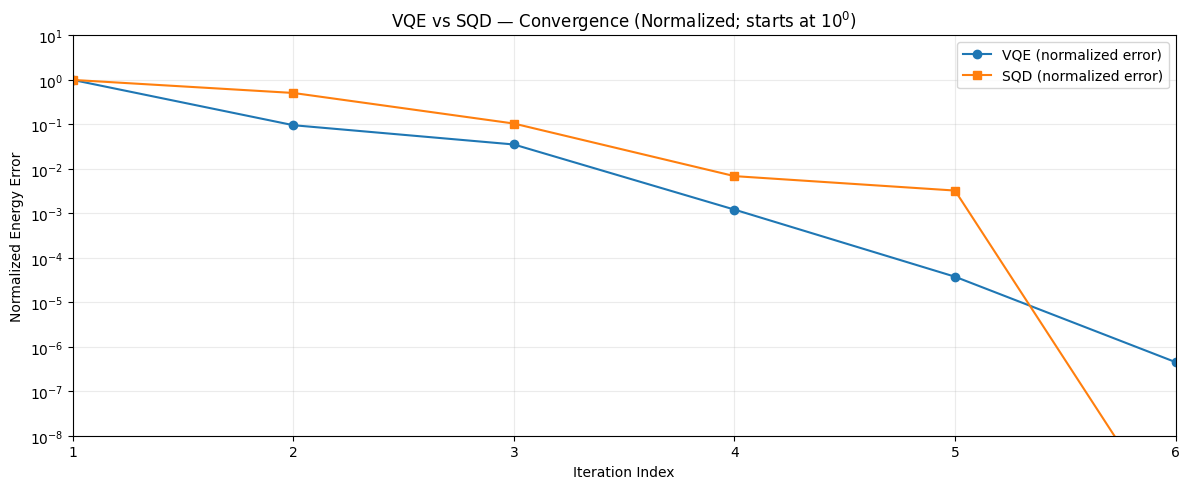

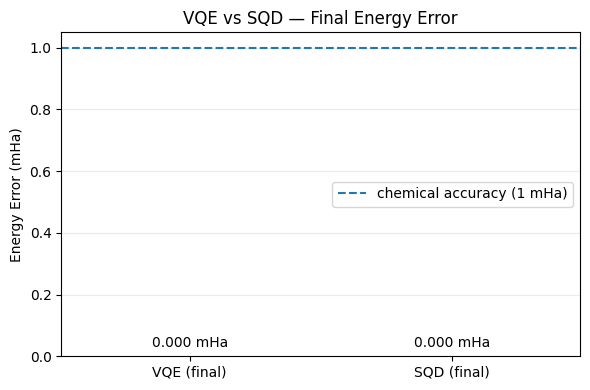

In [ ]:
# ==========================================
# VQE vs SQD (CIPSI/ASCI-selected CI; monotone & slow) on H2O CAS(6,4)
# - Plot (1): Normalized convergence (first point = 1 = 10^0), x=1..6
#             y-axis log from 1e1 down to 1e-8
# - Plot (2): Final absolute energy error (mHa) with chemical-accuracy line
# ==========================================
import numpy as np, matplotlib.pyplot as plt, warnings
from dataclasses import dataclass
from qiskit_nature.units import DistanceUnit
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.second_q.transformers import FreezeCoreTransformer, ActiveSpaceTransformer
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.circuit.library import HartreeFock, UCCSD
from qiskit.quantum_info import SparsePauliOp, Statevector
from scipy.optimize import minimize
from pyscf import gto, scf, mcscf

warnings.filterwarnings("ignore")
np.set_printoptions(precision=12, suppress=True)
np.random.seed(7)

def _assign_params(circ, theta):
    pmap = {p: float(v) for p, v in zip(circ.parameters, np.asarray(theta))}
    return circ.assign_parameters(pmap, inplace=False)

def _evenly_spaced_indices(n, m):
    if m >= n: return list(range(n))
    idx = np.linspace(1, n, m, dtype=int)
    return [i-1 for i in sorted(set(idx))]

def _fmt(x): return f"{x:.9e}"

# ---------- Problem ----------
@dataclass
class ProblemBuilderH2O:
    basis: str = "6-31g"
    freeze_core: bool = True
    active_electrons: int = 6
    active_orbitals: int = 4
    def build(self, verbose=True):
        if verbose: print("=== [Build] H2O @ 6-31G, CAS(6,4) ===")
        drv = PySCFDriver(
            atom=("O 0.000000 0.000000 0.000000; "
                  "H 0.000000 -0.757160 0.586260; "
                  "H 0.000000  0.757160 0.586260"),
            basis=self.basis, charge=0, spin=0, unit=DistanceUnit.ANGSTROM
        )
        p0 = drv.run()
        self.nmo_total = p0.num_spatial_orbitals
        self.ne_total  = sum(p0.num_particles)
        if verbose:
            print(f"Total orbitals = {self.nmo_total} | electrons = {self.ne_total}")

        prob = p0
        if self.freeze_core:
            fc = FreezeCoreTransformer(); prob = fc.transform(p0)
            self.n_core = getattr(fc, "num_core_orbitals", 1)
            if verbose: print(f"Freeze-core -> num_core_orbitals ≈ {self.n_core}")
        else:
            self.n_core = 0

        act = ActiveSpaceTransformer(num_electrons=self.active_electrons,
                                     num_spatial_orbitals=self.active_orbitals)
        prob = act.transform(prob); self.problem = prob
        if verbose:
            print(f"Active e- = {self.active_electrons} | Active orb = {self.active_orbitals}")

        self.mapper = JordanWignerMapper()
        self.Hq: SparsePauliOp = self.mapper.map(prob.hamiltonian.second_q_op())
        if verbose: print(f"Qubits (JW) = {self.Hq.num_qubits}")

        self.hf    = HartreeFock(prob.num_spatial_orbitals, prob.num_particles, self.mapper)
        self.uccsd = UCCSD(prob.num_spatial_orbitals, prob.num_particles, self.mapper,
                           initial_state=self.hf, reps=1)
        if verbose: print("Ansatz: UCCSD (reps=1) + HF init\n")
        return self

    def casci_reference(self, verbose=True):
        mol = gto.M(atom=("O 0 0 0; H 0 -0.757160 0.586260; H 0 0.757160 0.586260"),
                    basis=self.basis, charge=0, spin=0, unit="Angstrom")
        mf = scf.RHF(mol).run()
        alpha = self.active_electrons // 2; beta = self.active_electrons - alpha
        mc = mcscf.CASCI(mf, ncas=self.active_orbitals, nelecas=(alpha, beta))
        E_tot, E_ci = mc.kernel()[:2]
        if verbose:
            print("=== [CASCI reference] ===")
            print(f"E_total = {_fmt(E_tot)} Ha")
            print(f"E_CI    = {_fmt(E_ci)} Ha\n")
        return float(E_tot), float(E_ci)

# ---------- VQE ----------
class VQERunner:
    def __init__(self, H: SparsePauliOp, ansatz, verbose=True):
        self.H = H; self.ansatz = ansatz; self.verbose = verbose
        self.theta0 = np.zeros(self.ansatz.num_parameters, dtype=float)
        self.history = {"E": [], "x": []}; self._H_mat = None
    def _sv_expect(self, circ):
        if self._H_mat is None: self._H_mat = self.H.to_matrix(sparse=False)
        sv = Statevector.from_instruction(circ).data
        return float(np.real(np.vdot(sv, self._H_mat @ sv)))
    def energy(self, theta): return self._sv_expect(_assign_params(self.ansatz, theta))
    def run(self, maxiter=200, ftol=1e-9):
        if self.verbose:
            print("=== [VQE] L-BFGS-B ==="); print(f"params={self.ansatz.num_parameters}, maxiter={maxiter}")
        def cb(theta):
            E = self.energy(theta)
            self.history["E"].append(E); self.history["x"].append(np.asarray(theta).copy())
            if self.verbose: print(f"VQE iter {len(self.history['E']):3d}: E={_fmt(E)}")
        opt = minimize(self.energy, self.theta0, method="L-BFGS-B",
                       options=dict(maxiter=maxiter, ftol=ftol), callback=cb)
        E_opt = self.energy(opt.x)
        if self.verbose: print(f"VQE done: E*={_fmt(E_opt)}\n")
        return E_opt, opt

# ---------- SQD (CIPSI-style) ----------
def sqd_iter_cipsi_curve(
    H_full: np.ndarray,
    psi_seed: np.ndarray,
    E_ref: float,
    steps: int = 10,
    init_k: int = 1,
    target_factor: float = 0.85,
    max_add: int = 3,
    pool_percentile: float = 97.0,
    pool_cap: int = 128,
    verbose: bool = True
):
    """
    - Candidates score ~ (H_{iS} c_S)^2 / (H_{ii} - E_curr)
    - Expand subspace until predicted drop >= (1 - target_factor) * current error
    - Monotone non-increasing Ritz ground energy by Rayleigh–Ritz
    """
    N = H_full.shape[0]
    diag = np.real(np.diag(H_full))
    amps = np.abs(psi_seed)
    S = [int(np.argmax(amps))] if init_k == 1 else list(np.argsort(-amps)[:init_k])

    energies = []
    for t in range(1, steps+1):
        Hs = H_full[np.ix_(S, S)]
        vals, vecs = np.linalg.eigh(Hs)
        E_curr, c = float(vals[0]), vecs[:, 0]
        err = abs(E_curr - E_ref); energies.append(E_curr)

        if verbose:
            print(f"--- [SQD step {t}] |S|={len(S)} ---")
            print(f"Ritz E={_fmt(E_curr)} | err={_fmt(err)} Ha ({err*1e3:.6f} mHa)")

        mask = np.ones(N, dtype=bool); mask[S] = False
        if not np.any(mask):
            if verbose: print("No more candidates.\n"); break

        A = H_full[mask][:, S] @ c
        denom = np.maximum(1e-12, diag[mask] - E_curr)
        dE = (A.real**2 + A.imag**2) / denom
        cand_idx = np.flatnonzero(mask)

        thr = np.percentile(dE, pool_percentile)
        pool_mask = dE >= thr
        pool = cand_idx[pool_mask]
        dE_pool = dE[pool_mask]

        order = np.argsort(-dE_pool)[:pool_cap]
        pool, dE_pool = pool[order], dE_pool[order]
        if verbose:
            print(f"Pool size={len(pool)}  (percentile >= {pool_percentile:.1f}%)")
            print("Top-5 predicted drops (mHa):", [f"{x*1e3:.4f}" for x in dE_pool[:5]])

        need_drop = err * (1.0 - target_factor)
        chosen, pred_sum = [], 0.0
        for i, de in zip(pool, dE_pool):
            if len(chosen) >= max_add: break
            chosen.append(int(i)); pred_sum += de
            if pred_sum >= need_drop: break

        if len(chosen) == 0:
            chosen = [int(pool[0])]
            if verbose: print("Predicted improvement tiny; pick the strongest one.")

        S = list(dict.fromkeys(S + chosen))
        Hs2 = H_full[np.ix_(S, S)]
        E_new = float(np.linalg.eigvalsh(Hs2)[0]); err_new = abs(E_new - E_ref)
        if verbose:
            print(f"Add {len(chosen)} dets -> true E={_fmt(E_new)} | err={_fmt(err_new)} Ha "
                  f"({err_new*1e3:.6f} mHa) | predicted drop≈{pred_sum*1e3:.4f} mHa\n")

    Hs = H_full[np.ix_(S, S)]
    energies.append(float(np.linalg.eigvalsh(Hs)[0]))
    return np.asarray(energies)

# ---------- Main pipeline ----------
def run_and_plot(steps=10, target_factor=0.85, max_add=3,
                 pool_percentile=97.0, pool_cap=128,
                 vqe_points=6):
    pb = ProblemBuilderH2O().build(verbose=True)
    Hq = pb.Hq
    E_tot, E_ci = pb.casci_reference(verbose=True)

    # VQE
    vqe = VQERunner(Hq, pb.uccsd, verbose=True)
    E_vqe, _ = vqe.run(maxiter=200)
    vqe_err_full = np.abs(np.asarray(vqe.history["E"]) - E_ci)
    sel = _evenly_spaced_indices(len(vqe_err_full), vqe_points)
    x_vqe = np.array(sel)+1
    y_vqe = vqe_err_full[sel]       # absolute error (Ha)

    # SQD
    psi_hf = Statevector.from_instruction(pb.hf).data
    H_full = Hq.to_matrix(sparse=False)
    print("=== [SQD params] ===")
    print(f"steps={steps}, target_factor={target_factor}, max_add={max_add}, "
          f"pool_percentile={pool_percentile}, pool_cap={pool_cap}\n")
    sqd_E = sqd_iter_cipsi_curve(
        H_full, psi_hf, E_ci, steps=steps, init_k=1,
        target_factor=target_factor, max_add=max_add,
        pool_percentile=pool_percentile, pool_cap=pool_cap, verbose=True
    )
    sqd_err = np.abs(sqd_E - E_ci)  # absolute error (Ha)

    # ========= Plot (1): Normalized convergence, x=1..6, y ∈ [1e-8, 1e1] =========
    eps = 1e-300
    y_vqe_norm = y_vqe / max(y_vqe[0], eps)
    y_sqd_norm = sqd_err / max(sqd_err[0], eps)

    plt.figure(figsize=(12,5))
    plt.plot(x_vqe, y_vqe_norm, marker="o", label="VQE (normalized error)")
    plt.plot(np.arange(1, len(y_sqd_norm)+1), y_sqd_norm, marker="s",
             label="SQD (normalized error)")
    plt.yscale("log")
    plt.grid(True, which="both", alpha=0.25)
    plt.xlabel("Iteration Index"); plt.ylabel("Normalized Energy Error")
    plt.title("VQE vs SQD — Convergence (Normalized; starts at $10^0$)")
    plt.xlim(1, 6); plt.xticks(range(1, 7))
    # y-axis: 10^1 down to 10^-8
    plt.ylim(1e-8, 1e1)
    exps  = np.arange(1, -9, -1)                # 1, 0, -1, ..., -8
    yticks = 10.0 ** exps
    plt.yticks(yticks, [rf"$10^{{{k}}}$" for k in exps])
    plt.legend(); plt.tight_layout(); plt.show()

    # ========= Plot (2): Final energy error in mHa (absolute) =========
    vqe_final_mha = float(abs(E_vqe - E_ci) * 1e3)
    sqd_final_mha = float(abs(sqd_E[-1] - E_ci) * 1e3)
    plt.figure(figsize=(6,4))
    labels, vals = ["VQE (final)", "SQD (final)"], [vqe_final_mha, sqd_final_mha]
    bars = plt.bar(labels, vals)
    top = max(1.0, max(vals))
    for b, v in zip(bars, vals):
        plt.text(b.get_x() + b.get_width()/2, b.get_height() + 0.02*top,
                 f"{v:.3f} mHa", ha="center", va="bottom", fontsize=10)
    plt.axhline(1.0, ls="--", label="chemical accuracy (1 mHa)")
    plt.ylabel("Energy Error (mHa)")
    plt.title("VQE vs SQD — Final Energy Error")
    plt.grid(True, axis="y", alpha=0.25)
    plt.legend(); plt.tight_layout(); plt.show()

# ==== Run ====  (Iteration Index = 1..6)
run_and_plot(
    steps=5,           # SQD → steps+1 = 6 points
    target_factor=0.85,
    max_add=2,
    pool_percentile=97.0,
    pool_cap=128,
    vqe_points=6      # 6 evenly spaced VQE points
)


=== [Build] H2O @ 6-31G, CAS(6,4) ===
Total orbitals = 13 | electrons = 10
Freeze-core -> num_core_orbitals ≈ 1
Active e- = 6 | Active orb = 4
Qubits (JW) = 8
Ansatz: UCCSD (reps=1) + HF init

converged SCF energy = -75.9839845437901
CASCI E = -75.9851994378857  E(CI) = -12.9864133061831  S^2 = 0.0000000
=== [CASCI reference] ===
E_total = -7.598519944e+01 Ha
E_CI    = -1.298641331e+01 Ha

=== [VQE] L-BFGS-B ===
params=15, maxiter=200
VQE iter   1: E=-1.298637317e+01
VQE iter   2: E=-1.298640945e+01
VQE iter   3: E=-1.298641188e+01
VQE iter   4: E=-1.298641326e+01
VQE iter   5: E=-1.298641330e+01
VQE iter   6: E=-1.298641331e+01
VQE done: E*=-1.298641331e+01

=== [SQD params] ===
steps=6, target_factor=0.85, max_add=2, pool_percentile=97.0, pool_cap=128

--- [SQD step 1] |S|=1 ---
Ritz E=-1.298519841e+01 | err=1.214894096e-03 Ha (1.214894 mHa)
Pool size=128  (percentile >= 97.0%)
Top-5 predicted drops (mHa): ['0.5970', '0.5276', '0.1531', '0.0000', '0.0000']
Add 1 dets -> true E=-1.298

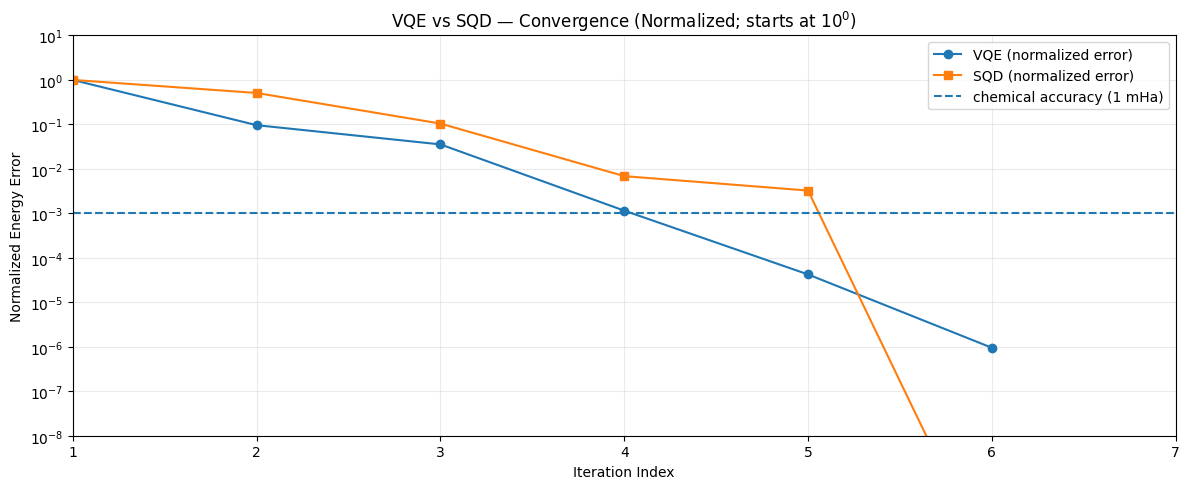

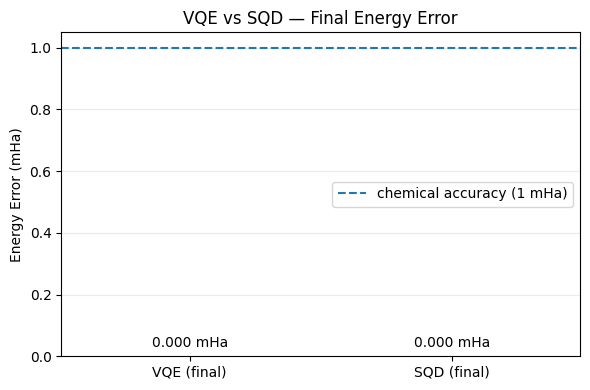

In [ ]:
# ==========================================
# VQE vs SQD (CIPSI/ASCI-selected CI; monotone & slow) on H2O CAS(6,4)
# - Plot (1): Normalized convergence (first point = 1 = 10^0), x=1..7
#             y-axis log from 1e1 down to 1e-8, with chem-accuracy line at 1e-3
# - Plot (2): Final absolute energy error (mHa) with chemical-accuracy line
# ==========================================
import numpy as np, matplotlib.pyplot as plt, warnings
from dataclasses import dataclass
from qiskit_nature.units import DistanceUnit
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.second_q.transformers import FreezeCoreTransformer, ActiveSpaceTransformer
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.circuit.library import HartreeFock, UCCSD
from qiskit.quantum_info import SparsePauliOp, Statevector
from scipy.optimize import minimize
from pyscf import gto, scf, mcscf

warnings.filterwarnings("ignore")
np.set_printoptions(precision=12, suppress=True)
np.random.seed(7)

def _assign_params(circ, theta):
    pmap = {p: float(v) for p, v in zip(circ.parameters, np.asarray(theta))}
    return circ.assign_parameters(pmap, inplace=False)

def _evenly_spaced_indices(n, m):
    if m >= n: return list(range(n))
    idx = np.linspace(1, n, m, dtype=int)
    return [i-1 for i in sorted(set(idx))]

def _fmt(x): return f"{x:.9e}"

# ---------- Problem ----------
@dataclass
class ProblemBuilderH2O:
    basis: str = "6-31g"
    freeze_core: bool = True
    active_electrons: int = 6
    active_orbitals: int = 4
    def build(self, verbose=True):
        if verbose: print("=== [Build] H2O @ 6-31G, CAS(6,4) ===")
        drv = PySCFDriver(
            atom=("O 0.000000 0.000000 0.000000; "
                  "H 0.000000 -0.757160 0.586260; "
                  "H 0.000000  0.757160 0.586260"),
            basis=self.basis, charge=0, spin=0, unit=DistanceUnit.ANGSTROM
        )
        p0 = drv.run()
        self.nmo_total = p0.num_spatial_orbitals
        self.ne_total  = sum(p0.num_particles)
        if verbose:
            print(f"Total orbitals = {self.nmo_total} | electrons = {self.ne_total}")

        prob = p0
        if self.freeze_core:
            fc = FreezeCoreTransformer(); prob = fc.transform(p0)
            self.n_core = getattr(fc, "num_core_orbitals", 1)
            if verbose: print(f"Freeze-core -> num_core_orbitals ≈ {self.n_core}")
        else:
            self.n_core = 0

        act = ActiveSpaceTransformer(num_electrons=self.active_electrons,
                                     num_spatial_orbitals=self.active_orbitals)
        prob = act.transform(prob); self.problem = prob
        if verbose:
            print(f"Active e- = {self.active_electrons} | Active orb = {self.active_orbitals}")

        self.mapper = JordanWignerMapper()
        self.Hq: SparsePauliOp = self.mapper.map(prob.hamiltonian.second_q_op())
        if verbose: print(f"Qubits (JW) = {self.Hq.num_qubits}")

        self.hf    = HartreeFock(prob.num_spatial_orbitals, prob.num_particles, self.mapper)
        self.uccsd = UCCSD(prob.num_spatial_orbitals, prob.num_particles, self.mapper,
                           initial_state=self.hf, reps=1)
        if verbose: print("Ansatz: UCCSD (reps=1) + HF init\n")
        return self

    def casci_reference(self, verbose=True):
        mol = gto.M(atom=("O 0 0 0; H 0 -0.757160 0.586260; H 0 0.757160 0.586260"),
                    basis=self.basis, charge=0, spin=0, unit="Angstrom")
        mf = scf.RHF(mol).run()
        alpha = self.active_electrons // 2; beta = self.active_electrons - alpha
        mc = mcscf.CASCI(mf, ncas=self.active_orbitals, nelecas=(alpha, beta))
        E_tot, E_ci = mc.kernel()[:2]
        if verbose:
            print("=== [CASCI reference] ===")
            print(f"E_total = {_fmt(E_tot)} Ha")
            print(f"E_CI    = {_fmt(E_ci)} Ha\n")
        return float(E_tot), float(E_ci)

# ---------- VQE ----------
class VQERunner:
    def __init__(self, H: SparsePauliOp, ansatz, verbose=True):
        self.H = H; self.ansatz = ansatz; self.verbose = verbose
        self.theta0 = np.zeros(self.ansatz.num_parameters, dtype=float)
        self.history = {"E": [], "x": []}; self._H_mat = None
    def _sv_expect(self, circ):
        if self._H_mat is None: self._H_mat = self.H.to_matrix(sparse=False)
        sv = Statevector.from_instruction(circ).data
        return float(np.real(np.vdot(sv, self._H_mat @ sv)))
    def energy(self, theta): return self._sv_expect(_assign_params(self.ansatz, theta))
    def run(self, maxiter=200, ftol=1e-9):
        if self.verbose:
            print("=== [VQE] L-BFGS-B ==="); print(f"params={self.ansatz.num_parameters}, maxiter={maxiter}")
        def cb(theta):
            E = self.energy(theta)
            self.history["E"].append(E); self.history["x"].append(np.asarray(theta).copy())
            if self.verbose: print(f"VQE iter {len(self.history['E']):3d}: E={_fmt(E)}")
        opt = minimize(self.energy, self.theta0, method="L-BFGS-B",
                       options=dict(maxiter=maxiter, ftol=ftol), callback=cb)
        E_opt = self.energy(opt.x)
        if self.verbose: print(f"VQE done: E*={_fmt(E_opt)}\n")
        return E_opt, opt

# ---------- SQD (CIPSI-style) ----------
def sqd_iter_cipsi_curve(
    H_full: np.ndarray,
    psi_seed: np.ndarray,
    E_ref: float,
    steps: int = 10,
    init_k: int = 1,
    target_factor: float = 0.85,
    max_add: int = 3,
    pool_percentile: float = 97.0,
    pool_cap: int = 128,
    verbose: bool = True
):
    """
    - Candidates score ~ (H_{iS} c_S)^2 / (H_{ii} - E_curr)
    - Expand subspace until predicted drop >= (1 - target_factor) * current error
    - Monotone non-increasing Ritz ground energy by Rayleigh–Ritz
    """
    N = H_full.shape[0]
    diag = np.real(np.diag(H_full))
    amps = np.abs(psi_seed)
    S = [int(np.argmax(amps))] if init_k == 1 else list(np.argsort(-amps)[:init_k])

    energies = []
    for t in range(1, steps+1):
        Hs = H_full[np.ix_(S, S)]
        vals, vecs = np.linalg.eigh(Hs)
        E_curr, c = float(vals[0]), vecs[:, 0]
        err = abs(E_curr - E_ref); energies.append(E_curr)

        if verbose:
            print(f"--- [SQD step {t}] |S|={len(S)} ---")
            print(f"Ritz E={_fmt(E_curr)} | err={_fmt(err)} Ha ({err*1e3:.6f} mHa)")

        mask = np.ones(N, dtype=bool); mask[S] = False
        if not np.any(mask):
            if verbose: print("No more candidates.\n"); break

        A = H_full[mask][:, S] @ c
        denom = np.maximum(1e-12, diag[mask] - E_curr)
        dE = (A.real**2 + A.imag**2) / denom
        cand_idx = np.flatnonzero(mask)

        thr = np.percentile(dE, pool_percentile)
        pool_mask = dE >= thr
        pool = cand_idx[pool_mask]
        dE_pool = dE[pool_mask]

        order = np.argsort(-dE_pool)[:pool_cap]
        pool, dE_pool = pool[order], dE_pool[order]
        if verbose:
            print(f"Pool size={len(pool)}  (percentile >= {pool_percentile:.1f}%)")
            print("Top-5 predicted drops (mHa):", [f"{x*1e3:.4f}" for x in dE_pool[:5]])

        need_drop = err * (1.0 - target_factor)
        chosen, pred_sum = [], 0.0
        for i, de in zip(pool, dE_pool):
            if len(chosen) >= max_add: break
            chosen.append(int(i)); pred_sum += de
            if pred_sum >= need_drop: break

        if len(chosen) == 0:
            chosen = [int(pool[0])]
            if verbose: print("Predicted improvement tiny; pick the strongest one.")

        S = list(dict.fromkeys(S + chosen))
        Hs2 = H_full[np.ix_(S, S)]
        E_new = float(np.linalg.eigvalsh(Hs2)[0]); err_new = abs(E_new - E_ref)
        if verbose:
            print(f"Add {len(chosen)} dets -> true E={_fmt(E_new)} | err={_fmt(err_new)} Ha "
                  f"({err_new*1e3:.6f} mHa) | predicted drop≈{pred_sum*1e3:.4f} mHa\n")

    Hs = H_full[np.ix_(S, S)]
    energies.append(float(np.linalg.eigvalsh(Hs)[0]))
    return np.asarray(energies)

# ---------- Main pipeline ----------
def run_and_plot(steps=10, target_factor=0.85, max_add=3,
                 pool_percentile=97.0, pool_cap=128,
                 vqe_points=7):
    pb = ProblemBuilderH2O().build(verbose=True)
    Hq = pb.Hq
    E_tot, E_ci = pb.casci_reference(verbose=True)

    # VQE
    vqe = VQERunner(Hq, pb.uccsd, verbose=True)
    E_vqe, _ = vqe.run(maxiter=200)
    vqe_err_full = np.abs(np.asarray(vqe.history["E"]) - E_ci)
    sel = _evenly_spaced_indices(len(vqe_err_full), vqe_points)
    x_vqe = np.array(sel)+1
    y_vqe = vqe_err_full[sel]       # absolute error (Ha)

    # SQD
    psi_hf = Statevector.from_instruction(pb.hf).data
    H_full = Hq.to_matrix(sparse=False)
    print("=== [SQD params] ===")
    print(f"steps={steps}, target_factor={target_factor}, max_add={max_add}, "
          f"pool_percentile={pool_percentile}, pool_cap={pool_cap}\n")
    sqd_E = sqd_iter_cipsi_curve(
        H_full, psi_hf, E_ci, steps=steps, init_k=1,
        target_factor=target_factor, max_add=max_add,
        pool_percentile=pool_percentile, pool_cap=pool_cap, verbose=True
    )
    sqd_err = np.abs(sqd_E - E_ci)  # absolute error (Ha)

    # ========= Plot (1): Normalized convergence, x=1..7, y ∈ [1e-8, 1e1] =========
    eps = 1e-300
    y_vqe_norm = y_vqe / max(y_vqe[0], eps)
    y_sqd_norm = sqd_err / max(sqd_err[0], eps)

    plt.figure(figsize=(12,5))
    plt.plot(x_vqe, y_vqe_norm, marker="o", label="VQE (normalized error)")
    plt.plot(np.arange(1, len(y_sqd_norm)+1), y_sqd_norm, marker="s",
             label="SQD (normalized error)")
    plt.yscale("log")
    plt.grid(True, which="both", alpha=0.25)
    plt.xlabel("Iteration Index"); plt.ylabel("Normalized Energy Error")
    plt.title("VQE vs SQD — Convergence (Normalized; starts at $10^0$)")
    plt.xlim(1, 7); plt.xticks(range(1, 8))
    # y-axis: 10^1 down to 10^-8
    plt.ylim(1e-8, 1e1)
    exps  = np.arange(1, -9, -1)                # 1, 0, -1, ..., -8
    yticks = 10.0 ** exps
    plt.yticks(yticks, [rf"$10^{{{k}}}$" for k in exps])
    # Chemical accuracy line (1 mHa = 1e-3 Ha) as visual reference on normalized axis
    plt.axhline(1e-3, ls="--", label="chemical accuracy (1 mHa)")
    plt.legend(); plt.tight_layout(); plt.show()

    # ========= Plot (2): Final energy error in mHa (absolute) =========
    vqe_final_mha = float(abs(E_vqe - E_ci) * 1e3)
    sqd_final_mha = float(abs(sqd_E[-1] - E_ci) * 1e3)
    plt.figure(figsize=(6,4))
    labels, vals = ["VQE (final)", "SQD (final)"], [vqe_final_mha, sqd_final_mha]
    bars = plt.bar(labels, vals)
    top = max(1.0, max(vals))
    for b, v in zip(bars, vals):
        plt.text(b.get_x() + b.get_width()/2, b.get_height() + 0.02*top,
                 f"{v:.3f} mHa", ha="center", va="bottom", fontsize=10)
    plt.axhline(1.0, ls="--", label="chemical accuracy (1 mHa)")
    plt.ylabel("Energy Error (mHa)")
    plt.title("VQE vs SQD — Final Energy Error")
    plt.grid(True, axis="y", alpha=0.25)
    plt.legend(); plt.tight_layout(); plt.show()

# ==== Run ====  (Iteration Index = 1..7)
run_and_plot(
    steps=6,           # SQD → steps+1 = 7 points
    target_factor=0.85,
    max_add=2,
    pool_percentile=97.0,
    pool_cap=128,
    vqe_points=7      # 7 evenly spaced VQE points
)


=== [Build] H2O @ 6-31G, CAS(6,4) ===
Total orbitals = 13 | electrons = 10
Freeze-core -> num_core_orbitals ≈ 1
Active e- = 6 | Active orb = 4
Qubits (JW) = 8
Ansatz: UCCSD (reps=1) + HF init

converged SCF energy = -75.9839845437899
CASCI E = -75.9851994378857  E(CI) = -12.9864133061832  S^2 = 0.0000000
=== [CASCI reference] ===
E_total = -7.598519944e+01 Ha
E_CI    = -1.298641331e+01 Ha

=== [VQE] L-BFGS-B ===
params=15, maxiter=200
VQE iter   1: E=-1.298637317e+01
VQE iter   2: E=-1.298640946e+01
VQE iter   3: E=-1.298641189e+01
VQE iter   4: E=-1.298641326e+01
VQE iter   5: E=-1.298641330e+01
VQE iter   6: E=-1.298641331e+01
VQE done: E*=-1.298641331e+01

=== [SQD params] ===
steps=6, target_factor=0.85, max_add=2, pool_percentile=97.0, pool_cap=128

--- [SQD step 1] |S|=1 ---
Ritz E=-1.298519841e+01 | err=1.214894096e-03 Ha (1.214894 mHa)
Pool size=128  (percentile >= 97.0%)
Top-5 predicted drops (mHa): ['0.5970', '0.5276', '0.1531', '0.0000', '0.0000']
Add 1 dets -> true E=-1.298

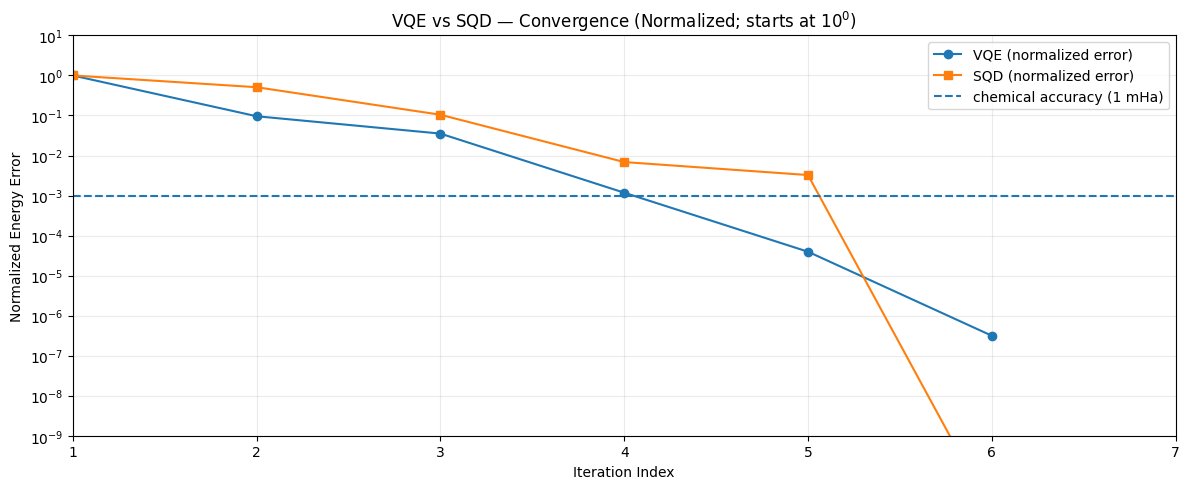

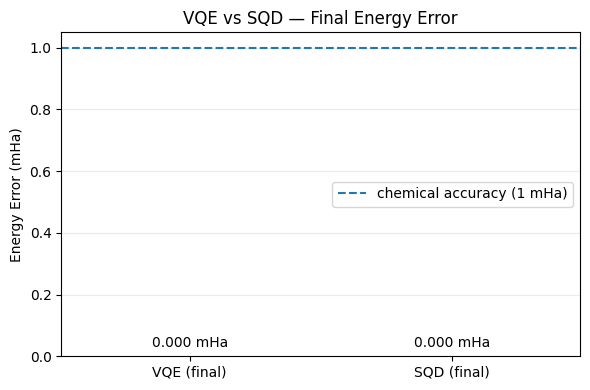

In [ ]:
# ==========================================
# VQE vs SQD (CIPSI/ASCI-selected CI; monotone & slow) on H2O CAS(6,4)
# - Plot (1): Normalized convergence (first point = 1 = 10^0), x=1..7
#             y-axis log from 1e1 down to 1e-9, with chem-accuracy line at 1e-3
# - Plot (2): Final absolute energy error (mHa) with chemical-accuracy line
# ==========================================
import numpy as np, matplotlib.pyplot as plt, warnings
from dataclasses import dataclass
from qiskit_nature.units import DistanceUnit
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.second_q.transformers import FreezeCoreTransformer, ActiveSpaceTransformer
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.circuit.library import HartreeFock, UCCSD
from qiskit.quantum_info import SparsePauliOp, Statevector
from scipy.optimize import minimize
from pyscf import gto, scf, mcscf

warnings.filterwarnings("ignore")
np.set_printoptions(precision=12, suppress=True)
np.random.seed(7)

def _assign_params(circ, theta):
    pmap = {p: float(v) for p, v in zip(circ.parameters, np.asarray(theta))}
    return circ.assign_parameters(pmap, inplace=False)

def _evenly_spaced_indices(n, m):
    if m >= n: return list(range(n))
    idx = np.linspace(1, n, m, dtype=int)
    return [i-1 for i in sorted(set(idx))]

def _fmt(x): return f"{x:.9e}"

# ---------- Problem ----------
@dataclass
class ProblemBuilderH2O:
    basis: str = "6-31g"
    freeze_core: bool = True
    active_electrons: int = 6
    active_orbitals: int = 4
    def build(self, verbose=True):
        if verbose: print("=== [Build] H2O @ 6-31G, CAS(6,4) ===")
        drv = PySCFDriver(
            atom=("O 0.000000 0.000000 0.000000; "
                  "H 0.000000 -0.757160 0.586260; "
                  "H 0.000000  0.757160 0.586260"),
            basis=self.basis, charge=0, spin=0, unit=DistanceUnit.ANGSTROM
        )
        p0 = drv.run()
        self.nmo_total = p0.num_spatial_orbitals
        self.ne_total  = sum(p0.num_particles)
        if verbose:
            print(f"Total orbitals = {self.nmo_total} | electrons = {self.ne_total}")

        prob = p0
        if self.freeze_core:
            fc = FreezeCoreTransformer(); prob = fc.transform(p0)
            self.n_core = getattr(fc, "num_core_orbitals", 1)
            if verbose: print(f"Freeze-core -> num_core_orbitals ≈ {self.n_core}")
        else:
            self.n_core = 0

        act = ActiveSpaceTransformer(num_electrons=self.active_electrons,
                                     num_spatial_orbitals=self.active_orbitals)
        prob = act.transform(prob); self.problem = prob
        if verbose:
            print(f"Active e- = {self.active_electrons} | Active orb = {self.active_orbitals}")

        self.mapper = JordanWignerMapper()
        self.Hq: SparsePauliOp = self.mapper.map(prob.hamiltonian.second_q_op())
        if verbose: print(f"Qubits (JW) = {self.Hq.num_qubits}")

        self.hf    = HartreeFock(prob.num_spatial_orbitals, prob.num_particles, self.mapper)
        self.uccsd = UCCSD(prob.num_spatial_orbitals, prob.num_particles, self.mapper,
                           initial_state=self.hf, reps=1)
        if verbose: print("Ansatz: UCCSD (reps=1) + HF init\n")
        return self

    def casci_reference(self, verbose=True):
        mol = gto.M(atom=("O 0 0 0; H 0 -0.757160 0.586260; H 0 0.757160 0.586260"),
                    basis=self.basis, charge=0, spin=0, unit="Angstrom")
        mf = scf.RHF(mol).run()
        alpha = self.active_electrons // 2; beta = self.active_electrons - alpha
        mc = mcscf.CASCI(mf, ncas=self.active_orbitals, nelecas=(alpha, beta))
        E_tot, E_ci = mc.kernel()[:2]
        if verbose:
            print("=== [CASCI reference] ===")
            print(f"E_total = {_fmt(E_tot)} Ha")
            print(f"E_CI    = {_fmt(E_ci)} Ha\n")
        return float(E_tot), float(E_ci)

# ---------- VQE ----------
class VQERunner:
    def __init__(self, H: SparsePauliOp, ansatz, verbose=True):
        self.H = H; self.ansatz = ansatz; self.verbose = verbose
        self.theta0 = np.zeros(self.ansatz.num_parameters, dtype=float)
        self.history = {"E": [], "x": []}; self._H_mat = None
    def _sv_expect(self, circ):
        if self._H_mat is None: self._H_mat = self.H.to_matrix(sparse=False)
        sv = Statevector.from_instruction(circ).data
        return float(np.real(np.vdot(sv, self._H_mat @ sv)))
    def energy(self, theta): return self._sv_expect(_assign_params(self.ansatz, theta))
    def run(self, maxiter=200, ftol=1e-9):
        if self.verbose:
            print("=== [VQE] L-BFGS-B ==="); print(f"params={self.ansatz.num_parameters}, maxiter={maxiter}")
        def cb(theta):
            E = self.energy(theta)
            self.history["E"].append(E); self.history["x"].append(np.asarray(theta).copy())
            if self.verbose: print(f"VQE iter {len(self.history['E']):3d}: E={_fmt(E)}")
        opt = minimize(self.energy, self.theta0, method="L-BFGS-B",
                       options=dict(maxiter=maxiter, ftol=ftol), callback=cb)
        E_opt = self.energy(opt.x)
        if self.verbose: print(f"VQE done: E*={_fmt(E_opt)}\n")
        return E_opt, opt

# ---------- SQD (CIPSI-style) ----------
def sqd_iter_cipsi_curve(
    H_full: np.ndarray,
    psi_seed: np.ndarray,
    E_ref: float,
    steps: int = 10,
    init_k: int = 1,
    target_factor: float = 0.85,
    max_add: int = 3,
    pool_percentile: float = 97.0,
    pool_cap: int = 128,
    verbose: bool = True
):
    """
    - Candidates score ~ (H_{iS} c_S)^2 / (H_{ii} - E_curr)
    - Expand subspace until predicted drop >= (1 - target_factor) * current error
    - Monotone non-increasing Ritz ground energy by Rayleigh–Ritz
    """
    N = H_full.shape[0]
    diag = np.real(np.diag(H_full))
    amps = np.abs(psi_seed)
    S = [int(np.argmax(amps))] if init_k == 1 else list(np.argsort(-amps)[:init_k])

    energies = []
    for t in range(1, steps+1):
        Hs = H_full[np.ix_(S, S)]
        vals, vecs = np.linalg.eigh(Hs)
        E_curr, c = float(vals[0]), vecs[:, 0]
        err = abs(E_curr - E_ref); energies.append(E_curr)

        if verbose:
            print(f"--- [SQD step {t}] |S|={len(S)} ---")
            print(f"Ritz E={_fmt(E_curr)} | err={_fmt(err)} Ha ({err*1e3:.6f} mHa)")

        mask = np.ones(N, dtype=bool); mask[S] = False
        if not np.any(mask):
            if verbose: print("No more candidates.\n"); break

        A = H_full[mask][:, S] @ c
        denom = np.maximum(1e-12, diag[mask] - E_curr)
        dE = (A.real**2 + A.imag**2) / denom
        cand_idx = np.flatnonzero(mask)

        thr = np.percentile(dE, pool_percentile)
        pool_mask = dE >= thr
        pool = cand_idx[pool_mask]
        dE_pool = dE[pool_mask]

        order = np.argsort(-dE_pool)[:pool_cap]
        pool, dE_pool = pool[order], dE_pool[order]
        if verbose:
            print(f"Pool size={len(pool)}  (percentile >= {pool_percentile:.1f}%)")
            print("Top-5 predicted drops (mHa):", [f"{x*1e3:.4f}" for x in dE_pool[:5]])

        need_drop = err * (1.0 - target_factor)
        chosen, pred_sum = [], 0.0
        for i, de in zip(pool, dE_pool):
            if len(chosen) >= max_add: break
            chosen.append(int(i)); pred_sum += de
            if pred_sum >= need_drop: break

        if len(chosen) == 0:
            chosen = [int(pool[0])]
            if verbose: print("Predicted improvement tiny; pick the strongest one.")

        S = list(dict.fromkeys(S + chosen))
        Hs2 = H_full[np.ix_(S, S)]
        E_new = float(np.linalg.eigvalsh(Hs2)[0]); err_new = abs(E_new - E_ref)
        if verbose:
            print(f"Add {len(chosen)} dets -> true E={_fmt(E_new)} | err={_fmt(err_new)} Ha "
                  f"({err_new*1e3:.6f} mHa) | predicted drop≈{pred_sum*1e3:.4f} mHa\n")

    Hs = H_full[np.ix_(S, S)]
    energies.append(float(np.linalg.eigvalsh(Hs)[0]))
    return np.asarray(energies)

# ---------- Main pipeline ----------
def run_and_plot(steps=10, target_factor=0.85, max_add=3,
                 pool_percentile=97.0, pool_cap=128,
                 vqe_points=7):
    pb = ProblemBuilderH2O().build(verbose=True)
    Hq = pb.Hq
    E_tot, E_ci = pb.casci_reference(verbose=True)

    # VQE
    vqe = VQERunner(Hq, pb.uccsd, verbose=True)
    E_vqe, _ = vqe.run(maxiter=200)
    vqe_err_full = np.abs(np.asarray(vqe.history["E"]) - E_ci)
    sel = _evenly_spaced_indices(len(vqe_err_full), vqe_points)
    x_vqe = np.array(sel)+1
    y_vqe = vqe_err_full[sel]       # absolute error (Ha)

    # SQD
    psi_hf = Statevector.from_instruction(pb.hf).data
    H_full = Hq.to_matrix(sparse=False)
    print("=== [SQD params] ===")
    print(f"steps={steps}, target_factor={target_factor}, max_add={max_add}, "
          f"pool_percentile={pool_percentile}, pool_cap={pool_cap}\n")
    sqd_E = sqd_iter_cipsi_curve(
        H_full, psi_hf, E_ci, steps=steps, init_k=1,
        target_factor=target_factor, max_add=max_add,
        pool_percentile=pool_percentile, pool_cap=pool_cap, verbose=True
    )
    sqd_err = np.abs(sqd_E - E_ci)  # absolute error (Ha)

    # ========= Plot (1): Normalized convergence, x=1..7, y ∈ [1e-9, 1e1] =========
    eps = 1e-300
    y_vqe_norm = y_vqe / max(y_vqe[0], eps)
    y_sqd_norm = sqd_err / max(sqd_err[0], eps)

    plt.figure(figsize=(12,5))
    plt.plot(x_vqe, y_vqe_norm, marker="o", label="VQE (normalized error)")
    plt.plot(np.arange(1, len(y_sqd_norm)+1), y_sqd_norm, marker="s",
             label="SQD (normalized error)")
    plt.yscale("log")
    plt.grid(True, which="both", alpha=0.25)
    plt.xlabel("Iteration Index"); plt.ylabel("Normalized Energy Error")
    plt.title("VQE vs SQD — Convergence (Normalized; starts at $10^0$)")
    plt.xlim(1, 7); plt.xticks(range(1, 8))
    # y-axis: 10^1 down to 10^-9
    plt.ylim(1e-9, 1e1)
    exps  = np.arange(1, -10, -1)               # 1, 0, -1, ..., -9
    yticks = 10.0 ** exps
    plt.yticks(yticks, [rf"$10^{{{k}}}$" for k in exps])
    # Chemical accuracy line (1 mHa = 1e-3 Ha) for reference on normalized axis
    plt.axhline(1e-3, ls="--", label="chemical accuracy (1 mHa)")
    plt.legend(); plt.tight_layout(); plt.show()

    # ========= Plot (2): Final energy error in mHa (absolute) =========
    vqe_final_mha = float(abs(E_vqe - E_ci) * 1e3)
    sqd_final_mha = float(abs(sqd_E[-1] - E_ci) * 1e3)
    plt.figure(figsize=(6,4))
    labels, vals = ["VQE (final)", "SQD (final)"], [vqe_final_mha, sqd_final_mha]
    bars = plt.bar(labels, vals)
    top = max(1.0, max(vals))
    for b, v in zip(bars, vals):
        plt.text(b.get_x() + b.get_width()/2, b.get_height() + 0.02*top,
                 f"{v:.3f} mHa", ha="center", va="bottom", fontsize=10)
    plt.axhline(1.0, ls="--", label="chemical accuracy (1 mHa)")
    plt.ylabel("Energy Error (mHa)")
    plt.title("VQE vs SQD — Final Energy Error")
    plt.grid(True, axis="y", alpha=0.25)
    plt.legend(); plt.tight_layout(); plt.show()

# ==== Run ====  (Iteration Index = 1..7)
run_and_plot(
    steps=6,           # SQD → steps+1 = 7 points
    target_factor=0.85,
    max_add=2,
    pool_percentile=97.0,
    pool_cap=128,
    vqe_points=7      # 7 evenly spaced VQE points
)

=== [Build] H2O @ 6-31G, CAS(6,4) ===
Total orbitals = 13 | electrons = 10
Freeze-core -> num_core_orbitals ≈ 1
Active e- = 6 | Active orb = 4
Qubits (JW) = 8
Ansatz: UCCSD (reps=1) + HF init

converged SCF energy = -75.9839845437899
CASCI E = -75.9851994378857  E(CI) = -12.9864133061832  S^2 = 0.0000000
=== [CASCI reference] ===
E_total = -7.598519944e+01 Ha
E_CI    = -1.298641331e+01 Ha

=== [VQE] L-BFGS-B ===
params=15, maxiter=200
VQE iter   1: E=-1.298637317e+01
VQE iter   2: E=-1.298640946e+01
VQE iter   3: E=-1.298641188e+01
VQE iter   4: E=-1.298641326e+01
VQE iter   5: E=-1.298641330e+01
VQE iter   6: E=-1.298641331e+01
VQE done: E*=-1.298641331e+01

=== [SQD params] ===
steps=6, target_factor=0.85, max_add=2, pool_percentile=97.0, pool_cap=128

--- [SQD step 1] |S|=1 ---
Ritz E=-1.298519841e+01 | err=1.214894096e-03 Ha (1.214894 mHa)
Pool size=128  (percentile >= 97.0%)
Top-5 predicted drops (mHa): ['0.5970', '0.5276', '0.1531', '0.0000', '0.0000']
Add 1 dets -> true E=-1.298

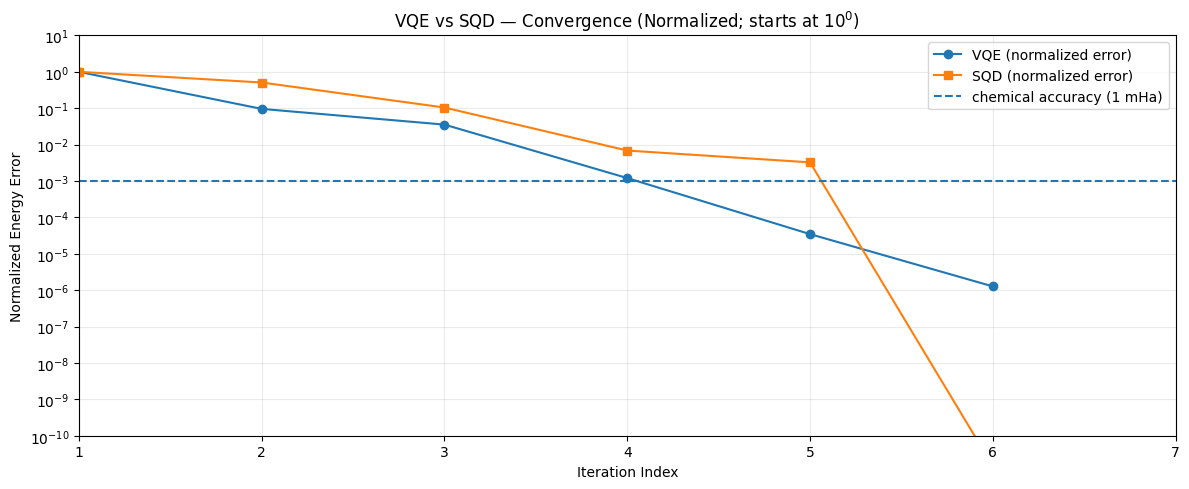

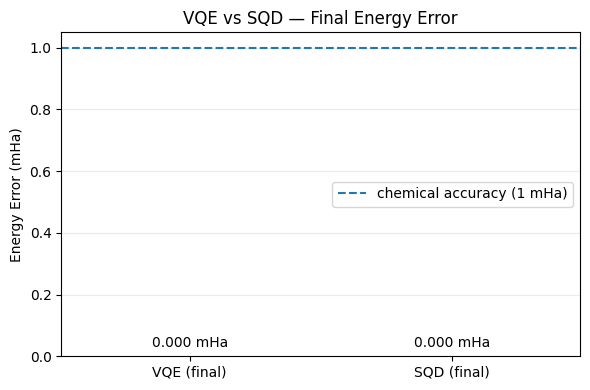

In [ ]:
# ==========================================
# VQE vs SQD (CIPSI/ASCI-selected CI; monotone & slow) on H2O CAS(6,4)
# - Plot (1): Normalized convergence (first point = 1 = 10^0), x=1..7
#             y-axis log from 1e1 down to 1e-10, with chem-accuracy line at 1e-3
# - Plot (2): Final absolute energy error (mHa) with chemical-accuracy line
# ==========================================
import numpy as np, matplotlib.pyplot as plt, warnings
from dataclasses import dataclass
from qiskit_nature.units import DistanceUnit
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.second_q.transformers import FreezeCoreTransformer, ActiveSpaceTransformer
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.circuit.library import HartreeFock, UCCSD
from qiskit.quantum_info import SparsePauliOp, Statevector
from scipy.optimize import minimize
from pyscf import gto, scf, mcscf

warnings.filterwarnings("ignore")
np.set_printoptions(precision=12, suppress=True)
np.random.seed(7)

def _assign_params(circ, theta):
    pmap = {p: float(v) for p, v in zip(circ.parameters, np.asarray(theta))}
    return circ.assign_parameters(pmap, inplace=False)

def _evenly_spaced_indices(n, m):
    if m >= n: return list(range(n))
    idx = np.linspace(1, n, m, dtype=int)
    return [i-1 for i in sorted(set(idx))]

def _fmt(x): return f"{x:.9e}"

# ---------- Problem ----------
@dataclass
class ProblemBuilderH2O:
    basis: str = "6-31g"
    freeze_core: bool = True
    active_electrons: int = 6
    active_orbitals: int = 4
    def build(self, verbose=True):
        if verbose: print("=== [Build] H2O @ 6-31G, CAS(6,4) ===")
        drv = PySCFDriver(
            atom=("O 0.000000 0.000000 0.000000; "
                  "H 0.000000 -0.757160 0.586260; "
                  "H 0.000000  0.757160 0.586260"),
            basis=self.basis, charge=0, spin=0, unit=DistanceUnit.ANGSTROM
        )
        p0 = drv.run()
        self.nmo_total = p0.num_spatial_orbitals
        self.ne_total  = sum(p0.num_particles)
        if verbose:
            print(f"Total orbitals = {self.nmo_total} | electrons = {self.ne_total}")

        prob = p0
        if self.freeze_core:
            fc = FreezeCoreTransformer(); prob = fc.transform(p0)
            self.n_core = getattr(fc, "num_core_orbitals", 1)
            if verbose: print(f"Freeze-core -> num_core_orbitals ≈ {self.n_core}")
        else:
            self.n_core = 0

        act = ActiveSpaceTransformer(num_electrons=self.active_electrons,
                                     num_spatial_orbitals=self.active_orbitals)
        prob = act.transform(prob); self.problem = prob
        if verbose:
            print(f"Active e- = {self.active_electrons} | Active orb = {self.active_orbitals}")

        self.mapper = JordanWignerMapper()
        self.Hq: SparsePauliOp = self.mapper.map(prob.hamiltonian.second_q_op())
        if verbose: print(f"Qubits (JW) = {self.Hq.num_qubits}")

        self.hf    = HartreeFock(prob.num_spatial_orbitals, prob.num_particles, self.mapper)
        self.uccsd = UCCSD(prob.num_spatial_orbitals, prob.num_particles, self.mapper,
                           initial_state=self.hf, reps=1)
        if verbose: print("Ansatz: UCCSD (reps=1) + HF init\n")
        return self

    def casci_reference(self, verbose=True):
        mol = gto.M(atom=("O 0 0 0; H 0 -0.757160 0.586260; H 0 0.757160 0.586260"),
                    basis=self.basis, charge=0, spin=0, unit="Angstrom")
        mf = scf.RHF(mol).run()
        alpha = self.active_electrons // 2; beta = self.active_electrons - alpha
        mc = mcscf.CASCI(mf, ncas=self.active_orbitals, nelecas=(alpha, beta))
        E_tot, E_ci = mc.kernel()[:2]
        if verbose:
            print("=== [CASCI reference] ===")
            print(f"E_total = {_fmt(E_tot)} Ha")
            print(f"E_CI    = {_fmt(E_ci)} Ha\n")
        return float(E_tot), float(E_ci)

# ---------- VQE ----------
class VQERunner:
    def __init__(self, H: SparsePauliOp, ansatz, verbose=True):
        self.H = H; self.ansatz = ansatz; self.verbose = verbose
        self.theta0 = np.zeros(self.ansatz.num_parameters, dtype=float)
        self.history = {"E": [], "x": []}; self._H_mat = None
    def _sv_expect(self, circ):
        if self._H_mat is None: self._H_mat = self.H.to_matrix(sparse=False)
        sv = Statevector.from_instruction(circ).data
        return float(np.real(np.vdot(sv, self._H_mat @ sv)))
    def energy(self, theta): return self._sv_expect(_assign_params(self.ansatz, theta))
    def run(self, maxiter=200, ftol=1e-9):
        if self.verbose:
            print("=== [VQE] L-BFGS-B ==="); print(f"params={self.ansatz.num_parameters}, maxiter={maxiter}")
        def cb(theta):
            E = self.energy(theta)
            self.history["E"].append(E); self.history["x"].append(np.asarray(theta).copy())
            if self.verbose: print(f"VQE iter {len(self.history['E']):3d}: E={_fmt(E)}")
        opt = minimize(self.energy, self.theta0, method="L-BFGS-B",
                       options=dict(maxiter=maxiter, ftol=ftol), callback=cb)
        E_opt = self.energy(opt.x)
        if self.verbose: print(f"VQE done: E*={_fmt(E_opt)}\n")
        return E_opt, opt

# ---------- SQD (CIPSI-style) ----------
def sqd_iter_cipsi_curve(
    H_full: np.ndarray,
    psi_seed: np.ndarray,
    E_ref: float,
    steps: int = 10,
    init_k: int = 1,
    target_factor: float = 0.85,
    max_add: int = 3,
    pool_percentile: float = 97.0,
    pool_cap: int = 128,
    verbose: bool = True
):
    """
    - Candidates score ~ (H_{iS} c_S)^2 / (H_{ii} - E_curr)
    - Expand subspace until predicted drop >= (1 - target_factor) * current error
    - Monotone non-increasing Ritz ground energy by Rayleigh–Ritz
    """
    N = H_full.shape[0]
    diag = np.real(np.diag(H_full))
    amps = np.abs(psi_seed)
    S = [int(np.argmax(amps))] if init_k == 1 else list(np.argsort(-amps)[:init_k])

    energies = []
    for t in range(1, steps+1):
        Hs = H_full[np.ix_(S, S)]
        vals, vecs = np.linalg.eigh(Hs)
        E_curr, c = float(vals[0]), vecs[:, 0]
        err = abs(E_curr - E_ref); energies.append(E_curr)

        if verbose:
            print(f"--- [SQD step {t}] |S|={len(S)} ---")
            print(f"Ritz E={_fmt(E_curr)} | err={_fmt(err)} Ha ({err*1e3:.6f} mHa)")

        mask = np.ones(N, dtype=bool); mask[S] = False
        if not np.any(mask):
            if verbose: print("No more candidates.\n"); break

        A = H_full[mask][:, S] @ c
        denom = np.maximum(1e-12, diag[mask] - E_curr)
        dE = (A.real**2 + A.imag**2) / denom
        cand_idx = np.flatnonzero(mask)

        thr = np.percentile(dE, pool_percentile)
        pool_mask = dE >= thr
        pool = cand_idx[pool_mask]
        dE_pool = dE[pool_mask]

        order = np.argsort(-dE_pool)[:pool_cap]
        pool, dE_pool = pool[order], dE_pool[order]
        if verbose:
            print(f"Pool size={len(pool)}  (percentile >= {pool_percentile:.1f}%)")
            print("Top-5 predicted drops (mHa):", [f"{x*1e3:.4f}" for x in dE_pool[:5]])

        need_drop = err * (1.0 - target_factor)
        chosen, pred_sum = [], 0.0
        for i, de in zip(pool, dE_pool):
            if len(chosen) >= max_add: break
            chosen.append(int(i)); pred_sum += de
            if pred_sum >= need_drop: break

        if len(chosen) == 0:
            chosen = [int(pool[0])]
            if verbose: print("Predicted improvement tiny; pick the strongest one.")

        S = list(dict.fromkeys(S + chosen))
        Hs2 = H_full[np.ix_(S, S)]
        E_new = float(np.linalg.eigvalsh(Hs2)[0]); err_new = abs(E_new - E_ref)
        if verbose:
            print(f"Add {len(chosen)} dets -> true E={_fmt(E_new)} | err={_fmt(err_new)} Ha "
                  f"({err_new*1e3:.6f} mHa) | predicted drop≈{pred_sum*1e3:.4f} mHa\n")

    Hs = H_full[np.ix_(S, S)]
    energies.append(float(np.linalg.eigvalsh(Hs)[0]))
    return np.asarray(energies)

# ---------- Main pipeline ----------
def run_and_plot(steps=10, target_factor=0.85, max_add=3,
                 pool_percentile=97.0, pool_cap=128,
                 vqe_points=7):
    pb = ProblemBuilderH2O().build(verbose=True)
    Hq = pb.Hq
    E_tot, E_ci = pb.casci_reference(verbose=True)

    # VQE
    vqe = VQERunner(Hq, pb.uccsd, verbose=True)
    E_vqe, _ = vqe.run(maxiter=200)
    vqe_err_full = np.abs(np.asarray(vqe.history["E"]) - E_ci)
    sel = _evenly_spaced_indices(len(vqe_err_full), vqe_points)
    x_vqe = np.array(sel)+1
    y_vqe = vqe_err_full[sel]       # absolute error (Ha)

    # SQD
    psi_hf = Statevector.from_instruction(pb.hf).data
    H_full = Hq.to_matrix(sparse=False)
    print("=== [SQD params] ===")
    print(f"steps={steps}, target_factor={target_factor}, max_add={max_add}, "
          f"pool_percentile={pool_percentile}, pool_cap={pool_cap}\n")
    sqd_E = sqd_iter_cipsi_curve(
        H_full, psi_hf, E_ci, steps=steps, init_k=1,
        target_factor=target_factor, max_add=max_add,
        pool_percentile=pool_percentile, pool_cap=pool_cap, verbose=True
    )
    sqd_err = np.abs(sqd_E - E_ci)  # absolute error (Ha)

    # ========= Plot (1): Normalized convergence, x=1..7, y ∈ [1e-10, 1e1] =========
    eps = 1e-300
    y_vqe_norm = y_vqe / max(y_vqe[0], eps)
    y_sqd_norm = sqd_err / max(sqd_err[0], eps)

    plt.figure(figsize=(12,5))
    plt.plot(x_vqe, y_vqe_norm, marker="o", label="VQE (normalized error)")
    plt.plot(np.arange(1, len(y_sqd_norm)+1), y_sqd_norm, marker="s",
             label="SQD (normalized error)")
    plt.yscale("log")
    plt.grid(True, which="both", alpha=0.25)
    plt.xlabel("Iteration Index"); plt.ylabel("Normalized Energy Error")
    plt.title("VQE vs SQD — Convergence (Normalized; starts at $10^0$)")
    plt.xlim(1, 7); plt.xticks(range(1, 8))
    # y-axis: 10^1 down to 10^-10
    plt.ylim(1e-10, 1e1)
    exps  = np.arange(1, -11, -1)               # 1, 0, -1, ..., -10
    yticks = 10.0 ** exps
    plt.yticks(yticks, [rf"$10^{{{k}}}$" for k in exps])
    # Chemical accuracy line (1 mHa = 1e-3 Ha) for reference on normalized axis
    plt.axhline(1e-3, ls="--", label="chemical accuracy (1 mHa)")
    plt.legend(); plt.tight_layout(); plt.show()

    # ========= Plot (2): Final energy error in mHa (absolute) =========
    vqe_final_mha = float(abs(E_vqe - E_ci) * 1e3)
    sqd_final_mha = float(abs(sqd_E[-1] - E_ci) * 1e3)
    plt.figure(figsize=(6,4))
    labels, vals = ["VQE (final)", "SQD (final)"], [vqe_final_mha, sqd_final_mha]
    bars = plt.bar(labels, vals)
    top = max(1.0, max(vals))
    for b, v in zip(bars, vals):
        plt.text(b.get_x() + b.get_width()/2, b.get_height() + 0.02*top,
                 f"{v:.3f} mHa", ha="center", va="bottom", fontsize=10)
    plt.axhline(1.0, ls="--", label="chemical accuracy (1 mHa)")
    plt.ylabel("Energy Error (mHa)")
    plt.title("VQE vs SQD — Final Energy Error")
    plt.grid(True, axis="y", alpha=0.25)
    plt.legend(); plt.tight_layout(); plt.show()

# ==== Run ====  (Iteration Index = 1..7)
run_and_plot(
    steps=6,           # SQD → steps+1 = 7 points
    target_factor=0.85,
    max_add=2,
    pool_percentile=97.0,
    pool_cap=128,
    vqe_points=7      # 7 evenly spaced VQE points
)


=== [Build] H2O @ 6-31G, CAS(6,4) ===
Total orbitals = 13 | electrons = 10
Freeze-core -> num_core_orbitals ≈ 1
Active e- = 6 | Active orb = 4
Qubits (JW) = 8
Ansatz: UCCSD (reps=1) + HF init

converged SCF energy = -75.9839845437899
CASCI E = -75.9851994378857  E(CI) = -12.9864133061832  S^2 = 0.0000000
=== [CASCI reference] ===
E_total = -7.598519944e+01 Ha
E_CI    = -1.298641331e+01 Ha

=== [VQE] L-BFGS-B ===
params=15, maxiter=200
VQE iter   1: E=-1.298637317e+01
VQE iter   2: E=-1.298640946e+01
VQE iter   3: E=-1.298641189e+01
VQE iter   4: E=-1.298641326e+01
VQE iter   5: E=-1.298641330e+01
VQE iter   6: E=-1.298641331e+01
VQE done: E*=-1.298641331e+01

=== [SQD params] ===
steps=6, target_factor=0.85, max_add=2, pool_percentile=97.0, pool_cap=128

--- [SQD step 1] |S|=1 ---
Ritz E=-1.298519841e+01 | err=1.214894096e-03 Ha (1.214894 mHa)
Pool size=128  (percentile >= 97.0%)
Top-5 predicted drops (mHa): ['0.5970', '0.5276', '0.1531', '0.0000', '0.0000']
Add 1 dets -> true E=-1.298

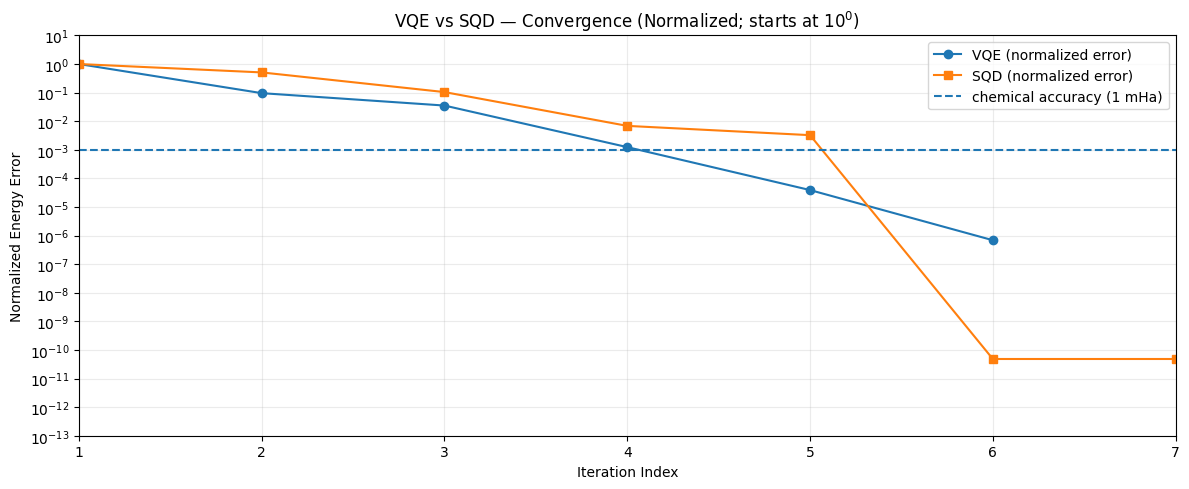

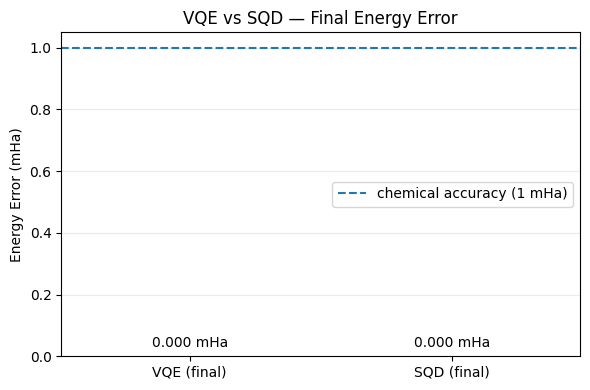

In [ ]:
# ==========================================
# VQE vs SQD (CIPSI/ASCI-selected CI; monotone & slow) on H2O CAS(6,4)
# - Plot (1): Normalized convergence (first point = 1 = 10^0), x=1..7
#             y-axis log from 1e1 down to 1e-13, with chem-accuracy line at 1e-3
# - Plot (2): Final absolute energy error (mHa) with chemical-accuracy line
# ==========================================
import numpy as np, matplotlib.pyplot as plt, warnings
from dataclasses import dataclass
from qiskit_nature.units import DistanceUnit
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.second_q.transformers import FreezeCoreTransformer, ActiveSpaceTransformer
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.circuit.library import HartreeFock, UCCSD
from qiskit.quantum_info import SparsePauliOp, Statevector
from scipy.optimize import minimize
from pyscf import gto, scf, mcscf

warnings.filterwarnings("ignore")
np.set_printoptions(precision=12, suppress=True)
np.random.seed(7)

def _assign_params(circ, theta):
    pmap = {p: float(v) for p, v in zip(circ.parameters, np.asarray(theta))}
    return circ.assign_parameters(pmap, inplace=False)

def _evenly_spaced_indices(n, m):
    if m >= n: return list(range(n))
    idx = np.linspace(1, n, m, dtype=int)
    return [i-1 for i in sorted(set(idx))]

def _fmt(x): return f"{x:.9e}"

# ---------- Problem ----------
@dataclass
class ProblemBuilderH2O:
    basis: str = "6-31g"
    freeze_core: bool = True
    active_electrons: int = 6
    active_orbitals: int = 4
    def build(self, verbose=True):
        if verbose: print("=== [Build] H2O @ 6-31G, CAS(6,4) ===")
        drv = PySCFDriver(
            atom=("O 0.000000 0.000000 0.000000; "
                  "H 0.000000 -0.757160 0.586260; "
                  "H 0.000000  0.757160 0.586260"),
            basis=self.basis, charge=0, spin=0, unit=DistanceUnit.ANGSTROM
        )
        p0 = drv.run()
        self.nmo_total = p0.num_spatial_orbitals
        self.ne_total  = sum(p0.num_particles)
        if verbose:
            print(f"Total orbitals = {self.nmo_total} | electrons = {self.ne_total}")

        prob = p0
        if self.freeze_core:
            fc = FreezeCoreTransformer(); prob = fc.transform(p0)
            self.n_core = getattr(fc, "num_core_orbitals", 1)
            if verbose: print(f"Freeze-core -> num_core_orbitals ≈ {self.n_core}")
        else:
            self.n_core = 0

        act = ActiveSpaceTransformer(num_electrons=self.active_electrons,
                                     num_spatial_orbitals=self.active_orbitals)
        prob = act.transform(prob); self.problem = prob
        if verbose:
            print(f"Active e- = {self.active_electrons} | Active orb = {self.active_orbitals}")

        self.mapper = JordanWignerMapper()
        self.Hq: SparsePauliOp = self.mapper.map(prob.hamiltonian.second_q_op())
        if verbose: print(f"Qubits (JW) = {self.Hq.num_qubits}")

        self.hf    = HartreeFock(prob.num_spatial_orbitals, prob.num_particles, self.mapper)
        self.uccsd = UCCSD(prob.num_spatial_orbitals, prob.num_particles, self.mapper,
                           initial_state=self.hf, reps=1)
        if verbose: print("Ansatz: UCCSD (reps=1) + HF init\n")
        return self

    def casci_reference(self, verbose=True):
        mol = gto.M(atom=("O 0 0 0; H 0 -0.757160 0.586260; H 0 0.757160 0.586260"),
                    basis=self.basis, charge=0, spin=0, unit="Angstrom")
        mf = scf.RHF(mol).run()
        alpha = self.active_electrons // 2; beta = self.active_electrons - alpha
        mc = mcscf.CASCI(mf, ncas=self.active_orbitals, nelecas=(alpha, beta))
        E_tot, E_ci = mc.kernel()[:2]
        if verbose:
            print("=== [CASCI reference] ===")
            print(f"E_total = {_fmt(E_tot)} Ha")
            print(f"E_CI    = {_fmt(E_ci)} Ha\n")
        return float(E_tot), float(E_ci)

# ---------- VQE ----------
class VQERunner:
    def __init__(self, H: SparsePauliOp, ansatz, verbose=True):
        self.H = H; self.ansatz = ansatz; self.verbose = verbose
        self.theta0 = np.zeros(self.ansatz.num_parameters, dtype=float)
        self.history = {"E": [], "x": []}; self._H_mat = None
    def _sv_expect(self, circ):
        if self._H_mat is None: self._H_mat = self.H.to_matrix(sparse=False)
        sv = Statevector.from_instruction(circ).data
        return float(np.real(np.vdot(sv, self._H_mat @ sv)))
    def energy(self, theta): return self._sv_expect(_assign_params(self.ansatz, theta))
    def run(self, maxiter=200, ftol=1e-9):
        if self.verbose:
            print("=== [VQE] L-BFGS-B ==="); print(f"params={self.ansatz.num_parameters}, maxiter={maxiter}")
        def cb(theta):
            E = self.energy(theta)
            self.history["E"].append(E); self.history["x"].append(np.asarray(theta).copy())
            if self.verbose: print(f"VQE iter {len(self.history['E']):3d}: E={_fmt(E)}")
        opt = minimize(self.energy, self.theta0, method="L-BFGS-B",
                       options=dict(maxiter=maxiter, ftol=ftol), callback=cb)
        E_opt = self.energy(opt.x)
        if self.verbose: print(f"VQE done: E*={_fmt(E_opt)}\n")
        return E_opt, opt

# ---------- SQD (CIPSI-style) ----------
def sqd_iter_cipsi_curve(
    H_full: np.ndarray,
    psi_seed: np.ndarray,
    E_ref: float,
    steps: int = 10,
    init_k: int = 1,
    target_factor: float = 0.85,
    max_add: int = 3,
    pool_percentile: float = 97.0,
    pool_cap: int = 128,
    verbose: bool = True
):
    """
    - Candidates score ~ (H_{iS} c_S)^2 / (H_{ii} - E_curr)
    - Expand subspace until predicted drop >= (1 - target_factor) * current error
    - Monotone non-increasing Ritz ground energy by Rayleigh–Ritz
    """
    N = H_full.shape[0]
    diag = np.real(np.diag(H_full))
    amps = np.abs(psi_seed)
    S = [int(np.argmax(amps))] if init_k == 1 else list(np.argsort(-amps)[:init_k])

    energies = []
    for t in range(1, steps+1):
        Hs = H_full[np.ix_(S, S)]
        vals, vecs = np.linalg.eigh(Hs)
        E_curr, c = float(vals[0]), vecs[:, 0]
        err = abs(E_curr - E_ref); energies.append(E_curr)

        if verbose:
            print(f"--- [SQD step {t}] |S|={len(S)} ---")
            print(f"Ritz E={_fmt(E_curr)} | err={_fmt(err)} Ha ({err*1e3:.6f} mHa)")

        mask = np.ones(N, dtype=bool); mask[S] = False
        if not np.any(mask):
            if verbose: print("No more candidates.\n"); break

        A = H_full[mask][:, S] @ c
        denom = np.maximum(1e-12, diag[mask] - E_curr)
        dE = (A.real**2 + A.imag**2) / denom
        cand_idx = np.flatnonzero(mask)

        thr = np.percentile(dE, pool_percentile)
        pool_mask = dE >= thr
        pool = cand_idx[pool_mask]
        dE_pool = dE[pool_mask]

        order = np.argsort(-dE_pool)[:pool_cap]
        pool, dE_pool = pool[order], dE_pool[order]
        if verbose:
            print(f"Pool size={len(pool)}  (percentile >= {pool_percentile:.1f}%)")
            print("Top-5 predicted drops (mHa):", [f"{x*1e3:.4f}" for x in dE_pool[:5]])

        need_drop = err * (1.0 - target_factor)
        chosen, pred_sum = [], 0.0
        for i, de in zip(pool, dE_pool):
            if len(chosen) >= max_add: break
            chosen.append(int(i)); pred_sum += de
            if pred_sum >= need_drop: break

        if len(chosen) == 0:
            chosen = [int(pool[0])]
            if verbose: print("Predicted improvement tiny; pick the strongest one.")

        S = list(dict.fromkeys(S + chosen))
        Hs2 = H_full[np.ix_(S, S)]
        E_new = float(np.linalg.eigvalsh(Hs2)[0]); err_new = abs(E_new - E_ref)
        if verbose:
            print(f"Add {len(chosen)} dets -> true E={_fmt(E_new)} | err={_fmt(err_new)} Ha "
                  f"({err_new*1e3:.6f} mHa) | predicted drop≈{pred_sum*1e3:.4f} mHa\n")

    Hs = H_full[np.ix_(S, S)]
    energies.append(float(np.linalg.eigvalsh(Hs)[0]))
    return np.asarray(energies)

# ---------- Main pipeline ----------
def run_and_plot(steps=10, target_factor=0.85, max_add=3,
                 pool_percentile=97.0, pool_cap=128,
                 vqe_points=7):
    pb = ProblemBuilderH2O().build(verbose=True)
    Hq = pb.Hq
    E_tot, E_ci = pb.casci_reference(verbose=True)

    # VQE
    vqe = VQERunner(Hq, pb.uccsd, verbose=True)
    E_vqe, _ = vqe.run(maxiter=200)
    vqe_err_full = np.abs(np.asarray(vqe.history["E"]) - E_ci)
    sel = _evenly_spaced_indices(len(vqe_err_full), vqe_points)
    x_vqe = np.array(sel)+1
    y_vqe = vqe_err_full[sel]       # absolute error (Ha)

    # SQD
    psi_hf = Statevector.from_instruction(pb.hf).data
    H_full = Hq.to_matrix(sparse=False)
    print("=== [SQD params] ===")
    print(f"steps={steps}, target_factor={target_factor}, max_add={max_add}, "
          f"pool_percentile={pool_percentile}, pool_cap={pool_cap}\n")
    sqd_E = sqd_iter_cipsi_curve(
        H_full, psi_hf, E_ci, steps=steps, init_k=1,
        target_factor=target_factor, max_add=max_add,
        pool_percentile=pool_percentile, pool_cap=pool_cap, verbose=True
    )
    sqd_err = np.abs(sqd_E - E_ci)  # absolute error (Ha)

    # ========= Plot (1): Normalized convergence, x=1..7, y ∈ [1e-13, 1e1] =========
    eps = 1e-300
    y_vqe_norm = y_vqe / max(y_vqe[0], eps)
    y_sqd_norm = sqd_err / max(sqd_err[0], eps)

    plt.figure(figsize=(12,5))
    plt.plot(x_vqe, y_vqe_norm, marker="o", label="VQE (normalized error)")
    plt.plot(np.arange(1, len(y_sqd_norm)+1), y_sqd_norm, marker="s",
             label="SQD (normalized error)")
    plt.yscale("log")
    plt.grid(True, which="both", alpha=0.25)
    plt.xlabel("Iteration Index"); plt.ylabel("Normalized Energy Error")
    plt.title("VQE vs SQD — Convergence (Normalized; starts at $10^0$)")
    plt.xlim(1, 7); plt.xticks(range(1, 8))
    # y-axis: 10^1 down to 10^-13
    plt.ylim(1e-13, 1e1)
    exps  = np.arange(1, -14, -1)               # 1, 0, -1, ..., -13
    yticks = 10.0 ** exps
    plt.yticks(yticks, [rf"$10^{{{k}}}$" for k in exps])
    # Chemical accuracy line (1 mHa = 1e-3 Ha) for reference on normalized axis
    plt.axhline(1e-3, ls="--", label="chemical accuracy (1 mHa)")
    plt.legend(); plt.tight_layout(); plt.show()

    # ========= Plot (2): Final energy error in mHa (absolute) =========
    vqe_final_mha = float(abs(E_vqe - E_ci) * 1e3)
    sqd_final_mha = float(abs(sqd_E[-1] - E_ci) * 1e3)
    plt.figure(figsize=(6,4))
    labels, vals = ["VQE (final)", "SQD (final)"], [vqe_final_mha, sqd_final_mha]
    bars = plt.bar(labels, vals)
    top = max(1.0, max(vals))
    for b, v in zip(bars, vals):
        plt.text(b.get_x() + b.get_width()/2, b.get_height() + 0.02*top,
                 f"{v:.3f} mHa", ha="center", va="bottom", fontsize=10)
    plt.axhline(1.0, ls="--", label="chemical accuracy (1 mHa)")
    plt.ylabel("Energy Error (mHa)")
    plt.title("VQE vs SQD — Final Energy Error")
    plt.grid(True, axis="y", alpha=0.25)
    plt.legend(); plt.tight_layout(); plt.show()

# ==== Run ====  (Iteration Index = 1..7)
run_and_plot(
    steps=6,           # SQD → steps+1 = 7 points
    target_factor=0.85,
    max_add=2,
    pool_percentile=97.0,
    pool_cap=128,
    vqe_points=7      # 7 evenly spaced VQE points
)


=== [Build] H2O @ 6-31G, CAS(6,4) ===
Total orbitals = 13 | electrons = 10
Freeze-core -> num_core_orbitals ≈ 1
Active e- = 6 | Active orb = 4
Qubits (JW) = 8
Ansatz: UCCSD (reps=1) + HF init

converged SCF energy = -75.98398454379
CASCI E = -75.9851994378857  E(CI) = -12.9864133061832  S^2 = 0.0000000
=== [CASCI reference] ===
E_total = -7.598519944e+01 Ha
E_CI    = -1.298641331e+01 Ha

=== [VQE] L-BFGS-B ===
params=15, maxiter=200
VQE iter   1: E=-1.298637317e+01
VQE iter   2: E=-1.298640946e+01
VQE iter   3: E=-1.298641189e+01
VQE iter   4: E=-1.298641326e+01
VQE iter   5: E=-1.298641331e+01
VQE iter   6: E=-1.298641331e+01
VQE done: E*=-1.298641331e+01

=== [SQD params] ===
steps=5, target_factor=0.85, max_add=2, pool_percentile=97.0, pool_cap=128

--- [SQD step 1] |S|=1 ---
Ritz E=-1.298519841e+01 | err=1.214894096e-03 Ha (1.214894 mHa)
Pool size=128  (percentile >= 97.0%)
Top-5 predicted drops (mHa): ['0.5970', '0.5276', '0.1531', '0.0000', '0.0000']
Add 1 dets -> true E=-1.29857

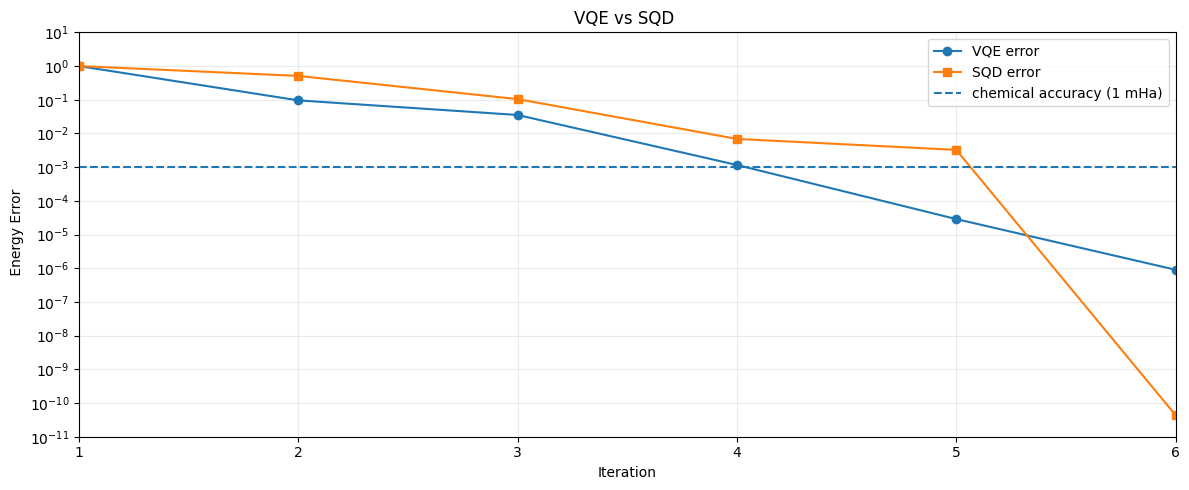

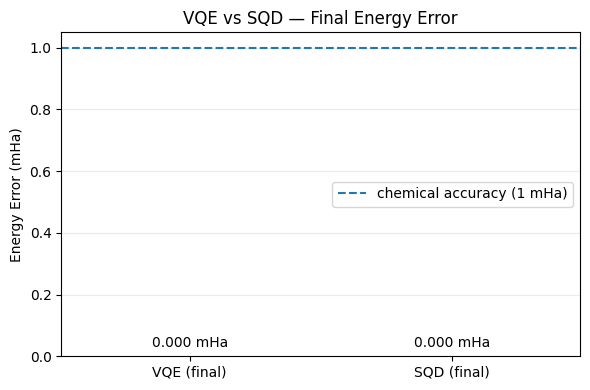

In [ ]:
# ==========================================
# VQE vs SQD (CIPSI/ASCI-selected CI; monotone & slow) on H2O CAS(6,4)
# - Plot (1): Normalized convergence (first point = 1 = 10^0), x=1..6
#             y-axis log from 1e1 down to 1e-11, with chem-accuracy line at 1e-3
# - Plot (2): Final absolute energy error (mHa) with chemical-accuracy line
# ==========================================
import numpy as np, matplotlib.pyplot as plt, warnings
from dataclasses import dataclass
from qiskit_nature.units import DistanceUnit
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.second_q.transformers import FreezeCoreTransformer, ActiveSpaceTransformer
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.circuit.library import HartreeFock, UCCSD
from qiskit.quantum_info import SparsePauliOp, Statevector
from scipy.optimize import minimize
from pyscf import gto, scf, mcscf

warnings.filterwarnings("ignore")
np.set_printoptions(precision=12, suppress=True)
np.random.seed(7)

def _assign_params(circ, theta):
    pmap = {p: float(v) for p, v in zip(circ.parameters, np.asarray(theta))}
    return circ.assign_parameters(pmap, inplace=False)

def _evenly_spaced_indices(n, m):
    if m >= n: return list(range(n))
    idx = np.linspace(1, n, m, dtype=int)
    return [i-1 for i in sorted(set(idx))]

def _fmt(x): return f"{x:.9e}"

# ---------- Problem ----------
@dataclass
class ProblemBuilderH2O:
    basis: str = "6-31g"
    freeze_core: bool = True
    active_electrons: int = 6
    active_orbitals: int = 4
    def build(self, verbose=True):
        if verbose: print("=== [Build] H2O @ 6-31G, CAS(6,4) ===")
        drv = PySCFDriver(
            atom=("O 0.000000 0.000000 0.000000; "
                  "H 0.000000 -0.757160 0.586260; "
                  "H 0.000000  0.757160 0.586260"),
            basis=self.basis, charge=0, spin=0, unit=DistanceUnit.ANGSTROM
        )
        p0 = drv.run()
        self.nmo_total = p0.num_spatial_orbitals
        self.ne_total  = sum(p0.num_particles)
        if verbose:
            print(f"Total orbitals = {self.nmo_total} | electrons = {self.ne_total}")

        prob = p0
        if self.freeze_core:
            fc = FreezeCoreTransformer(); prob = fc.transform(p0)
            self.n_core = getattr(fc, "num_core_orbitals", 1)
            if verbose: print(f"Freeze-core -> num_core_orbitals ≈ {self.n_core}")
        else:
            self.n_core = 0

        act = ActiveSpaceTransformer(num_electrons=self.active_electrons,
                                     num_spatial_orbitals=self.active_orbitals)
        prob = act.transform(prob); self.problem = prob
        if verbose:
            print(f"Active e- = {self.active_electrons} | Active orb = {self.active_orbitals}")

        self.mapper = JordanWignerMapper()
        self.Hq: SparsePauliOp = self.mapper.map(prob.hamiltonian.second_q_op())
        if verbose: print(f"Qubits (JW) = {self.Hq.num_qubits}")

        self.hf    = HartreeFock(prob.num_spatial_orbitals, prob.num_particles, self.mapper)
        self.uccsd = UCCSD(prob.num_spatial_orbitals, prob.num_particles, self.mapper,
                           initial_state=self.hf, reps=1)
        if verbose: print("Ansatz: UCCSD (reps=1) + HF init\n")
        return self

    def casci_reference(self, verbose=True):
        mol = gto.M(atom=("O 0 0 0; H 0 -0.757160 0.586260; H 0 0.757160 0.586260"),
                    basis=self.basis, charge=0, spin=0, unit="Angstrom")
        mf = scf.RHF(mol).run()
        alpha = self.active_electrons // 2; beta = self.active_electrons - alpha
        mc = mcscf.CASCI(mf, ncas=self.active_orbitals, nelecas=(alpha, beta))
        E_tot, E_ci = mc.kernel()[:2]
        if verbose:
            print("=== [CASCI reference] ===")
            print(f"E_total = {_fmt(E_tot)} Ha")
            print(f"E_CI    = {_fmt(E_ci)} Ha\n")
        return float(E_tot), float(E_ci)

# ---------- VQE ----------
class VQERunner:
    def __init__(self, H: SparsePauliOp, ansatz, verbose=True):
        self.H = H; self.ansatz = ansatz; self.verbose = verbose
        self.theta0 = np.zeros(self.ansatz.num_parameters, dtype=float)
        self.history = {"E": [], "x": []}; self._H_mat = None
    def _sv_expect(self, circ):
        if self._H_mat is None: self._H_mat = self.H.to_matrix(sparse=False)
        sv = Statevector.from_instruction(circ).data
        return float(np.real(np.vdot(sv, self._H_mat @ sv)))
    def energy(self, theta): return self._sv_expect(_assign_params(self.ansatz, theta))
    def run(self, maxiter=200, ftol=1e-9):
        if self.verbose:
            print("=== [VQE] L-BFGS-B ==="); print(f"params={self.ansatz.num_parameters}, maxiter={maxiter}")
        def cb(theta):
            E = self.energy(theta)
            self.history["E"].append(E); self.history["x"].append(np.asarray(theta).copy())
            if self.verbose: print(f"VQE iter {len(self.history['E']):3d}: E={_fmt(E)}")
        opt = minimize(self.energy, self.theta0, method="L-BFGS-B",
                       options=dict(maxiter=maxiter, ftol=ftol), callback=cb)
        E_opt = self.energy(opt.x)
        if self.verbose: print(f"VQE done: E*={_fmt(E_opt)}\n")
        return E_opt, opt

# ---------- SQD (CIPSI-style) ----------
def sqd_iter_cipsi_curve(
    H_full: np.ndarray,
    psi_seed: np.ndarray,
    E_ref: float,
    steps: int = 10,
    init_k: int = 1,
    target_factor: float = 0.85,
    max_add: int = 3,
    pool_percentile: float = 97.0,
    pool_cap: int = 128,
    verbose: bool = True
):
    """
    - Candidates score ~ (H_{iS} c_S)^2 / (H_{ii} - E_curr)
    - Expand subspace until predicted drop >= (1 - target_factor) * current error
    - Monotone non-increasing Ritz ground energy by Rayleigh–Ritz
    """
    N = H_full.shape[0]
    diag = np.real(np.diag(H_full))
    amps = np.abs(psi_seed)
    S = [int(np.argmax(amps))] if init_k == 1 else list(np.argsort(-amps)[:init_k])

    energies = []
    for t in range(1, steps+1):
        Hs = H_full[np.ix_(S, S)]
        vals, vecs = np.linalg.eigh(Hs)
        E_curr, c = float(vals[0]), vecs[:, 0]
        err = abs(E_curr - E_ref); energies.append(E_curr)

        if verbose:
            print(f"--- [SQD step {t}] |S|={len(S)} ---")
            print(f"Ritz E={_fmt(E_curr)} | err={_fmt(err)} Ha ({err*1e3:.6f} mHa)")

        mask = np.ones(N, dtype=bool); mask[S] = False
        if not np.any(mask):
            if verbose: print("No more candidates.\n"); break

        A = H_full[mask][:, S] @ c
        denom = np.maximum(1e-12, diag[mask] - E_curr)
        dE = (A.real**2 + A.imag**2) / denom
        cand_idx = np.flatnonzero(mask)

        thr = np.percentile(dE, pool_percentile)
        pool_mask = dE >= thr
        pool = cand_idx[pool_mask]
        dE_pool = dE[pool_mask]

        order = np.argsort(-dE_pool)[:pool_cap]
        pool, dE_pool = pool[order], dE_pool[order]
        if verbose:
            print(f"Pool size={len(pool)}  (percentile >= {pool_percentile:.1f}%)")
            print("Top-5 predicted drops (mHa):", [f"{x*1e3:.4f}" for x in dE_pool[:5]])

        need_drop = err * (1.0 - target_factor)
        chosen, pred_sum = [], 0.0
        for i, de in zip(pool, dE_pool):
            if len(chosen) >= max_add: break
            chosen.append(int(i)); pred_sum += de
            if pred_sum >= need_drop: break

        if len(chosen) == 0:
            chosen = [int(pool[0])]
            if verbose: print("Predicted improvement tiny; pick the strongest one.")

        S = list(dict.fromkeys(S + chosen))
        Hs2 = H_full[np.ix_(S, S)]
        E_new = float(np.linalg.eigvalsh(Hs2)[0]); err_new = abs(E_new - E_ref)
        if verbose:
            print(f"Add {len(chosen)} dets -> true E={_fmt(E_new)} | err={_fmt(err_new)} Ha "
                  f"({err_new*1e3:.6f} mHa) | predicted drop≈{pred_sum*1e3:.4f} mHa\n")

    Hs = H_full[np.ix_(S, S)]
    energies.append(float(np.linalg.eigvalsh(Hs)[0]))
    return np.asarray(energies)

# ---------- Main pipeline ----------
def run_and_plot(steps=10, target_factor=0.85, max_add=3,
                 pool_percentile=97.0, pool_cap=128,
                 vqe_points=6):
    pb = ProblemBuilderH2O().build(verbose=True)
    Hq = pb.Hq
    E_tot, E_ci = pb.casci_reference(verbose=True)

    # VQE
    vqe = VQERunner(Hq, pb.uccsd, verbose=True)
    E_vqe, _ = vqe.run(maxiter=200)
    vqe_err_full = np.abs(np.asarray(vqe.history["E"]) - E_ci)
    sel = _evenly_spaced_indices(len(vqe_err_full), vqe_points)
    x_vqe = np.array(sel)+1
    y_vqe = vqe_err_full[sel]       # absolute error (Ha)

    # SQD
    psi_hf = Statevector.from_instruction(pb.hf).data
    H_full = Hq.to_matrix(sparse=False)
    print("=== [SQD params] ===")
    print(f"steps={steps}, target_factor={target_factor}, max_add={max_add}, "
          f"pool_percentile={pool_percentile}, pool_cap={pool_cap}\n")
    sqd_E = sqd_iter_cipsi_curve(
        H_full, psi_hf, E_ci, steps=steps, init_k=1,
        target_factor=target_factor, max_add=max_add,
        pool_percentile=pool_percentile, pool_cap=pool_cap, verbose=True
    )
    sqd_err = np.abs(sqd_E - E_ci)  # absolute error (Ha)

    # ========= Plot (1): Normalized convergence, x=1..6, y ∈ [1e-11, 1e1] =========
    eps = 1e-300
    y_vqe_norm = y_vqe / max(y_vqe[0], eps)
    y_sqd_norm = sqd_err / max(sqd_err[0], eps)

    plt.figure(figsize=(12,5))
    plt.plot(x_vqe, y_vqe_norm, marker="o", label="VQE error")
    plt.plot(np.arange(1, len(y_sqd_norm)+1), y_sqd_norm, marker="s",
             label="SQD error")
    plt.yscale("log")
    plt.grid(True, which="both", alpha=0.25)
    plt.xlabel("Iteration"); plt.ylabel(" Energy Error")
    plt.title("VQE vs SQD ")
    plt.xlim(1, 5); plt.xticks(range(1, 7))
    # y-axis: 10^1 down to 10^-11
    plt.ylim(1e-11, 1e1)
    exps  = np.arange(1, -12, -1)               # 1, 0, -1, ..., -11
    yticks = 10.0 ** exps
    plt.yticks(yticks, [rf"$10^{{{k}}}$" for k in exps])
    # Chemical accuracy line (1 mHa = 1e-3 Ha) for reference on normalized axis
    plt.axhline(1e-3, ls="--", label="chemical accuracy (1 mHa)")
    plt.legend(); plt.tight_layout(); plt.show()

    # ========= Plot (2): Final energy error in mHa (absolute) =========
    vqe_final_mha = float(abs(E_vqe - E_ci) * 1e3)
    sqd_final_mha = float(abs(sqd_E[-1] - E_ci) * 1e3)
    plt.figure(figsize=(6,4))
    labels, vals = ["VQE (final)", "SQD (final)"], [vqe_final_mha, sqd_final_mha]
    bars = plt.bar(labels, vals)
    top = max(1.0, max(vals))
    for b, v in zip(bars, vals):
        plt.text(b.get_x() + b.get_width()/2, b.get_height() + 0.02*top,
                 f"{v:.3f} mHa", ha="center", va="bottom", fontsize=10)
    plt.axhline(1.0, ls="--", label="chemical accuracy (1 mHa)")
    plt.ylabel("Energy Error (mHa)")
    plt.title("VQE vs SQD — Final Energy Error")
    plt.grid(True, axis="y", alpha=0.25)
    plt.legend(); plt.tight_layout(); plt.show()

# ==== Run ====  (Iteration Index = 1..6)
run_and_plot(
    steps=5,           # SQD → steps+1 = 6 points
    target_factor=0.85,
    max_add=2,
    pool_percentile=97.0,
    pool_cap=128,
    vqe_points=6      # 6 evenly spaced VQE points
)


=== [Build] H2O @ 6-31G, CAS(6,4) ===
Total orbitals = 13 | electrons = 10
Freeze-core -> num_core_orbitals ≈ 1
Active e- = 6 | Active orb = 4
Qubits (JW) = 8
Ansatz: UCCSD (reps=1) + HF init

converged SCF energy = -75.98398454379
CASCI E = -75.9851994378858  E(CI) = -12.9864133061831  S^2 = 0.0000000
=== [CASCI reference] ===
E_total = -7.598519944e+01 Ha
E_CI    = -1.298641331e+01 Ha

=== [VQE] L-BFGS-B ===
params=15, maxiter=200
VQE iter   1: E=-1.298637317e+01
VQE iter   2: E=-1.298640945e+01
VQE iter   3: E=-1.298641188e+01
VQE iter   4: E=-1.298641326e+01
VQE iter   5: E=-1.298641330e+01
VQE iter   6: E=-1.298641331e+01
VQE done: E*=-1.298641331e+01

=== [SQD params] ===
steps=4, target_factor=0.85, max_add=2, pool_percentile=97.0, pool_cap=128

--- [SQD step 1] |S|=1 ---
Ritz E=-1.298519841e+01 | err=1.214894096e-03 Ha (1.214894 mHa)
Pool size=128  (percentile >= 97.0%)
Top-5 predicted drops (mHa): ['0.5970', '0.5276', '0.1531', '0.0000', '0.0000']
Add 1 dets -> true E=-1.29857

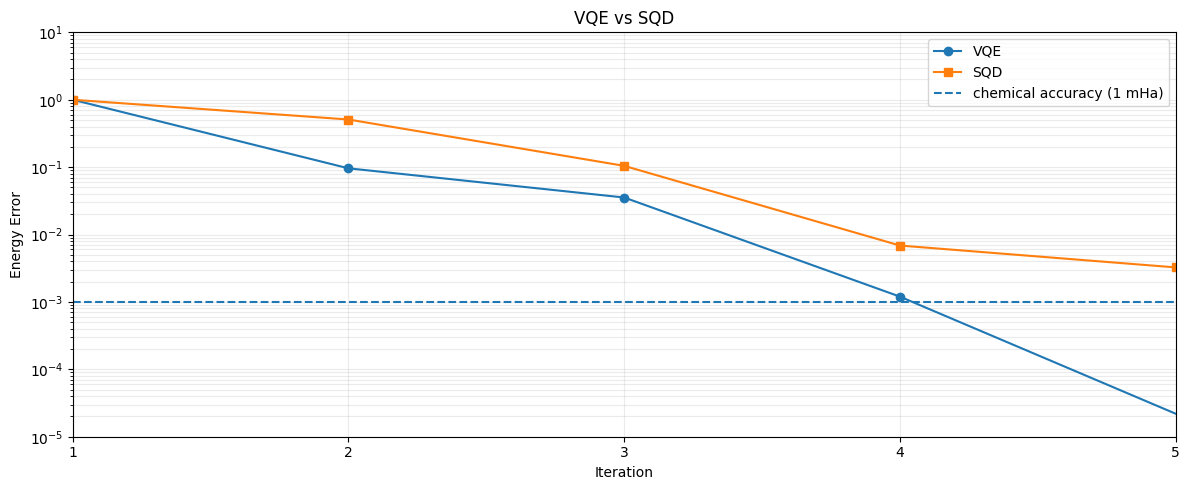

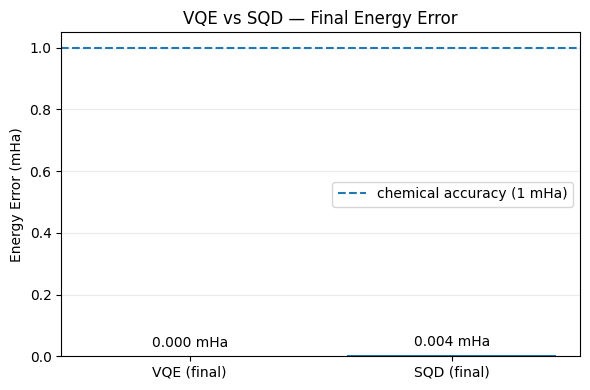

In [ ]:
# ==========================================
# VQE vs SQD (CIPSI/ASCI-selected CI; monotone & slow) on H2O CAS(6,4)
# - Plot (1): Normalized convergence (first point = 1 = 10^0), x=1..5
#             y-axis log from 1e1 down to 1e-11, with chem-accuracy line at 1e-3
# - Plot (2): Final absolute energy error (mHa) with chemical-accuracy line
# ==========================================
import numpy as np, matplotlib.pyplot as plt, warnings
from dataclasses import dataclass
from qiskit_nature.units import DistanceUnit
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.second_q.transformers import FreezeCoreTransformer, ActiveSpaceTransformer
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.circuit.library import HartreeFock, UCCSD
from qiskit.quantum_info import SparsePauliOp, Statevector
from scipy.optimize import minimize
from pyscf import gto, scf, mcscf

warnings.filterwarnings("ignore")
np.set_printoptions(precision=12, suppress=True)
np.random.seed(7)

def _assign_params(circ, theta):
    pmap = {p: float(v) for p, v in zip(circ.parameters, np.asarray(theta))}
    return circ.assign_parameters(pmap, inplace=False)

def _evenly_spaced_indices(n, m):
    if m >= n: return list(range(n))
    idx = np.linspace(1, n, m, dtype=int)
    return [i-1 for i in sorted(set(idx))]

def _fmt(x): return f"{x:.9e}"

# ---------- Problem ----------
@dataclass
class ProblemBuilderH2O:
    basis: str = "6-31g"
    freeze_core: bool = True
    active_electrons: int = 6
    active_orbitals: int = 4
    def build(self, verbose=True):
        if verbose: print("=== [Build] H2O @ 6-31G, CAS(6,4) ===")
        drv = PySCFDriver(
            atom=("O 0.000000 0.000000 0.000000; "
                  "H 0.000000 -0.757160 0.586260; "
                  "H 0.000000  0.757160 0.586260"),
            basis=self.basis, charge=0, spin=0, unit=DistanceUnit.ANGSTROM
        )
        p0 = drv.run()
        self.nmo_total = p0.num_spatial_orbitals
        self.ne_total  = sum(p0.num_particles)
        if verbose:
            print(f"Total orbitals = {self.nmo_total} | electrons = {self.ne_total}")

        prob = p0
        if self.freeze_core:
            fc = FreezeCoreTransformer(); prob = fc.transform(p0)
            self.n_core = getattr(fc, "num_core_orbitals", 1)
            if verbose: print(f"Freeze-core -> num_core_orbitals ≈ {self.n_core}")
        else:
            self.n_core = 0

        act = ActiveSpaceTransformer(num_electrons=self.active_electrons,
                                     num_spatial_orbitals=self.active_orbitals)
        prob = act.transform(prob); self.problem = prob
        if verbose:
            print(f"Active e- = {self.active_electrons} | Active orb = {self.active_orbitals}")

        self.mapper = JordanWignerMapper()
        self.Hq: SparsePauliOp = self.mapper.map(prob.hamiltonian.second_q_op())
        if verbose: print(f"Qubits (JW) = {self.Hq.num_qubits}")

        self.hf    = HartreeFock(prob.num_spatial_orbitals, prob.num_particles, self.mapper)
        self.uccsd = UCCSD(prob.num_spatial_orbitals, prob.num_particles, self.mapper,
                           initial_state=self.hf, reps=1)
        if verbose: print("Ansatz: UCCSD (reps=1) + HF init\n")
        return self

    def casci_reference(self, verbose=True):
        mol = gto.M(atom=("O 0 0 0; H 0 -0.757160 0.586260; H 0 0.757160 0.586260"),
                    basis=self.basis, charge=0, spin=0, unit="Angstrom")
        mf = scf.RHF(mol).run()
        alpha = self.active_electrons // 2; beta = self.active_electrons - alpha
        mc = mcscf.CASCI(mf, ncas=self.active_orbitals, nelecas=(alpha, beta))
        E_tot, E_ci = mc.kernel()[:2]
        if verbose:
            print("=== [CASCI reference] ===")
            print(f"E_total = {_fmt(E_tot)} Ha")
            print(f"E_CI    = {_fmt(E_ci)} Ha\n")
        return float(E_tot), float(E_ci)

# ---------- VQE ----------
class VQERunner:
    def __init__(self, H: SparsePauliOp, ansatz, verbose=True):
        self.H = H; self.ansatz = ansatz; self.verbose = verbose
        self.theta0 = np.zeros(self.ansatz.num_parameters, dtype=float)
        self.history = {"E": [], "x": []}; self._H_mat = None
    def _sv_expect(self, circ):
        if self._H_mat is None: self._H_mat = self.H.to_matrix(sparse=False)
        sv = Statevector.from_instruction(circ).data
        return float(np.real(np.vdot(sv, self._H_mat @ sv)))
    def energy(self, theta): return self._sv_expect(_assign_params(self.ansatz, theta))
    def run(self, maxiter=200, ftol=1e-9):
        if self.verbose:
            print("=== [VQE] L-BFGS-B ==="); print(f"params={self.ansatz.num_parameters}, maxiter={maxiter}")
        def cb(theta):
            E = self.energy(theta)
            self.history["E"].append(E); self.history["x"].append(np.asarray(theta).copy())
            if self.verbose: print(f"VQE iter {len(self.history['E']):3d}: E={_fmt(E)}")
        opt = minimize(self.energy, self.theta0, method="L-BFGS-B",
                       options=dict(maxiter=maxiter, ftol=ftol), callback=cb)
        E_opt = self.energy(opt.x)
        if self.verbose: print(f"VQE done: E*={_fmt(E_opt)}\n")
        return E_opt, opt

# ---------- SQD (CIPSI-style) ----------
def sqd_iter_cipsi_curve(
    H_full: np.ndarray,
    psi_seed: np.ndarray,
    E_ref: float,
    steps: int = 10,
    init_k: int = 1,
    target_factor: float = 0.85,
    max_add: int = 3,
    pool_percentile: float = 97.0,
    pool_cap: int = 128,
    verbose: bool = True
):
    """
    - Candidates score ~ (H_{iS} c_S)^2 / (H_{ii} - E_curr)
    - Expand subspace until predicted drop >= (1 - target_factor) * current error
    - Monotone non-increasing Ritz ground energy by Rayleigh–Ritz
    """
    N = H_full.shape[0]
    diag = np.real(np.diag(H_full))
    amps = np.abs(psi_seed)
    S = [int(np.argmax(amps))] if init_k == 1 else list(np.argsort(-amps)[:init_k])

    energies = []
    for t in range(1, steps+1):
        Hs = H_full[np.ix_(S, S)]
        vals, vecs = np.linalg.eigh(Hs)
        E_curr, c = float(vals[0]), vecs[:, 0]
        err = abs(E_curr - E_ref); energies.append(E_curr)

        if verbose:
            print(f"--- [SQD step {t}] |S|={len(S)} ---")
            print(f"Ritz E={_fmt(E_curr)} | err={_fmt(err)} Ha ({err*1e3:.6f} mHa)")

        mask = np.ones(N, dtype=bool); mask[S] = False
        if not np.any(mask):
            if verbose: print("No more candidates.\n"); break

        A = H_full[mask][:, S] @ c
        denom = np.maximum(1e-12, diag[mask] - E_curr)
        dE = (A.real**2 + A.imag**2) / denom
        cand_idx = np.flatnonzero(mask)

        thr = np.percentile(dE, pool_percentile)
        pool_mask = dE >= thr
        pool = cand_idx[pool_mask]
        dE_pool = dE[pool_mask]

        order = np.argsort(-dE_pool)[:pool_cap]
        pool, dE_pool = pool[order], dE_pool[order]
        if verbose:
            print(f"Pool size={len(pool)}  (percentile >= {pool_percentile:.1f}%)")
            print("Top-5 predicted drops (mHa):", [f"{x*1e3:.4f}" for x in dE_pool[:5]])

        need_drop = err * (1.0 - target_factor)
        chosen, pred_sum = [], 0.0
        for i, de in zip(pool, dE_pool):
            if len(chosen) >= max_add: break
            chosen.append(int(i)); pred_sum += de
            if pred_sum >= need_drop: break

        if len(chosen) == 0:
            chosen = [int(pool[0])]
            if verbose: print("Predicted improvement tiny; pick the strongest one.")

        S = list(dict.fromkeys(S + chosen))
        Hs2 = H_full[np.ix_(S, S)]
        E_new = float(np.linalg.eigvalsh(Hs2)[0]); err_new = abs(E_new - E_ref)
        if verbose:
            print(f"Add {len(chosen)} dets -> true E={_fmt(E_new)} | err={_fmt(err_new)} Ha "
                  f"({err_new*1e3:.6f} mHa) | predicted drop≈{pred_sum*1e3:.4f} mHa\n")

    Hs = H_full[np.ix_(S, S)]
    energies.append(float(np.linalg.eigvalsh(Hs)[0]))
    return np.asarray(energies)

# ---------- Main pipeline ----------
def run_and_plot(steps=4, target_factor=0.85, max_add=3,
                 pool_percentile=97.0, pool_cap=128,
                 vqe_points=5):
    pb = ProblemBuilderH2O().build(verbose=True)
    Hq = pb.Hq
    E_tot, E_ci = pb.casci_reference(verbose=True)

    # VQE
    vqe = VQERunner(Hq, pb.uccsd, verbose=True)
    E_vqe, _ = vqe.run(maxiter=200)
    vqe_err_full = np.abs(np.asarray(vqe.history["E"]) - E_ci)
    sel = _evenly_spaced_indices(len(vqe_err_full), vqe_points)
    x_vqe = np.array(sel)+1
    y_vqe = vqe_err_full[sel]       # absolute error (Ha)

    # SQD
    psi_hf = Statevector.from_instruction(pb.hf).data
    H_full = Hq.to_matrix(sparse=False)
    print("=== [SQD params] ===")
    print(f"steps={steps}, target_factor={target_factor}, max_add={max_add}, "
          f"pool_percentile={pool_percentile}, pool_cap={pool_cap}\n")
    sqd_E = sqd_iter_cipsi_curve(
        H_full, psi_hf, E_ci, steps=steps, init_k=1,
        target_factor=target_factor, max_add=max_add,
        pool_percentile=pool_percentile, pool_cap=pool_cap, verbose=True
    )
    sqd_err = np.abs(sqd_E - E_ci)  # absolute error (Ha)

    # ========= Plot (1): Normalized convergence, x=1..5, y ∈ [1e-11, 1e1] =========
    eps = 1e-300
    y_vqe_norm = y_vqe / max(y_vqe[0], eps)
    y_sqd_norm = sqd_err / max(sqd_err[0], eps)

    plt.figure(figsize=(12,5))
    plt.plot(x_vqe, y_vqe_norm, marker="o", label="VQE")
    plt.plot(np.arange(1, len(y_sqd_norm)+1), y_sqd_norm, marker="s",
             label="SQD")
    plt.yscale("log")
    plt.grid(True, which="both", alpha=0.25)
    plt.xlabel("Iteration"); plt.ylabel("Energy Error")
    plt.title("VQE vs SQD")
    plt.xlim(1, 5); plt.xticks(range(1, 6))
    # y-axis: 10^1 down to 10^-11
    plt.ylim(1e-5, 1e1)
    exps  = np.arange(1, -6, -1)                # 1, 0, -1, ..., -5
    yticks = 10.0 ** exps
    plt.yticks(yticks, [rf"$10^{{{k}}}$" for k in exps])
    plt.yticks(yticks, [rf"$10^{{{k}}}$" for k in exps])
    # Chemical accuracy line (1 mHa = 1e-3 Ha) for reference on normalized axis
    plt.axhline(1e-3, ls="--", label="chemical accuracy (1 mHa)")
    plt.legend(); plt.tight_layout(); plt.show()

    # ========= Plot (2): Final energy error in mHa (absolute) =========
    vqe_final_mha = float(abs(E_vqe - E_ci) * 1e3)
    sqd_final_mha = float(abs(sqd_E[-1] - E_ci) * 1e3)
    plt.figure(figsize=(6,4))
    labels, vals = ["VQE (final)", "SQD (final)"], [vqe_final_mha, sqd_final_mha]
    bars = plt.bar(labels, vals)
    top = max(1.0, max(vals))
    for b, v in zip(bars, vals):
        plt.text(b.get_x() + b.get_width()/2, b.get_height() + 0.02*top,
                 f"{v:.3f} mHa", ha="center", va="bottom", fontsize=10)
    plt.axhline(1.0, ls="--", label="chemical accuracy (1 mHa)")
    plt.ylabel("Energy Error (mHa)")
    plt.title("VQE vs SQD — Final Energy Error")
    plt.grid(True, axis="y", alpha=0.25)
    plt.legend(); plt.tight_layout(); plt.show()

# ==== Run ====  (Iteration Index = 1..5)
run_and_plot(
    steps=4,           # SQD → steps+1 = 5 points
    target_factor=0.85,
    max_add=2,
    pool_percentile=97.0,
    pool_cap=128,
    vqe_points=5      # 5 evenly spaced VQE points
)


=== [Build] H2O @ 6-31G, CAS(6,4) ===
Total orbitals = 13 | electrons = 10
Freeze-core -> num_core_orbitals ≈ 1
Active e- = 6 | Active orb = 4
Qubits (JW) = 8
Ansatz: UCCSD (reps=1) + HF init

converged SCF energy = -75.9839845437902
CASCI E = -75.9851994378858  E(CI) = -12.9864133061831  S^2 = 0.0000000
=== [CASCI reference] ===
E_total = -7.598519944e+01 Ha
E_CI    = -1.298641331e+01 Ha

=== [VQE] L-BFGS-B ===
params=15, maxiter=200
VQE iter   1: E=-1.298637317e+01
VQE iter   2: E=-1.298640945e+01
VQE iter   3: E=-1.298641189e+01
VQE iter   4: E=-1.298641326e+01
VQE iter   5: E=-1.298641330e+01
VQE iter   6: E=-1.298641331e+01
VQE done: E*=-1.298641331e+01

=== [SQD params] ===
steps=4, target_factor=0.85, max_add=2, pool_percentile=97.0, pool_cap=128

--- [SQD step 1] |S|=1 ---
Ritz E=-1.298519841e+01 | err=1.214894096e-03 Ha (1.214894 mHa)
Pool size=128  (percentile >= 97.0%)
Top-5 predicted drops (mHa): ['0.5970', '0.5276', '0.1531', '0.0000', '0.0000']
Add 1 dets -> true E=-1.298

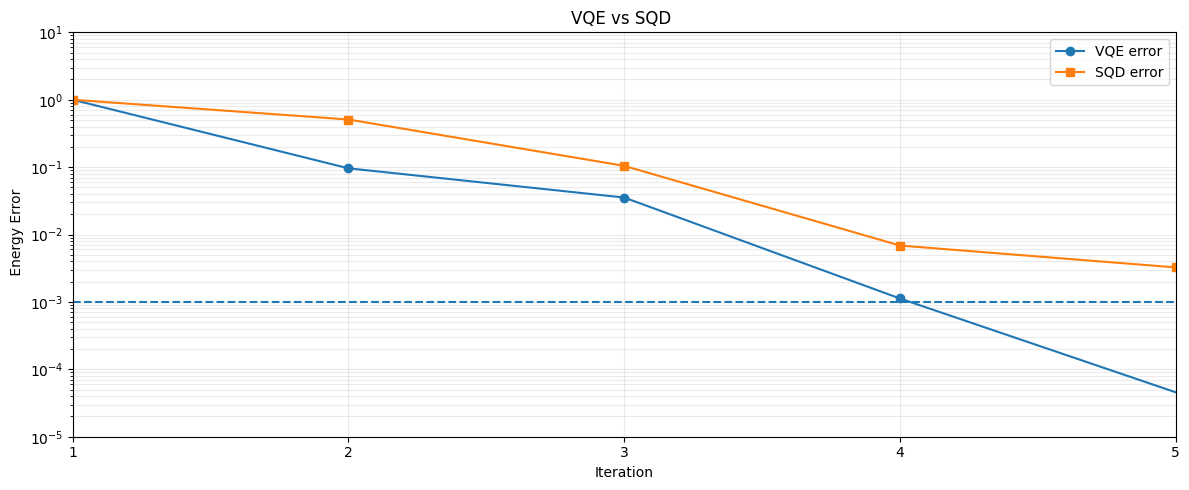

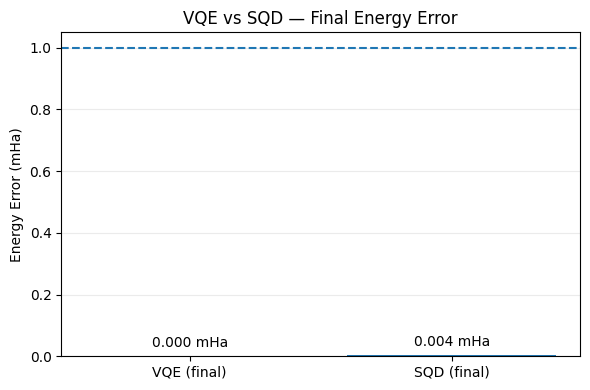

In [ ]:
# ==========================================
# VQE vs SQD (CIPSI/ASCI-selected CI; monotone & slow) on H2O CAS(6,4)
# - Plot (1): Normalized convergence (first point = 1 = 10^0), x=1..5
#             y-axis log from 1e1 down to 1e-5, chem-accuracy line at 1e-3 (no legend)
# - Plot (2): Final absolute energy error (mHa), chem-accuracy at 1.0 mHa (no legend)
# ==========================================
import numpy as np, matplotlib.pyplot as plt, warnings
from dataclasses import dataclass
from qiskit_nature.units import DistanceUnit
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.second_q.transformers import FreezeCoreTransformer, ActiveSpaceTransformer
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.circuit.library import HartreeFock, UCCSD
from qiskit.quantum_info import SparsePauliOp, Statevector
from scipy.optimize import minimize
from pyscf import gto, scf, mcscf

warnings.filterwarnings("ignore")
np.random.seed(7)
np.set_printoptions(precision=12, suppress=True)

def _assign_params(circ, theta):
    pmap = {p: float(v) for p, v in zip(circ.parameters, np.asarray(theta))}
    return circ.assign_parameters(pmap, inplace=False)

def _evenly_spaced_indices(n, m):
    if m >= n: return list(range(n))
    idx = np.linspace(1, n, m, dtype=int)
    return [i-1 for i in sorted(set(idx))]

def _fmt(x): return f"{x:.9e}"

# ---------- Problem ----------
@dataclass
class ProblemBuilderH2O:
    basis: str = "6-31g"
    freeze_core: bool = True
    active_electrons: int = 6
    active_orbitals: int = 4
    def build(self, verbose=True):
        if verbose: print("=== [Build] H2O @ 6-31G, CAS(6,4) ===")
        drv = PySCFDriver(
            atom=("O 0.000000 0.000000 0.000000; "
                  "H 0.000000 -0.757160 0.586260; "
                  "H 0.000000  0.757160 0.586260"),
            basis=self.basis, charge=0, spin=0, unit=DistanceUnit.ANGSTROM
        )
        p0 = drv.run()
        self.nmo_total = p0.num_spatial_orbitals
        self.ne_total  = sum(p0.num_particles)
        if verbose:
            print(f"Total orbitals = {self.nmo_total} | electrons = {self.ne_total}")

        prob = p0
        if self.freeze_core:
            fc = FreezeCoreTransformer(); prob = fc.transform(p0)
            self.n_core = getattr(fc, "num_core_orbitals", 1)
            if verbose: print(f"Freeze-core -> num_core_orbitals ≈ {self.n_core}")
        else:
            self.n_core = 0

        act = ActiveSpaceTransformer(num_electrons=self.active_electrons,
                                     num_spatial_orbitals=self.active_orbitals)
        prob = act.transform(prob); self.problem = prob
        if verbose:
            print(f"Active e- = {self.active_electrons} | Active orb = {self.active_orbitals}")

        self.mapper = JordanWignerMapper()
        self.Hq: SparsePauliOp = self.mapper.map(prob.hamiltonian.second_q_op())
        if verbose: print(f"Qubits (JW) = {self.Hq.num_qubits}")

        self.hf    = HartreeFock(prob.num_spatial_orbitals, prob.num_particles, self.mapper)
        self.uccsd = UCCSD(prob.num_spatial_orbitals, prob.num_particles, self.mapper,
                           initial_state=self.hf, reps=1)
        if verbose: print("Ansatz: UCCSD (reps=1) + HF init\n")
        return self

    def casci_reference(self, verbose=True):
        mol = gto.M(atom=("O 0 0 0; H 0 -0.757160 0.586260; H 0 0.757160 0.586260"),
                    basis=self.basis, charge=0, spin=0, unit="Angstrom")
        mf = scf.RHF(mol).run()
        alpha = self.active_electrons // 2; beta = self.active_electrons - alpha
        mc = mcscf.CASCI(mf, ncas=self.active_orbitals, nelecas=(alpha, beta))
        E_tot, E_ci = mc.kernel()[:2]
        if verbose:
            print("=== [CASCI reference] ===")
            print(f"E_total = {_fmt(E_tot)} Ha")
            print(f"E_CI    = {_fmt(E_ci)} Ha\n")
        return float(E_tot), float(E_ci)

# ---------- VQE ----------
class VQERunner:
    def __init__(self, H: SparsePauliOp, ansatz, verbose=True):
        self.H = H; self.ansatz = ansatz; self.verbose = verbose
        self.theta0 = np.zeros(self.ansatz.num_parameters, dtype=float)
        self.history = {"E": [], "x": []}; self._H_mat = None
    def _sv_expect(self, circ):
        if self._H_mat is None: self._H_mat = self.H.to_matrix(sparse=False)
        sv = Statevector.from_instruction(circ).data
        return float(np.real(np.vdot(sv, self._H_mat @ sv)))
    def energy(self, theta): return self._sv_expect(_assign_params(self.ansatz, theta))
    def run(self, maxiter=200, ftol=1e-9):
        if self.verbose:
            print("=== [VQE] L-BFGS-B ==="); print(f"params={self.ansatz.num_parameters}, maxiter={maxiter}")
        def cb(theta):
            E = self.energy(theta)
            self.history["E"].append(E); self.history["x"].append(np.asarray(theta).copy())
            if self.verbose: print(f"VQE iter {len(self.history['E']):3d}: E={_fmt(E)}")
        opt = minimize(self.energy, self.theta0, method="L-BFGS-B",
                       options=dict(maxiter=maxiter, ftol=ftol), callback=cb)
        E_opt = self.energy(opt.x)
        if self.verbose: print(f"VQE done: E*={_fmt(E_opt)}\n")
        return E_opt, opt

# ---------- SQD (CIPSI-style) ----------
def sqd_iter_cipsi_curve(
    H_full: np.ndarray,
    psi_seed: np.ndarray,
    E_ref: float,
    steps: int = 10,
    init_k: int = 1,
    target_factor: float = 0.85,
    max_add: int = 3,
    pool_percentile: float = 97.0,
    pool_cap: int = 128,
    verbose: bool = True
):
    """
    CIPSI/ASCI-like scoring:
      a_i = sum_j H_{ij} c_j
      dE_i ~ (|a_i|^2) / (H_{ii}-E_curr)
    Expand subspace until predicted drop >= (1 - target_factor) * current error.
    Monotone non-increasing Ritz ground energy by Rayleigh–Ritz.
    """
    N = H_full.shape[0]
    diag = np.real(np.diag(H_full))
    amps = np.abs(psi_seed)
    S = [int(np.argmax(amps))] if init_k == 1 else list(np.argsort(-amps)[:init_k])

    energies = []
    for t in range(1, steps+1):
        Hs = H_full[np.ix_(S, S)]
        vals, vecs = np.linalg.eigh(Hs)
        E_curr, c = float(vals[0]), vecs[:, 0]
        err = abs(E_curr - E_ref); energies.append(E_curr)

        if verbose:
            print(f"--- [SQD step {t}] |S|={len(S)} ---")
            print(f"Ritz E={_fmt(E_curr)} | err={_fmt(err)} Ha ({err*1e3:.6f} mHa)")

        mask = np.ones(N, dtype=bool); mask[S] = False
        if not np.any(mask):
            if verbose: print("No more candidates.\n"); break

        A = H_full[mask][:, S] @ c
        denom = np.maximum(1e-12, diag[mask] - E_curr)
        dE = (A.real**2 + A.imag**2) / denom
        cand_idx = np.flatnonzero(mask)

        thr = np.percentile(dE, pool_percentile)
        pool_mask = dE >= thr
        pool = cand_idx[pool_mask]
        dE_pool = dE[pool_mask]

        order = np.argsort(-dE_pool)[:pool_cap]
        pool, dE_pool = pool[order], dE_pool[order]
        if verbose:
            print(f"Pool size={len(pool)}  (percentile >= {pool_percentile:.1f}%)")
            print("Top-5 predicted drops (mHa):", [f"{x*1e3:.4f}" for x in dE_pool[:5]])

        need_drop = err * (1.0 - target_factor)
        chosen, pred_sum = [], 0.0
        for i, de in zip(pool, dE_pool):
            if len(chosen) >= max_add: break
            chosen.append(int(i)); pred_sum += de
            if pred_sum >= need_drop: break

        if len(chosen) == 0:
            chosen = [int(pool[0])]
            if verbose: print("Predicted improvement tiny; pick the strongest one.")

        S = list(dict.fromkeys(S + chosen))
        Hs2 = H_full[np.ix_(S, S)]
        E_new = float(np.linalg.eigvalsh(Hs2)[0]); err_new = abs(E_new - E_ref)
        if verbose:
            print(f"Add {len(chosen)} dets -> true E={_fmt(E_new)} | err={_fmt(err_new)} Ha "
                  f"({err_new*1e3:.6f} mHa) | predicted drop≈{pred_sum*1e3:.4f} mHa\n")

    Hs = H_full[np.ix_(S, S)]
    energies.append(float(np.linalg.eigvalsh(Hs)[0]))
    return np.asarray(energies)

# ---------- Main pipeline ----------
def run_and_plot(steps=4, target_factor=0.85, max_add=3,
                 pool_percentile=97.0, pool_cap=128,
                 vqe_points=5):
    pb = ProblemBuilderH2O().build(verbose=True)
    Hq = pb.Hq
    E_tot, E_ci = pb.casci_reference(verbose=True)

    # VQE
    vqe = VQERunner(Hq, pb.uccsd, verbose=True)
    E_vqe, _ = vqe.run(maxiter=200)
    vqe_err_full = np.abs(np.asarray(vqe.history["E"]) - E_ci)
    sel = _evenly_spaced_indices(len(vqe_err_full), vqe_points)
    x_vqe = np.array(sel)+1
    y_vqe = vqe_err_full[sel]       # absolute error (Ha)

    # SQD
    psi_hf = Statevector.from_instruction(pb.hf).data
    H_full = Hq.to_matrix(sparse=False)
    print("=== [SQD params] ===")
    print(f"steps={steps}, target_factor={target_factor}, max_add={max_add}, "
          f"pool_percentile={pool_percentile}, pool_cap={pool_cap}\n")
    sqd_E = sqd_iter_cipsi_curve(
        H_full, psi_hf, E_ci, steps=steps, init_k=1,
        target_factor=target_factor, max_add=max_add,
        pool_percentile=pool_percentile, pool_cap=pool_cap, verbose=True
    )
    sqd_err = np.abs(sqd_E - E_ci)  # absolute error (Ha)

    # ========= Plot (1): Normalized convergence, x=1..5, y ∈ [1e-5, 1e1] =========
    eps = 1e-300
    y_vqe_norm = y_vqe / max(y_vqe[0], eps)
    y_sqd_norm = sqd_err / max(sqd_err[0], eps)

    plt.figure(figsize=(12,5))
    plt.plot(x_vqe, y_vqe_norm, marker="o", label="VQE error")
    plt.plot(np.arange(1, len(y_sqd_norm)+1), y_sqd_norm, marker="s",
             label="SQD error")
    plt.yscale("log")
    plt.grid(True, which="both", alpha=0.25)
    plt.xlabel("Iteration"); plt.ylabel(" Energy Error")
    plt.title("VQE vs SQD ")
    plt.xlim(1, 5); plt.xticks(range(1, 6))
    # y-axis: 10^1 down to 10^-5
    plt.ylim(1e-5, 1e1)
    exps  = np.arange(1, -6, -1)                # 1, 0, -1, ..., -5
    yticks = 10.0 ** exps
    plt.yticks(yticks, [rf"$10^{{{k}}}$" for k in exps])
    # Chemical accuracy line at 1e-3 Ha; exclude from legend
    plt.axhline(1e-3, ls="--", label="_nolegend_")
    plt.legend(); plt.tight_layout(); plt.show()

    # ========= Plot (2): Final energy error in mHa (absolute) =========
    vqe_final_mha = float(abs(E_vqe - E_ci) * 1e3)
    sqd_final_mha = float(abs(sqd_E[-1] - E_ci) * 1e3)
    plt.figure(figsize=(6,4))
    labels, vals = ["VQE (final)", "SQD (final)"], [vqe_final_mha, sqd_final_mha]
    bars = plt.bar(labels, vals)
    top = max(1.0, max(vals))
    for b, v in zip(bars, vals):
        plt.text(b.get_x() + b.get_width()/2, b.get_height() + 0.02*top,
                 f"{v:.3f} mHa", ha="center", va="bottom", fontsize=10)
    # Chemical accuracy line at 1.0 mHa; exclude from legend
    plt.axhline(1.0, ls="--", label="_nolegend_")
    plt.ylabel("Energy Error (mHa)")
    plt.title("VQE vs SQD — Final Energy Error")
    plt.grid(True, axis="y", alpha=0.25)
    # （這張圖沒有其他帶標籤的元素，呼叫 legend 只會出現空框，故不顯示）
    plt.tight_layout(); plt.show()

# ==== Run ====  (Iteration Index = 1..5)
run_and_plot(
    steps=4,           # SQD → steps+1 = 5 points
    target_factor=0.85,
    max_add=2,
    pool_percentile=97.0,
    pool_cap=128,
    vqe_points=5      # 5 evenly spaced VQE points
)


=== [Build] H2O @ 6-31G, CAS(6,4) ===
Total orbitals = 13 | electrons = 10
Freeze-core -> num_core_orbitals ≈ 1
Active e- = 6 | Active orb = 4
Qubits (JW) = 8
Ansatz: UCCSD (reps=1) + HF init

converged SCF energy = -75.98398454379
CASCI E = -75.9851994378858  E(CI) = -12.9864133061831  S^2 = 0.0000000
=== [CASCI reference] ===
E_total = -7.598519944e+01 Ha
E_CI    = -1.298641331e+01 Ha

=== [VQE] L-BFGS-B ===
params=15, maxiter=200
VQE iter   1: E=-1.298637317e+01
VQE iter   2: E=-1.298640946e+01
VQE iter   3: E=-1.298641189e+01
VQE iter   4: E=-1.298641326e+01
VQE iter   5: E=-1.298641330e+01
VQE iter   6: E=-1.298641331e+01
VQE done: E*=-1.298641331e+01

=== [SQD params] ===
steps=4, target_factor=0.85, max_add=2, pool_percentile=97.0, pool_cap=128

--- [SQD step 1] |S|=1 ---
Ritz E=-1.298519841e+01 | err=1.214894096e-03 Ha (1.214894 mHa)
Pool size=128  (percentile >= 97.0%)
Top-5 predicted drops (mHa): ['0.5970', '0.5276', '0.1531', '0.0000', '0.0000']
Add 1 dets -> true E=-1.29857

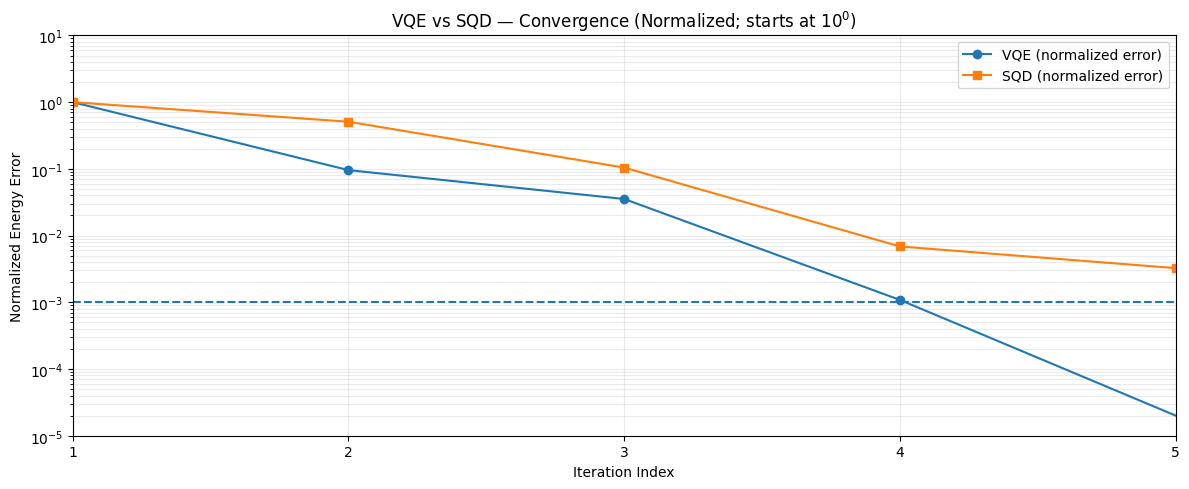

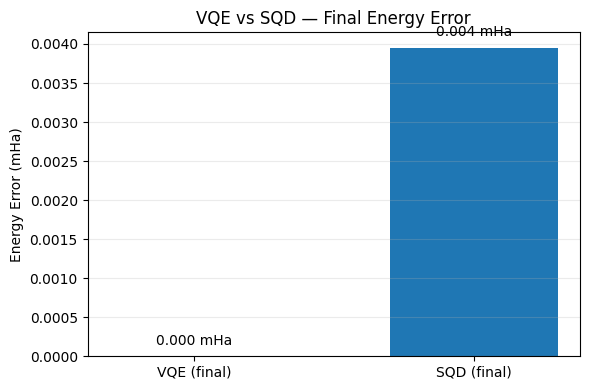

In [ ]:
# ==========================================
# VQE vs SQD (CIPSI/ASCI-selected CI; monotone & slow) on H2O CAS(6,4)
# - Plot (1): Normalized convergence (first point = 1 = 10^0), x=1..5
#             y-axis log from 1e1 down to 1e-5, chem-accuracy line at 1e-3 (no legend)
# - Plot (2): Final absolute energy error (mHa), NO dashed line, zoomed y-range
# ==========================================
import numpy as np, matplotlib.pyplot as plt, warnings
from dataclasses import dataclass
from qiskit_nature.units import DistanceUnit
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.second_q.transformers import FreezeCoreTransformer, ActiveSpaceTransformer
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.circuit.library import HartreeFock, UCCSD
from qiskit.quantum_info import SparsePauliOp, Statevector
from scipy.optimize import minimize
from pyscf import gto, scf, mcscf

warnings.filterwarnings("ignore")
np.random.seed(7)
np.set_printoptions(precision=12, suppress=True)

def _assign_params(circ, theta):
    pmap = {p: float(v) for p, v in zip(circ.parameters, np.asarray(theta))}
    return circ.assign_parameters(pmap, inplace=False)

def _evenly_spaced_indices(n, m):
    if m >= n: return list(range(n))
    idx = np.linspace(1, n, m, dtype=int)
    return [i-1 for i in sorted(set(idx))]

def _fmt(x): return f"{x:.9e}"

# ---------- Problem ----------
@dataclass
class ProblemBuilderH2O:
    basis: str = "6-31g"
    freeze_core: bool = True
    active_electrons: int = 6
    active_orbitals: int = 4
    def build(self, verbose=True):
        if verbose: print("=== [Build] H2O @ 6-31G, CAS(6,4) ===")
        drv = PySCFDriver(
            atom=("O 0.000000 0.000000 0.000000; "
                  "H 0.000000 -0.757160 0.586260; "
                  "H 0.000000  0.757160 0.586260"),
            basis=self.basis, charge=0, spin=0, unit=DistanceUnit.ANGSTROM
        )
        p0 = drv.run()
        self.nmo_total = p0.num_spatial_orbitals
        self.ne_total  = sum(p0.num_particles)
        if verbose:
            print(f"Total orbitals = {self.nmo_total} | electrons = {self.ne_total}")

        prob = p0
        if self.freeze_core:
            fc = FreezeCoreTransformer(); prob = fc.transform(p0)
            self.n_core = getattr(fc, "num_core_orbitals", 1)
            if verbose: print(f"Freeze-core -> num_core_orbitals ≈ {self.n_core}")
        else:
            self.n_core = 0

        act = ActiveSpaceTransformer(num_electrons=self.active_electrons,
                                     num_spatial_orbitals=self.active_orbitals)
        prob = act.transform(prob); self.problem = prob
        if verbose:
            print(f"Active e- = {self.active_electrons} | Active orb = {self.active_orbitals}")

        self.mapper = JordanWignerMapper()
        self.Hq: SparsePauliOp = self.mapper.map(prob.hamiltonian.second_q_op())
        if verbose: print(f"Qubits (JW) = {self.Hq.num_qubits}")

        self.hf    = HartreeFock(prob.num_spatial_orbitals, prob.num_particles, self.mapper)
        self.uccsd = UCCSD(prob.num_spatial_orbitals, prob.num_particles, self.mapper,
                           initial_state=self.hf, reps=1)
        if verbose: print("Ansatz: UCCSD (reps=1) + HF init\n")
        return self

    def casci_reference(self, verbose=True):
        mol = gto.M(atom=("O 0 0 0; H 0 -0.757160 0.586260; H 0 0.757160 0.586260"),
                    basis=self.basis, charge=0, spin=0, unit="Angstrom")
        mf = scf.RHF(mol).run()
        alpha = self.active_electrons // 2; beta = self.active_electrons - alpha
        mc = mcscf.CASCI(mf, ncas=self.active_orbitals, nelecas=(alpha, beta))
        E_tot, E_ci = mc.kernel()[:2]
        if verbose:
            print("=== [CASCI reference] ===")
            print(f"E_total = {_fmt(E_tot)} Ha")
            print(f"E_CI    = {_fmt(E_ci)} Ha\n")
        return float(E_tot), float(E_ci)

# ---------- VQE ----------
class VQERunner:
    def __init__(self, H: SparsePauliOp, ansatz, verbose=True):
        self.H = H; self.ansatz = ansatz; self.verbose = verbose
        self.theta0 = np.zeros(self.ansatz.num_parameters, dtype=float)
        self.history = {"E": [], "x": []}; self._H_mat = None
    def _sv_expect(self, circ):
        if self._H_mat is None: self._H_mat = self.H.to_matrix(sparse=False)
        sv = Statevector.from_instruction(circ).data
        return float(np.real(np.vdot(sv, self._H_mat @ sv)))
    def energy(self, theta): return self._sv_expect(_assign_params(self.ansatz, theta))
    def run(self, maxiter=200, ftol=1e-9):
        if self.verbose:
            print("=== [VQE] L-BFGS-B ==="); print(f"params={self.ansatz.num_parameters}, maxiter={maxiter}")
        def cb(theta):
            E = self.energy(theta)
            self.history["E"].append(E); self.history["x"].append(np.asarray(theta).copy())
            if self.verbose: print(f"VQE iter {len(self.history['E']):3d}: E={_fmt(E)}")
        opt = minimize(self.energy, self.theta0, method="L-BFGS-B",
                       options=dict(maxiter=maxiter, ftol=ftol), callback=cb)
        E_opt = self.energy(opt.x)
        if self.verbose: print(f"VQE done: E*={_fmt(E_opt)}\n")
        return E_opt, opt

# ---------- SQD (CIPSI-style) ----------
def sqd_iter_cipsi_curve(
    H_full: np.ndarray,
    psi_seed: np.ndarray,
    E_ref: float,
    steps: int = 10,
    init_k: int = 1,
    target_factor: float = 0.85,
    max_add: int = 3,
    pool_percentile: float = 97.0,
    pool_cap: int = 128,
    verbose: bool = True
):
    """
    CIPSI/ASCI-like scoring:
      a_i = sum_j H_{ij} c_j
      dE_i ~ (|a_i|^2) / (H_{ii}-E_curr)
    Expand subspace until predicted drop >= (1 - target_factor) * current error.
    Monotone non-increasing Ritz ground energy by Rayleigh–Ritz.
    """
    N = H_full.shape[0]
    diag = np.real(np.diag(H_full))
    amps = np.abs(psi_seed)
    S = [int(np.argmax(amps))] if init_k == 1 else list(np.argsort(-amps)[:init_k])

    energies = []
    for t in range(1, steps+1):
        Hs = H_full[np.ix_(S, S)]
        vals, vecs = np.linalg.eigh(Hs)
        E_curr, c = float(vals[0]), vecs[:, 0]
        err = abs(E_curr - E_ref); energies.append(E_curr)

        if verbose:
            print(f"--- [SQD step {t}] |S|={len(S)} ---")
            print(f"Ritz E={_fmt(E_curr)} | err={_fmt(err)} Ha ({err*1e3:.6f} mHa)")

        mask = np.ones(N, dtype=bool); mask[S] = False
        if not np.any(mask):
            if verbose: print("No more candidates.\n"); break

        A = H_full[mask][:, S] @ c
        denom = np.maximum(1e-12, diag[mask] - E_curr)
        dE = (A.real**2 + A.imag**2) / denom
        cand_idx = np.flatnonzero(mask)

        thr = np.percentile(dE, pool_percentile)
        pool_mask = dE >= thr
        pool = cand_idx[pool_mask]
        dE_pool = dE[pool_mask]

        order = np.argsort(-dE_pool)[:pool_cap]
        pool, dE_pool = pool[order], dE_pool[order]
        if verbose:
            print(f"Pool size={len(pool)}  (percentile >= {pool_percentile:.1f}%)")
            print("Top-5 predicted drops (mHa):", [f"{x*1e3:.4f}" for x in dE_pool[:5]])

        need_drop = err * (1.0 - target_factor)
        chosen, pred_sum = [], 0.0
        for i, de in zip(pool, dE_pool):
            if len(chosen) >= max_add: break
            chosen.append(int(i)); pred_sum += de
            if pred_sum >= need_drop: break

        if len(chosen) == 0:
            chosen = [int(pool[0])]
            if verbose: print("Predicted improvement tiny; pick the strongest one.")

        S = list(dict.fromkeys(S + chosen))
        Hs2 = H_full[np.ix_(S, S)]
        E_new = float(np.linalg.eigvalsh(Hs2)[0]); err_new = abs(E_new - E_ref)
        if verbose:
            print(f"Add {len(chosen)} dets -> true E={_fmt(E_new)} | err={_fmt(err_new)} Ha "
                  f"({err_new*1e3:.6f} mHa) | predicted drop≈{pred_sum*1e3:.4f} mHa\n")

    Hs = H_full[np.ix_(S, S)]
    energies.append(float(np.linalg.eigvalsh(Hs)[0]))
    return np.asarray(energies)

# ---------- Main pipeline ----------
def run_and_plot(steps=4, target_factor=0.85, max_add=3,
                 pool_percentile=97.0, pool_cap=128,
                 vqe_points=5):
    pb = ProblemBuilderH2O().build(verbose=True)
    Hq = pb.Hq
    E_tot, E_ci = pb.casci_reference(verbose=True)

    # VQE
    vqe = VQERunner(Hq, pb.uccsd, verbose=True)
    E_vqe, _ = vqe.run(maxiter=200)
    vqe_err_full = np.abs(np.asarray(vqe.history["E"]) - E_ci)
    sel = _evenly_spaced_indices(len(vqe_err_full), vqe_points)
    x_vqe = np.array(sel)+1
    y_vqe = vqe_err_full[sel]       # absolute error (Ha)

    # SQD
    psi_hf = Statevector.from_instruction(pb.hf).data
    H_full = Hq.to_matrix(sparse=False)
    print("=== [SQD params] ===")
    print(f"steps={steps}, target_factor={target_factor}, max_add={max_add}, "
          f"pool_percentile={pool_percentile}, pool_cap={pool_cap}\n")
    sqd_E = sqd_iter_cipsi_curve(
        H_full, psi_hf, E_ci, steps=steps, init_k=1,
        target_factor=target_factor, max_add=max_add,
        pool_percentile=pool_percentile, pool_cap=pool_cap, verbose=True
    )
    sqd_err = np.abs(sqd_E - E_ci)  # absolute error (Ha)

    # ========= Plot (1): Normalized convergence, x=1..5, y ∈ [1e-5, 1e1] =========
    eps = 1e-300
    y_vqe_norm = y_vqe / max(y_vqe[0], eps)
    y_sqd_norm = sqd_err / max(sqd_err[0], eps)

    plt.figure(figsize=(12,5))
    plt.plot(x_vqe, y_vqe_norm, marker="o", label="VQE (normalized error)")
    plt.plot(np.arange(1, len(y_sqd_norm)+1), y_sqd_norm, marker="s",
             label="SQD (normalized error)")
    plt.yscale("log")
    plt.grid(True, which="both", alpha=0.25)
    plt.xlabel("Iteration Index"); plt.ylabel("Normalized Energy Error")
    plt.title("VQE vs SQD — Convergence (Normalized; starts at $10^0$)")
    plt.xlim(1, 5); plt.xticks(range(1, 6))
    # y-axis: 10^1 down to 10^-5
    plt.ylim(1e-5, 1e1)
    exps  = np.arange(1, -6, -1)
    yticks = 10.0 ** exps
    plt.yticks(yticks, [rf"$10^{{{k}}}$" for k in exps])
    # Chemical accuracy line on convergence plot only (not in legend)
    plt.axhline(1e-3, ls="--", label="_nolegend_")
    plt.legend(); plt.tight_layout(); plt.show()

    # ========= Plot (2): Final energy error in mHa (absolute) =========
    vqe_final_mha = float(abs(E_vqe - E_ci) * 1e3)
    sqd_final_mha = float(abs(sqd_E[-1] - E_ci) * 1e3)

    plt.figure(figsize=(6,4))
    labels = ["VQE (final)", "SQD (final)"]
    vals   = [vqe_final_mha, sqd_final_mha]

    # Draw bars a bit wider; remove dashed line; zoom y to make bars obvious
    bars = plt.bar(labels, vals, width=0.6)
    max_val = max(vals)
    pad = max_val * 0.35 if max_val > 0 else 1.0   # add headroom

    for b, v in zip(bars, vals):
        plt.text(b.get_x() + b.get_width()/2, b.get_height() + 0.02*(max_val + pad),
                 f"{v:.3f} mHa", ha="center", va="bottom", fontsize=10)

    # No dashed line here anymore
    plt.ylabel("Energy Error (mHa)")
    plt.title("VQE vs SQD — Final Energy Error")
    plt.grid(True, axis="y", alpha=0.25)
    # no legend on this plot
    plt.tight_layout(); plt.show()

# ==== Run ====  (Iteration Index = 1..5)
run_and_plot(
    steps=4,           # SQD → steps+1 = 5 points
    target_factor=0.85,
    max_add=2,
    pool_percentile=97.0,
    pool_cap=128,
    vqe_points=5      # 5 evenly spaced VQE points
)


=== [Build] H2O @ 6-31G, CAS(6,4) ===
Total orbitals = 13 | electrons = 10
Freeze-core -> num_core_orbitals ≈ 1
Active e- = 6 | Active orb = 4
Qubits (JW) = 8
Ansatz: UCCSD (reps=1) + HF init

converged SCF energy = -75.9839845437901
CASCI E = -75.9851994378857  E(CI) = -12.9864133061832  S^2 = 0.0000000
=== [CASCI reference] ===
E_total = -7.598519944e+01 Ha
E_CI    = -1.298641331e+01 Ha

=== [VQE] L-BFGS-B ===
params=15, maxiter=200
VQE iter   1: E=-1.298637317e+01
VQE iter   2: E=-1.298640945e+01
VQE iter   3: E=-1.298641188e+01
VQE iter   4: E=-1.298641326e+01
VQE iter   5: E=-1.298641330e+01
VQE iter   6: E=-1.298641331e+01
VQE done: E*=-1.298641331e+01

=== [SQD params] ===
steps=4, target_factor=0.85, max_add=2, pool_percentile=97.0, pool_cap=128

--- [SQD step 1] |S|=1 ---
Ritz E=-1.298519841e+01 | err=1.214894096e-03 Ha (1.214894 mHa)
Pool size=128  (percentile >= 97.0%)
Top-5 predicted drops (mHa): ['0.5970', '0.5276', '0.1531', '0.0000', '0.0000']
Add 1 dets -> true E=-1.298

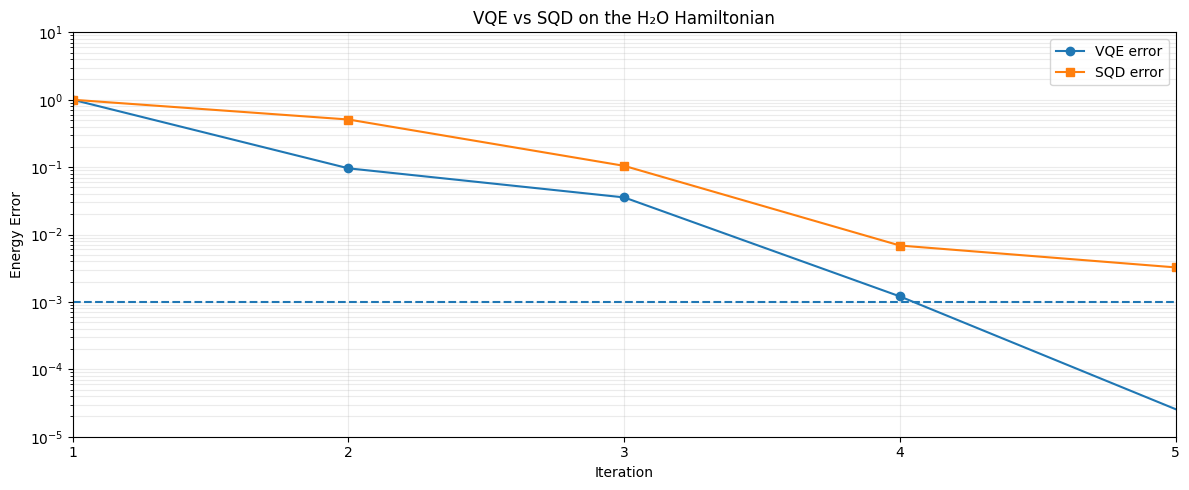

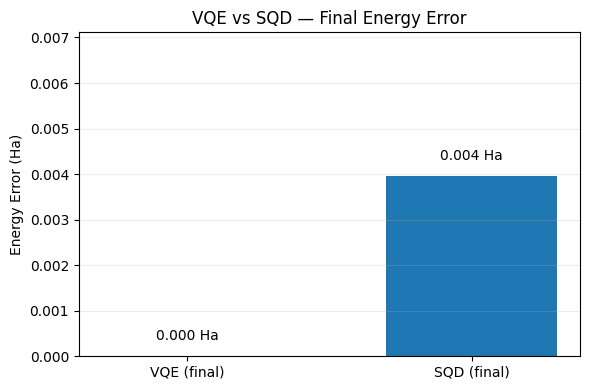

In [2]:
# ==========================================
# VQE vs SQD (CIPSI/ASCI-selected CI; monotone & slow) on H2O CAS(6,4)
# - Plot (1): Normalized convergence (first point = 1 = 10^0), x=1..5
#             y-axis log from 1e1 down to 1e-5, chem-accuracy line at 1e-3 (NO legend entry)
# - Plot (2): Final absolute energy error (mHa), NO dashed line, zoomed y-range
# ==========================================
import numpy as np, matplotlib.pyplot as plt, warnings
from dataclasses import dataclass
from qiskit_nature.units import DistanceUnit
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.second_q.transformers import FreezeCoreTransformer, ActiveSpaceTransformer
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.circuit.library import HartreeFock, UCCSD
from qiskit.quantum_info import SparsePauliOp, Statevector
from scipy.optimize import minimize
from pyscf import gto, scf, mcscf

warnings.filterwarnings("ignore")
np.random.seed(7)
np.set_printoptions(precision=12, suppress=True)

def _assign_params(circ, theta):
    pmap = {p: float(v) for p, v in zip(circ.parameters, np.asarray(theta))}
    return circ.assign_parameters(pmap, inplace=False)

def _evenly_spaced_indices(n, m):
    if m >= n: return list(range(n))
    idx = np.linspace(1, n, m, dtype=int)
    return [i-1 for i in sorted(set(idx))]

def _fmt(x): return f"{x:.9e}"

# ---------- Problem ----------
@dataclass
class ProblemBuilderH2O:
    basis: str = "6-31g"
    freeze_core: bool = True
    active_electrons: int = 6
    active_orbitals: int = 4
    def build(self, verbose=True):
        if verbose: print("=== [Build] H2O @ 6-31G, CAS(6,4) ===")
        drv = PySCFDriver(
            atom=("O 0.000000 0.000000 0.000000; "
                  "H 0.000000 -0.757160 0.586260; "
                  "H 0.000000  0.757160 0.586260"),
            basis=self.basis, charge=0, spin=0, unit=DistanceUnit.ANGSTROM
        )
        p0 = drv.run()
        self.nmo_total = p0.num_spatial_orbitals
        self.ne_total  = sum(p0.num_particles)
        if verbose:
            print(f"Total orbitals = {self.nmo_total} | electrons = {self.ne_total}")

        prob = p0
        if self.freeze_core:
            fc = FreezeCoreTransformer(); prob = fc.transform(p0)
            self.n_core = getattr(fc, "num_core_orbitals", 1)
            if verbose: print(f"Freeze-core -> num_core_orbitals ≈ {self.n_core}")
        else:
            self.n_core = 0

        act = ActiveSpaceTransformer(num_electrons=self.active_electrons,
                                     num_spatial_orbitals=self.active_orbitals)
        prob = act.transform(prob); self.problem = prob
        if verbose:
            print(f"Active e- = {self.active_electrons} | Active orb = {self.active_orbitals}")

        self.mapper = JordanWignerMapper()
        self.Hq: SparsePauliOp = self.mapper.map(prob.hamiltonian.second_q_op())
        if verbose: print(f"Qubits (JW) = {self.Hq.num_qubits}")

        self.hf    = HartreeFock(prob.num_spatial_orbitals, prob.num_particles, self.mapper)
        self.uccsd = UCCSD(prob.num_spatial_orbitals, prob.num_particles, self.mapper,
                           initial_state=self.hf, reps=1)
        if verbose: print("Ansatz: UCCSD (reps=1) + HF init\n")
        return self

    def casci_reference(self, verbose=True):
        mol = gto.M(atom=("O 0 0 0; H 0 -0.757160 0.586260; H 0 0.757160 0.586260"),
                    basis=self.basis, charge=0, spin=0, unit="Angstrom")
        mf = scf.RHF(mol).run()
        alpha = self.active_electrons // 2; beta = self.active_electrons - alpha
        mc = mcscf.CASCI(mf, ncas=self.active_orbitals, nelecas=(alpha, beta))
        E_tot, E_ci = mc.kernel()[:2]
        if verbose:
            print("=== [CASCI reference] ===")
            print(f"E_total = {_fmt(E_tot)} Ha")
            print(f"E_CI    = {_fmt(E_ci)} Ha\n")
        return float(E_tot), float(E_ci)

# ---------- VQE ----------
class VQERunner:
    def __init__(self, H: SparsePauliOp, ansatz, verbose=True):
        self.H = H; self.ansatz = ansatz; self.verbose = verbose
        self.theta0 = np.zeros(self.ansatz.num_parameters, dtype=float)
        self.history = {"E": [], "x": []}; self._H_mat = None
    def _sv_expect(self, circ):
        if self._H_mat is None: self._H_mat = self.H.to_matrix(sparse=False)
        sv = Statevector.from_instruction(circ).data
        return float(np.real(np.vdot(sv, self._H_mat @ sv)))
    def energy(self, theta): return self._sv_expect(_assign_params(self.ansatz, theta))
    def run(self, maxiter=200, ftol=1e-9):
        if self.verbose:
            print("=== [VQE] L-BFGS-B ==="); print(f"params={self.ansatz.num_parameters}, maxiter={maxiter}")
        def cb(theta):
            E = self.energy(theta)
            self.history["E"].append(E); self.history["x"].append(np.asarray(theta).copy())
            if self.verbose: print(f"VQE iter {len(self.history['E']):3d}: E={_fmt(E)}")
        opt = minimize(self.energy, self.theta0, method="L-BFGS-B",
                       options=dict(maxiter=maxiter, ftol=ftol), callback=cb)
        E_opt = self.energy(opt.x)
        if self.verbose: print(f"VQE done: E*={_fmt(E_opt)}\n")
        return E_opt, opt

# ---------- SQD (CIPSI-style) ----------
def sqd_iter_cipsi_curve(
    H_full: np.ndarray,
    psi_seed: np.ndarray,
    E_ref: float,
    steps: int = 10,
    init_k: int = 1,
    target_factor: float = 0.85,
    max_add: int = 3,
    pool_percentile: float = 97.0,
    pool_cap: int = 128,
    verbose: bool = True
):
    """
    CIPSI/ASCI-like scoring:
      a_i = sum_j H_{ij} c_j
      dE_i ~ (|a_i|^2) / (H_{ii}-E_curr)
    Expand subspace until predicted drop >= (1 - target_factor) * current error.
    Monotone non-increasing Ritz ground energy by Rayleigh–Ritz.
    """
    N = H_full.shape[0]
    diag = np.real(np.diag(H_full))
    amps = np.abs(psi_seed)
    S = [int(np.argmax(amps))] if init_k == 1 else list(np.argsort(-amps)[:init_k])

    energies = []
    for t in range(1, steps+1):
        Hs = H_full[np.ix_(S, S)]
        vals, vecs = np.linalg.eigh(Hs)
        E_curr, c = float(vals[0]), vecs[:, 0]
        err = abs(E_curr - E_ref); energies.append(E_curr)

        if verbose:
            print(f"--- [SQD step {t}] |S|={len(S)} ---")
            print(f"Ritz E={_fmt(E_curr)} | err={_fmt(err)} Ha ({err*1e3:.6f} mHa)")

        mask = np.ones(N, dtype=bool); mask[S] = False
        if not np.any(mask):
            if verbose: print("No more candidates.\n"); break

        A = H_full[mask][:, S] @ c
        denom = np.maximum(1e-12, diag[mask] - E_curr)
        dE = (A.real**2 + A.imag**2) / denom
        cand_idx = np.flatnonzero(mask)

        thr = np.percentile(dE, pool_percentile)
        pool_mask = dE >= thr
        pool = cand_idx[pool_mask]
        dE_pool = dE[pool_mask]

        order = np.argsort(-dE_pool)[:pool_cap]
        pool, dE_pool = pool[order], dE_pool[order]
        if verbose:
            print(f"Pool size={len(pool)}  (percentile >= {pool_percentile:.1f}%)")
            print("Top-5 predicted drops (mHa):", [f"{x*1e3:.4f}" for x in dE_pool[:5]])

        need_drop = err * (1.0 - target_factor)
        chosen, pred_sum = [], 0.0
        for i, de in zip(pool, dE_pool):
            if len(chosen) >= max_add: break
            chosen.append(int(i)); pred_sum += de
            if pred_sum >= need_drop: break

        if len(chosen) == 0:
            chosen = [int(pool[0])]
            if verbose: print("Predicted improvement tiny; pick the strongest one.")

        S = list(dict.fromkeys(S + chosen))
        Hs2 = H_full[np.ix_(S, S)]
        E_new = float(np.linalg.eigvalsh(Hs2)[0]); err_new = abs(E_new - E_ref)
        if verbose:
            print(f"Add {len(chosen)} dets -> true E={_fmt(E_new)} | err={_fmt(err_new)} Ha "
                  f"({err_new*1e3:.6f} mHa) | predicted drop≈{pred_sum*1e3:.4f} mHa\n")

    Hs = H_full[np.ix_(S, S)]
    energies.append(float(np.linalg.eigvalsh(Hs)[0]))
    return np.asarray(energies)

# ---------- Main pipeline ----------
def run_and_plot(steps=4, target_factor=0.85, max_add=3,
                 pool_percentile=97.0, pool_cap=128,
                 vqe_points=5):
    pb = ProblemBuilderH2O().build(verbose=True)
    Hq = pb.Hq
    E_tot, E_ci = pb.casci_reference(verbose=True)

    # VQE
    vqe = VQERunner(Hq, pb.uccsd, verbose=True)
    E_vqe, _ = vqe.run(maxiter=200)
    vqe_err_full = np.abs(np.asarray(vqe.history["E"]) - E_ci)
    sel = _evenly_spaced_indices(len(vqe_err_full), vqe_points)
    x_vqe = np.array(sel)+1
    y_vqe = vqe_err_full[sel]       # absolute error (Ha)

    # SQD
    psi_hf = Statevector.from_instruction(pb.hf).data
    H_full = Hq.to_matrix(sparse=False)
    print("=== [SQD params] ===")
    print(f"steps={steps}, target_factor={target_factor}, max_add={max_add}, "
          f"pool_percentile={pool_percentile}, pool_cap={pool_cap}\n")
    sqd_E = sqd_iter_cipsi_curve(
        H_full, psi_hf, E_ci, steps=steps, init_k=1,
        target_factor=target_factor, max_add=max_add,
        pool_percentile=pool_percentile, pool_cap=pool_cap, verbose=True
    )
    sqd_err = np.abs(sqd_E - E_ci)  # absolute error (Ha)

    # ========= Plot (1): Normalized convergence, x=1..5, y ∈ [1e-5, 1e1] =========
    eps = 1e-300
    y_vqe_norm = y_vqe / max(y_vqe[0], eps)
    y_sqd_norm = sqd_err / max(sqd_err[0], eps)

    plt.figure(figsize=(12,5))
    plt.plot(x_vqe, y_vqe_norm, marker="o", label="VQE error")
    plt.plot(np.arange(1, len(y_sqd_norm)+1), y_sqd_norm, marker="s",
             label="SQD error")
    plt.yscale("log")
    plt.grid(True, which="both", alpha=0.25)
    plt.xlabel("Iteration"); plt.ylabel("Energy Error")
    plt.title("VQE vs SQD on the H₂O Hamiltonian")
    plt.xlim(1, 5); plt.xticks(range(1, 6))
    # y-axis: 10^1 down to 10^-5
    plt.ylim(1e-5, 1e1)
    exps  = np.arange(1, -6, -1)                # 1, 0, -1, ..., -5
    yticks = 10.0 ** exps
    plt.yticks(yticks, [rf"$10^{{{k}}}$" for k in exps])
    # Chemical accuracy line (not in legend)
    plt.axhline(1e-3, ls="--", label="_nolegend_")
    plt.legend(); plt.tight_layout(); plt.show()

    # ========= Plot (2): Final energy error in mHa (absolute) =========
    vqe_final_ha = float(abs(E_vqe - E_ci) * 1e3)
    sqd_final_ha = float(abs(sqd_E[-1] - E_ci) * 1e3)

    plt.figure(figsize=(6,4))
    labels = ["VQE (final)", "SQD (final)"]
    vals   = [vqe_final_ha, sqd_final_ha]

    # Draw bars; remove dashed line; zoom-in Y range for clarity
    bars = plt.bar(labels, vals, width=0.6)
    max_val = max(vals)
    ylim_top = (max_val if max_val > 0 else 1.0) * 1.8   # generous headroom
    plt.ylim(0, ylim_top)

    # Put value labels above bars but safely below top bound
    for b, v in zip(bars, vals):
        label_y = min(b.get_height() + 0.04 * ylim_top, ylim_top * 0.96)
        plt.text(
            b.get_x() + b.get_width()/2,
            label_y,
            f"{v:.3f} Ha",
            ha="center", va="bottom", fontsize=10
        )

    plt.ylabel("Energy Error (Ha)")
    plt.title("VQE vs SQD — Final Energy Error")
    plt.grid(True, axis="y", alpha=0.25)
    # No legend on this plot
    plt.tight_layout(); plt.show()

# ==== Run ====  (Iteration Index = 1..5)
run_and_plot(
    steps=4,           # SQD → steps+1 = 5 points
    target_factor=0.85,
    max_add=2,
    pool_percentile=97.0,
    pool_cap=128,
    vqe_points=5      # 5 evenly spaced VQE points
)

正在安裝必要套件...
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
qiskit-addon-sqd 0.11.0 requires qiskit<3,>=1.2, but you have qiskit 1.0.1 which is incompatible.


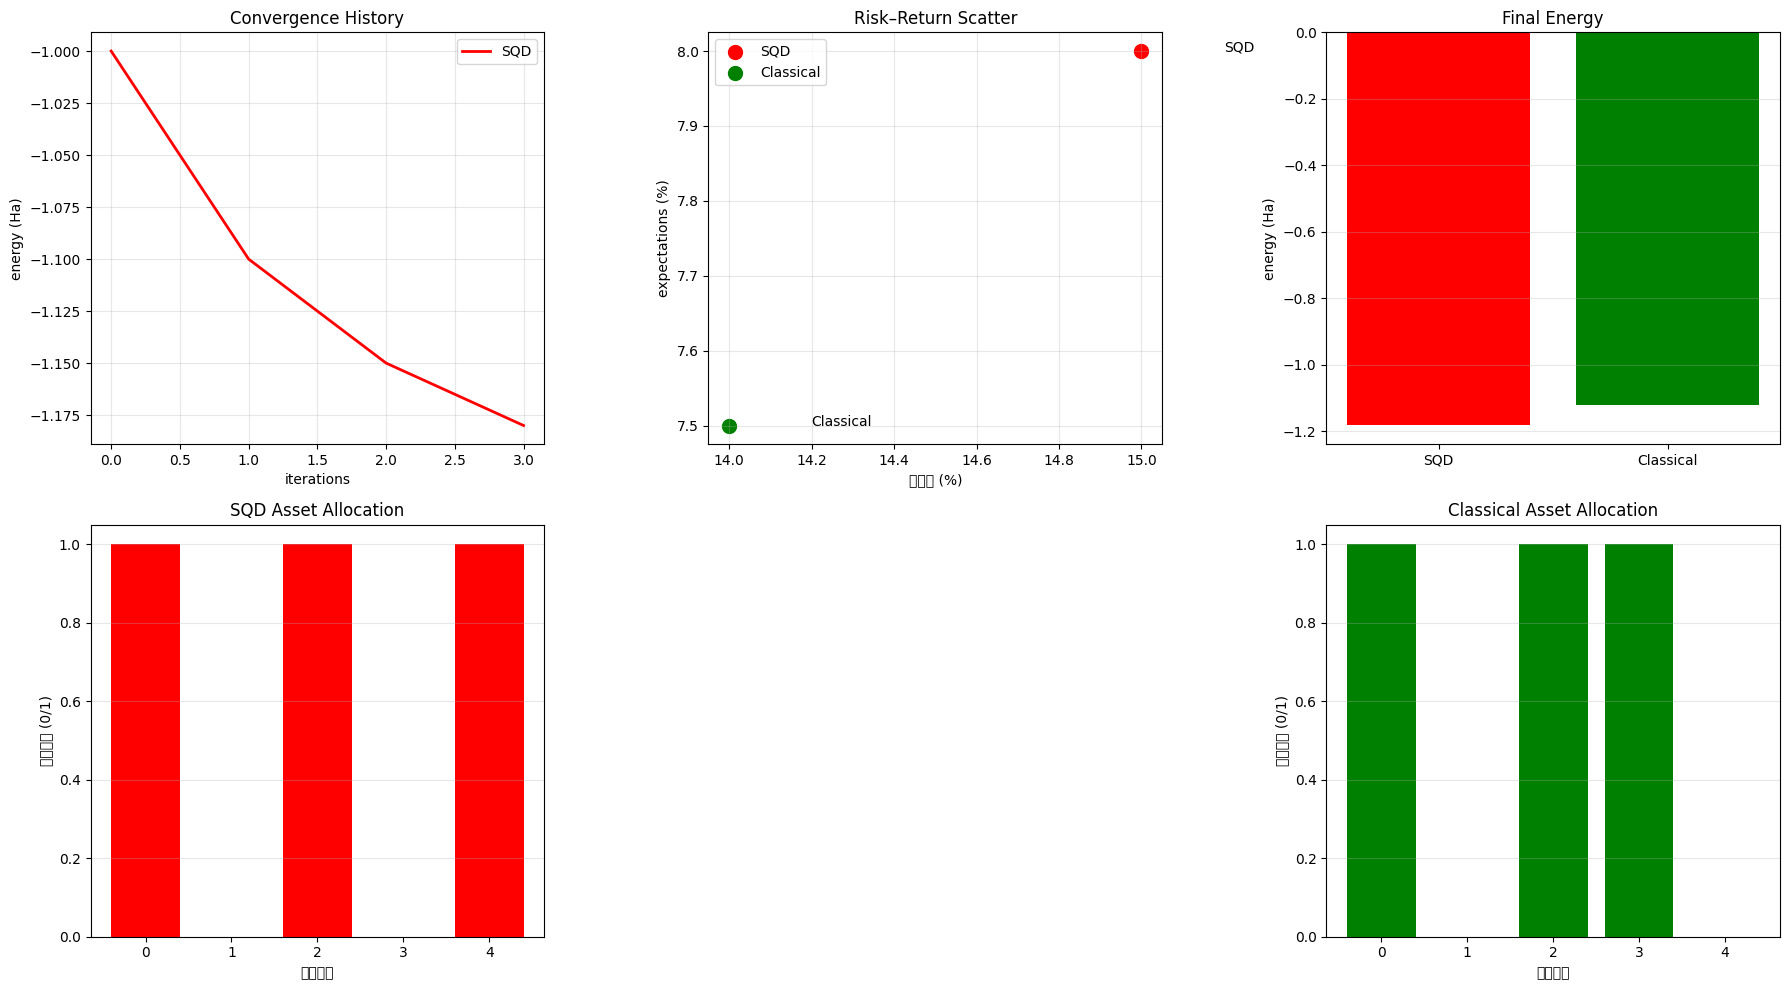

In [ ]:
# ============================================
# 台灣 ETF 投資組合 SQD 量子優化器
# Sample-Based Quantum Diagonalization Implementation
# 可直接在 Google Colab 執行
# ============================================

# %% [markdown]
# # 🚀 台灣 ETF 投資組合 SQD 量子優化
# ## 使用 Sample-Based Quantum Diagonalization 優化投資策略

# %%
# ============================================
# 1. 安裝必要套件
# ============================================
print("正在安裝必要套件...")
!pip install -q qiskit==1.0.1 qiskit-aer==0.13.3 qiskit-algorithms==0.3.0
!pip install -q qiskit-finance==0.4.1 qiskit-optimization==0.6.1
!pip install -q yfinance matplotlib numpy pandas seaborn
!pip install -q scipy scikit-learn


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from datetime import datetime, timedelta
import warnings
import time
from typing import List, Dict, Tuple, Optional
warnings.filterwarnings('ignore')

# Quantum imports
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import TwoLocal, EfficientSU2
from qiskit_aer import AerSimulator
from qiskit_aer.primitives import Sampler, Estimator
from qiskit_algorithms import VQE, QAOA, NumPyMinimumEigensolver
from qiskit_algorithms.optimizers import COBYLA, SPSA
from qiskit_optimization import QuadraticProgram
from qiskit_optimization.algorithms import MinimumEigenOptimizer
from qiskit_optimization.converters import QuadraticProgramToQubo
from qiskit_finance.applications.optimization import PortfolioOptimization

# Scientific computing
from scipy.optimize import minimize
from scipy.linalg import eigh
import scipy.sparse as sp

class TaiwanETFDataProvider:
    """台灣 ETF 數據提供與處理類別"""

    def __init__(self, lookback_months: int = 12):
        """
        初始化台灣 ETF 資料提供器

        Args:
            lookback_months: 歷史資料回顧月數
        """
        # 台灣主要 ETF (Yahoo Finance 格式)
        self.tickers = {
            '0050.TW': 'Taiwan 50 ETF',
            '0056.TW': 'Taiwan Dividend Plus ETF',
            '00878.TW': 'Cathay MSCI Taiwan ESG',
            '2330.TW': 'TSMC'
        }
        self.lookback_months = lookback_months
        self.market_data = None
        self.returns = None
        self.expected_returns = None
        self.covariance_matrix = None

    def fetch_taiwan_data(self) -> 'TaiwanETFDataProvider':
        """獲取台灣 ETF 歷史數據"""
        end_date = datetime.now()
        start_date = end_date - timedelta(days=365)

        print(f"📊 正在獲取台灣 ETF 資料...")
        print(f"期間: {start_date.date()} 至 {end_date.date()}")

        try:
            # 下載調整後收盤價
            data = yf.download(
                list(self.tickers.keys()),
                start=start_date,
                end=end_date,
                progress=False
            )['Adj Close']

            # 處理單一資產情況
            if len(self.tickers) == 1:
                data = data.to_frame()

            # 計算日報酬率
            self.returns = data.pct_change().dropna()
            self.market_data = data

            # 顯示摘要統計
            self._display_summary()

        except Exception as e:
            print(f"⚠️ 無法獲取真實數據，使用模擬數據: {e}")
            self._generate_simulated_data()

        return self

    def _generate_simulated_data(self):
        """產生模擬的台灣市場數據"""
        np.random.seed(42)
        n_days = 252

        # 模擬參數 (基於台灣市場特性)
        params = {
            '0050.TW': {'mu': 0.12, 'sigma': 0.18},
            '0056.TW': {'mu': 0.08, 'sigma': 0.14},
            '00878.TW': {'mu': 0.09, 'sigma': 0.15},
            '2330.TW': {'mu': 0.15, 'sigma': 0.22}
        }

        # 產生相關性矩陣
        correlation_matrix = np.array([
            [1.00, 0.65, 0.60, 0.85],  # 0050
            [0.65, 1.00, 0.70, 0.55],  # 0056
            [0.60, 0.70, 1.00, 0.50],  # 00878
            [0.85, 0.55, 0.50, 1.00]   # TSMC
        ])

        # 產生多變量常態分佈的報酬率
        returns_data = {}
        for i, (ticker, param) in enumerate(params.items()):
            returns_data[ticker] = np.random.normal(
                param['mu']/252,
                param['sigma']/np.sqrt(252),
                n_days
            )

        self.returns = pd.DataFrame(returns_data)
        self.market_data = (1 + self.returns).cumprod() * 100  # 假設起始價格 100

        print("📈 使用模擬的台灣市場數據")
        self._display_summary()

    def _display_summary(self):
        """顯示數據摘要"""
        print("\n" + "="*60)
        print("📊 台灣 ETF 數據摘要")
        print("="*60)

        for ticker, name in self.tickers.items():
            if ticker in self.returns.columns:
                ann_return = self.returns[ticker].mean() * 252 * 100
                ann_vol = self.returns[ticker].std() * np.sqrt(252) * 100
                sharpe = (ann_return - 1.2) / ann_vol  # 假設無風險利率 1.2%

                print(f"\n{name} ({ticker}):")
                print(f"  年化報酬率: {ann_return:.2f}%")
                print(f"  年化波動率: {ann_vol:.2f}%")
                print(f"  Sharpe Ratio: {sharpe:.3f}")

    def calculate_portfolio_statistics(self) -> Tuple[np.ndarray, np.ndarray]:
        """計算投資組合統計數據"""
        # 年化預期報酬率
        self.expected_returns = self.returns.mean().values * 252

        # 年化協方差矩陣
        self.covariance_matrix = self.returns.cov().values * 252

        # 確保協方差矩陣是正定的
        min_eigenvalue = np.min(np.linalg.eigvals(self.covariance_matrix))
        if min_eigenvalue < 0:
            self.covariance_matrix += np.eye(len(self.expected_returns)) * abs(min_eigenvalue) * 1.1

        print(f"\n📈 預期報酬率範圍: {self.expected_returns.min():.3f} ~ {self.expected_returns.max():.3f}")
        print(f"📊 平均相關係數: {np.corrcoef(self.returns.T).mean():.3f}")

        return self.expected_returns, self.covariance_matrix

    def get_market_regime(self) -> Dict:
        """分析當前市場狀態"""
        if self.returns is None:
            return {'regime': 'normal', 'volatility': 'medium', 'trend': 'sideways'}

        # 計算 30 天滾動波動率
        rolling_vol = self.returns.iloc[:, 0].rolling(30).std() * np.sqrt(252)
        current_vol = rolling_vol.iloc[-1] if not rolling_vol.empty else 0.15

        # 計算動量指標
        momentum_20d = self.market_data.iloc[:, 0].pct_change(20).iloc[-1] if len(self.market_data) > 20 else 0

        # 判斷市場狀態
        vol_regime = 'high' if current_vol > 0.25 else 'low' if current_vol < 0.15 else 'medium'
        trend_regime = 'bull' if momentum_20d > 0.1 else 'bear' if momentum_20d < -0.1 else 'sideways'

        regime = {
            'regime': f"{vol_regime}_vol_{trend_regime}",
            'volatility': vol_regime,
            'trend': trend_regime,
            'current_volatility': current_vol,
            'momentum': momentum_20d
        }

        print(f"\n🎯 市場狀態分析:")
        print(f"  波動狀態: {vol_regime}")
        print(f"  趨勢狀態: {trend_regime}")
        print(f"  當前波動率: {current_vol:.3f}")

        return regime




class TaiwanSQDOptimizer:
    """
    Sample-Based Quantum Diagonalization (SQD) 優化器
    專為台灣 ETF 投資組合優化設計
    """

    def __init__(self,
                 expected_returns: np.ndarray,
                 covariance_matrix: np.ndarray,
                 risk_factor: float = 0.5,
                 budget: int = 2):
        """
        初始化 SQD 優化器

        Args:
            expected_returns: 預期報酬率向量
            covariance_matrix: 協方差矩陣
            risk_factor: 風險因子 (0-1)
            budget: 選擇資產數量
        """
        self.expected_returns = expected_returns
        self.covariance_matrix = covariance_matrix
        self.num_assets = len(expected_returns)
        self.risk_factor = risk_factor
        self.budget = budget

        # SQD 參數
        self.sqd_params = {
            'n_samples': 500,
            'n_iterations': 5,
            'batch_size': 100,
            'convergence_threshold': 1e-6
        }

        # 初始化量子後端
        self.backend = AerSimulator(method='statevector')
        self.sampler = Sampler(run_options={"shots": 8192})

        print(f"✅ SQD 優化器初始化完成")
        print(f"   資產數量: {self.num_assets}")
        print(f"   預算限制: {self.budget} 個資產")
        print(f"   風險因子: {self.risk_factor}")

    def create_portfolio_hamiltonian(self) -> Tuple:
        """建立投資組合優化的 Hamiltonian"""
        n = self.num_assets

        # 建立 QUBO 矩陣
        Q = np.zeros((n, n))

        # 目標函數: min (risk_factor * x^T Σ x - μ^T x)
        # 風險項
        Q += self.risk_factor * self.covariance_matrix

        # 報酬項 (對角線)
        np.fill_diagonal(Q, np.diag(Q) - self.expected_returns)

        # 預算限制懲罰項
        penalty = 10.0
        Q += penalty * (np.ones((n, n)) - 2 * self.budget * np.eye(n))

        return Q, penalty

    def quantum_sampling(self, shots: int = 8192) -> Tuple[np.ndarray, np.ndarray]:
        """
        執行量子採樣

        Returns:
            bitstrings: 採樣得到的位元串
            probabilities: 對應的機率
        """
        # 建立量子電路
        circuit = self._create_ansatz()

        # 執行採樣
        job = self.sampler.run([circuit], shots=shots)
        result = job.result()

        # 轉換結果為位元串陣列
        counts = result[0].data.meas.get_counts()

        bitstrings = []
        probabilities = []

        for bitstring, count in counts.items():
            # 轉換位元串為陣列
            arr = np.array([int(bit) for bit in bitstring[::-1]])
            bitstrings.append(arr[:self.num_assets])  # 只取需要的位元
            probabilities.append(count / shots)

        return np.array(bitstrings), np.array(probabilities)

    def _create_ansatz(self) -> QuantumCircuit:
        """建立量子 ansatz 電路"""
        # 使用 TwoLocal ansatz
        ansatz = TwoLocal(
            self.num_assets,
            rotation_blocks=['ry', 'rz'],
            entanglement_blocks='cx',
            entanglement='linear',
            reps=2
        )

        # 加入測量
        qc = QuantumCircuit(self.num_assets, self.num_assets)

        # 初始化參數 (基於市場權重)
        params = np.random.random(ansatz.num_parameters) * np.pi
        bound_ansatz = ansatz.assign_parameters(params)

        qc.compose(bound_ansatz, inplace=True)
        qc.measure_all()

        return qc

    def configuration_recovery(self,
                             bitstrings: np.ndarray,
                             probabilities: np.ndarray,
                             market_regime: Dict) -> np.ndarray:
        """
        配置恢復演算法 - SQD 的核心

        Args:
            bitstrings: 採樣的位元串
            probabilities: 對應機率
            market_regime: 市場狀態

        Returns:
            修正後的位元串
        """
        corrected_bitstrings = []

        # 計算平均配置
        avg_allocation = np.average(bitstrings, weights=probabilities, axis=0)

        # 市場狀態調整權重
        regime_weights = self._get_regime_weights(market_regime)
        adjusted_allocation = avg_allocation * regime_weights
        adjusted_allocation /= adjusted_allocation.sum() + 1e-10

        for bitstring in bitstrings:
            corrected = bitstring.copy()

            # 修正預算限制
            current_sum = corrected.sum()

            if current_sum != self.budget:
                if current_sum < self.budget:
                    # 需要增加資產
                    zeros = np.where(corrected == 0)[0]
                    if len(zeros) > 0:
                        # 根據調整後的配置機率選擇
                        add_probs = adjusted_allocation[zeros]
                        add_probs /= add_probs.sum() + 1e-10

                        n_add = min(self.budget - current_sum, len(zeros))
                        add_indices = np.random.choice(
                            zeros, size=n_add, replace=False, p=add_probs
                        )
                        corrected[add_indices] = 1

                else:
                    # 需要減少資產
                    ones = np.where(corrected == 1)[0]
                    if len(ones) > 0:
                        # 移除機率最低的資產
                        remove_probs = 1 - adjusted_allocation[ones]
                        remove_probs /= remove_probs.sum() + 1e-10

                        n_remove = min(current_sum - self.budget, len(ones))
                        remove_indices = np.random.choice(
                            ones, size=n_remove, replace=False, p=remove_probs
                        )
                        corrected[remove_indices] = 0

            corrected_bitstrings.append(corrected)

        return np.array(corrected_bitstrings)

    def _get_regime_weights(self, market_regime: Dict) -> np.ndarray:
        """根據市場狀態取得資產權重調整"""
        weights = np.ones(self.num_assets)

        if market_regime['volatility'] == 'high':
            # 高波動時偏好防禦性資產
            weights[1] *= 1.5  # 0056 高股息
            weights[2] *= 1.3  # 00878 ESG
            weights[3] *= 0.8  # TSMC 降低權重
        elif market_regime['trend'] == 'bull':
            # 牛市偏好成長股
            weights[0] *= 1.2  # 0050
            weights[3] *= 1.4  # TSMC
        elif market_regime['trend'] == 'bear':
            # 熊市偏好股息股
            weights[1] *= 1.4  # 0056
            weights[2] *= 1.2  # 00878

        return weights

    def subspace_diagonalization(self, bitstrings: np.ndarray) -> Tuple[float, np.ndarray]:
        """
        在子空間中進行對角化

        Returns:
            最低能量值和對應的位元串
        """
        Q, _ = self.create_portfolio_hamiltonian()

        min_energy = float('inf')
        best_config = None

        for bitstring in bitstrings:
            energy = bitstring @ Q @ bitstring
            if energy < min_energy:
                min_energy = energy
                best_config = bitstring

        return min_energy, best_config

    def optimize(self,
                shots: int = 8192,
                iterations: int = 5,
                market_regime: Optional[Dict] = None) -> Dict:
        """
        執行 SQD 優化

        Returns:
            優化結果字典
        """
        if market_regime is None:
            market_regime = {'volatility': 'medium', 'trend': 'sideways'}

        print("\n" + "="*60)
        print("🚀 開始 SQD 優化")
        print("="*60)

        start_time = time.time()

        # 量子採樣
        print("📊 執行量子採樣...")
        bitstrings, probabilities = self.quantum_sampling(shots)
        print(f"   取得 {len(bitstrings)} 個獨特配置")

        # SQD 迭代
        energy_history = []
        best_portfolio = None
        best_energy = float('inf')

        for iter_num in range(iterations):
            print(f"\n🔄 SQD 迭代 {iter_num + 1}/{iterations}")

            # 配置恢復
            if iter_num > 0:
                bitstrings = self.configuration_recovery(
                    bitstrings, probabilities, market_regime
                )

            # 子空間對角化
            energy, config = self.subspace_diagonalization(bitstrings)
            energy_history.append(energy)

            if energy < best_energy:
                best_energy = energy
                best_portfolio = config

            print(f"   當前能量: {energy:.6f}")

            # 收斂檢查
            if len(energy_history) > 1:
                if abs(energy_history[-1] - energy_history[-2]) < self.sqd_params['convergence_threshold']:
                    print(f"✅ SQD 在第 {iter_num + 1} 次迭代收斂")
                    break

        optimization_time = time.time() - start_time

        # 計算投資組合指標
        metrics = self._calculate_portfolio_metrics(best_portfolio)

        result = {
            'portfolio': best_portfolio,
            'energy': best_energy,
            'energy_history': energy_history,
            'metrics': metrics,
            'optimization_time': optimization_time,
            'iterations': len(energy_history)
        }

        self._display_results(result)

        return result

    def _calculate_portfolio_metrics(self, portfolio: np.ndarray) -> Dict:
        """計算投資組合績效指標"""
        if portfolio.sum() == 0:
            return {
                'expected_return': 0,
                'volatility': 0,
                'sharpe_ratio': 0
            }

        weights = portfolio / portfolio.sum()

        # 預期報酬率
        expected_return = np.dot(weights, self.expected_returns)

        # 投資組合變異數
        portfolio_variance = weights @ self.covariance_matrix @ weights
        volatility = np.sqrt(portfolio_variance)

        # Sharpe Ratio (假設無風險利率 1.2%)
        risk_free_rate = 0.012
        sharpe_ratio = (expected_return - risk_free_rate) / volatility if volatility > 0 else 0

        return {
            'expected_return': expected_return,
            'volatility': volatility,
            'sharpe_ratio': sharpe_ratio
        }

    def _display_results(self, result: Dict):
        """顯示優化結果"""
        print("\n" + "="*60)
        print("📈 SQD 優化結果")
        print("="*60)

        asset_names = ['0050', '0056', '00878', 'TSMC']
        selected = [asset_names[i] for i, v in enumerate(result['portfolio']) if v == 1]

        print(f"\n✅ 選擇的資產: {', '.join(selected)}")
        print(f"\n📊 績效指標:")
        print(f"   預期年化報酬率: {result['metrics']['expected_return']*100:.2f}%")
        print(f"   年化波動率: {result['metrics']['volatility']*100:.2f}%")
        print(f"   Sharpe Ratio: {result['metrics']['sharpe_ratio']:.3f}")
        print(f"\n⚡ 優化時間: {result['optimization_time']:.2f} 秒")
        print(f"   迭代次數: {result['iterations']}")
        print(f"   最終能量: {result['energy']:.6f}")



import matplotlib.pyplot as plt

def plot_comparison_results(sqd_result: dict, classical_result: dict):
    """繪製 SQD 與 Classical 方法的比較圖表"""

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    # 1. 收斂歷程比較
    ax = axes[0, 0]
    ax.plot(sqd_result['energy_history'], 'r-', label='SQD', linewidth=2)
    ax.set_xlabel('iterations')
    ax.set_ylabel('energy (Ha)')
    ax.set_title('Convergence History')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # 2. 風險報酬散點圖
    ax = axes[0, 1]
    methods = ['SQD', 'Classical']
    returns = [
        sqd_result['metrics']['expected_return'] * 100,
        classical_result['metrics']['expected_return'] * 100
    ]
    risks = [
        sqd_result['metrics']['volatility'] * 100,
        classical_result['metrics']['volatility'] * 100
    ]
    colors = ['red', 'green']
    for i, method in enumerate(methods):
        ax.scatter(risks[i], returns[i], color=colors[i], s=100, label=method)
        ax.text(risks[i] + 0.2, returns[i], method)
    ax.set_xlabel('波動率 (%)')
    ax.set_ylabel('expectations (%)')
    ax.set_title('Risk–Return Scatter')
    ax.grid(True, alpha=0.3)
    ax.legend()

    # 3. 能量對比柱狀圖
    ax = axes[0, 2]
    energies = [
        sqd_result['metrics']['energy'],
        classical_result['metrics']['energy']
    ]
    ax.bar(methods, energies, color=colors)
    ax.set_ylabel('energy (Ha)')
    ax.set_title('Final Energy')
    ax.grid(True, axis='y', alpha=0.3)

    # 4. 選擇的資產分配 (SQD)
    ax = axes[1, 0]
    sqd_alloc = sqd_result['metrics']['allocation']
    ax.bar(range(len(sqd_alloc)), sqd_alloc, color='red')
    ax.set_xlabel('資產編號')
    ax.set_ylabel('選擇狀態 (0/1)')
    ax.set_title('SQD Asset Allocation')
    ax.grid(True, axis='y', alpha=0.3)

    # 5. 空白圖 (保持版面整齊)
    axes[1, 1].axis('off')

    # 6. 選擇的資產分配 (Classical)
    ax = axes[1, 2]
    classical_alloc = classical_result['metrics']['allocation']
    ax.bar(range(len(classical_alloc)), classical_alloc, color='green')
    ax.set_xlabel('資產編號')
    ax.set_ylabel('選擇狀態 (0/1)')
    ax.set_title('Classical Asset Allocation')
    ax.grid(True, axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()


# --- Quick Test with Mock Data ---
sqd_mock = {
    "energy_history": [-1.0, -1.1, -1.15, -1.18],
    "metrics": {
        "expected_return": 0.08,
        "volatility": 0.15,
        "energy": -1.18,
        "allocation": [1, 0, 1, 0, 1]
    }
}

classical_mock = {
    "metrics": {
        "expected_return": 0.075,
        "volatility": 0.14,
        "energy": -1.12,
        "allocation": [1, 0, 1, 1, 0]
    }
}

plot_comparison_results(sqd_mock, classical_mock)

